In [ ]:
import pandas as pd
import gc
import warnings
warnings.filterwarnings('ignore')
# file_loc = '/mnt/disks/filedisk2a/Qingcheng/'
# train_df   = pd.read_csv(file_loc + 'train_df.csv')
# holdout_df = pd.read_csv(file_loc + 'holdout_df.csv')
# drop all long_profit / short_profit variables
import sys; sys.path.append('/var/www/python/Prod/nighthawk/')
from nighthawk.util.bigquery_functions import download_df_from_bq
file_loc = '/mnt/disks/filedisk2a/Qingcheng/'

SPP_family_dt_features = download_df_from_bq(
    "SELECT * FROM `movetocloud-999.qctest.SPP_family_dt_features`"
)
print(SPP_family_dt_features.shape)
SPP_family_dt_features.head()

SPP_family_dt_features = SPP_family_dt_features.query('dt >= "2021-06-01" and dt< "2026-06-01"')

# break in to holdout period and non-holdout period 
# holdout
holdout_mon_lst = [
    '2021-06', '2021-09', '2021-12', 
    '2022-08',  '2022-11' ,'2022-02', 
    '2023-10', '2023-01', '2023-04',
    '2024-03', '2024-07', '2024-12', 
    '2025-05', '2025-09', '2025-01',
    '2026-03', '2026-05']

mon = pd.to_datetime(SPP_family_dt_features['dt']).dt.strftime('%Y-%m')
is_holdout = mon.isin(set(holdout_mon_lst))

holdout_df = SPP_family_dt_features[is_holdout].copy()     # dt in the listed months
train_df   = SPP_family_dt_features[~is_holdout].copy()    # dt not in those months

print("holdout:", holdout_df['dt'].nunique(), "days |", len(holdout_df), "rows")
print("train  :", train_df['dt'].nunique(),  "days |", len(train_df), "rows")
# sanity: every listed month actually present?
missing = set(holdout_mon_lst) - set(mon.unique())
print("listed months with no rows:", sorted(missing))

# go_nogo_df
go_nogo_df = pd.read_csv('/mnt/disks/filedisk2a/Jessica/tmp/' + 'go_nogo_days.csv')
go_nogo_df['dt'] = go_nogo_df['dt'].astype(str)
go_nogo_df['hr'] = go_nogo_df['hr'].astype(int)
print(go_nogo_df['nogo'].unique())

tier1_dt = set(go_nogo_df.loc[go_nogo_df['nogo'] == 1, 'dt'].values)
tier2_dt = set(go_nogo_df.loc[go_nogo_df['nogo'] == 2, 'dt'].values)

print(tier1_dt)
nogo_dt = tier1_dt | tier2_dt                      # all no-go days (nogo == 1 or 2)
clean = SPP_family_dt_features[~SPP_family_dt_features['dt'].isin(nogo_dt)].copy()   # keep go-days only

mon = pd.to_datetime(clean['dt']).dt.strftime('%Y-%m')
is_holdout = mon.isin(set(holdout_mon_lst))

holdout_df = clean[is_holdout].copy()    # listed months, no-go removed
train_df   = clean[~is_holdout].copy()   # other months, no-go removed

print("dropped no-go days:", SPP_family_dt_features['dt'].isin(nogo_dt).sum(), "rows")
print("holdout:", holdout_df['dt'].nunique(), "days |", len(holdout_df), "rows")
print("train  :", train_df['dt'].nunique(),  "days |", len(train_df), "rows")


(2037917, 106)
holdout: 519 days | 566418 rows
train  : 1307 days | 1461771 rows
listed months with no rows: []
[0 2 1]
{'2026-01-24', '2025-01-20', '2021-02-12', '2023-08-24', '2024-01-14', '2022-08-02', '2023-08-19', '2021-02-18', '2023-08-22', '2024-01-13', '2022-12-24', '2024-01-16', '2021-02-14', '2022-07-19', '2025-02-19', '2026-01-25', '2023-08-21', '2023-08-23', '2025-02-20', '2022-02-23', '2025-02-18', '2024-07-31', '2023-07-27', '2026-01-27', '2021-02-13', '2024-07-30', '2021-02-15', '2024-07-15', '2022-07-15', '2024-01-15', '2023-07-26', '2021-02-16', '2024-01-20', '2022-12-22', '2021-02-17', '2022-12-23', '2026-01-28', '2026-01-26'}
dropped no-go days: 72236 rows
holdout: 495 days | 550022 rows
train  : 1228 days | 1405931 rows


In [52]:
import sys; sys.path.append('/var/www/python/Prod/nighthawk/')
import pandas as pd
from nighthawk.data.network.constraint_family import ConstraintFamily

def replace_monitored_name(df, fam_col='constraint_family_num'):
    fams = pd.Series(df[fam_col].dropna().unique()).astype('int64')
    cf = ConstraintFamily('SPP', constraint_family_num_df=pd.DataFrame({'constraintFamilyNum': fams}))
    name_map = (cf.get_constraint_family_details()[['constraintFamilyNum', 'constraintName']]
                  .drop_duplicates('constraintFamilyNum')
                  .rename(columns={'constraintFamilyNum': fam_col, 'constraintName': 'monitored_name'}))
    print('families mapped:', name_map[fam_col].nunique(), '/', df[fam_col].nunique())
    df = df.copy()
    df[fam_col] = df[fam_col].astype('int64')
    return df.drop(columns=['monitored_name'], errors='ignore').merge(name_map, on=fam_col, how='left')

train_df = replace_monitored_name(train_df)
holdout_df = replace_monitored_name(holdout_df)
SPP_family_dt_features[['constraint_family_num', 'monitored_name']].drop_duplicates().head()

families mapped: 1477 / 1722
families mapped: 1244 / 1489


,constraint_family_num,monitored_name
0,590346.0,xfmrforman-forman
15,704807.0,lnn345-blackbry
22,704807.0,<NA>
62,1062.0,xfmrstilwell-stilwell
89,535.0,lnnash_mps-lbrtywt5


In [53]:
import numpy as np, pandas as pd

QS  = [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]
neg = np.isfinite(train_df['short_profit']) & (train_df['short_profit'] < 0)

probs = [0.0, *QS, 1.0]
edges = np.unique(train_df.loc[neg, 'short_profit'].quantile(probs).values)   # dedup tied edges
labels = [f'p{lo*100:g}-p{hi*100:g}' for lo, hi in zip(probs[:-1], probs[1:])][:len(edges)-1]

train_df['short_profit_q'] = pd.cut(
    train_df['short_profit'].where(neg), bins=edges, labels=labels, include_lowest=True)

print(train_df['short_profit_q'].value_counts(dropna=False).sort_index())


QS  = [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]
neg = np.isfinite(train_df['rt_da']) & (train_df['rt_da'] < 0)

probs  = [0.0, *QS, 1.0]
edges  = np.unique(train_df.loc[neg, 'rt_da'].quantile(probs).values)   # dedup tied edges
labels = [f'p{lo*100:g}-p{hi*100:g}' for lo, hi in zip(probs[:-1], probs[1:])][:len(edges)-1]

train_df['rt_da_q'] = pd.cut(
    train_df['rt_da'].where(neg), bins=edges, labels=labels, include_lowest=True)

print(train_df['rt_da_q'].value_counts(dropna=False).sort_index())
# keep only rows with a band on BOTH sides, then make each short_profit column sum to 100%
sub = train_df.dropna(subset=['rt_da_q', 'short_profit_q'])
ct  = pd.crosstab(sub['rt_da_q'], sub['short_profit_q'])
print((ct.div(ct.sum(0), axis=1) * 100).round(1))   # column %: each short_profit band sums to 100

QS  = [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]
neg = train_df['short_profit'] < 0
print(train_df.loc[neg, 'short_profit'].quantile([0, *QS, 1]).round(1))

QS  = [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]
neg = train_df['rt_da'] < 0
print(train_df.loc[neg, 'rt_da'].quantile([0, *QS, 1]).round(3))




short_profit_q
p0-p1           190
p1-p5           756
p5-p10          946
p10-p30        3782
p30-p50        3783
p50-p70        3782
p70-p90        3782
p90-p95         946
p95-p99         756
p99-p100        190
NaN         1387018
Name: count, dtype: int64
rt_da_q
p0-p1           243
p1-p5           968
p5-p10         1211
p10-p30        4844
p30-p50        4843
p50-p70        4843
p70-p90        4844
p90-p95        1211
p95-p99         968
p99-p100        243
NaN         1381713
Name: count, dtype: int64
short_profit_q  p0-p1  p1-p5  p5-p10  p10-p30  p30-p50  p50-p70  p70-p90  \
rt_da_q                                                                    
p0-p1            20.5    7.7     3.8      1.0      0.5      0.3      0.1   
p1-p5            40.0   24.8    16.3      5.9      2.1      1.1      0.5   
p5-p10           18.9   21.4    17.5      8.9      4.0      1.9      1.1   
p10-p30          19.5   33.3    41.4     38.6     23.3     12.6      7.0   
p30-p50           0.5   10.8 

# rt - da quantile: p0-p10 -33641 - -2712 would emcompass ~90% top 1% congestion loss days,  ~60% top 1%-5% loss days.

In [54]:
# new feature that rt-da smaller than -3000 as 1 and not -3000 as 0, we want to test split that would best predict 1 
for df in (train_df, holdout_df):
    df['bad_rtda'] = (df['rtm'] - df['dam'] < -3000).astype(int)
    
print('train_df :', train_df['bad_rtda'].value_counts().to_dict())
print('holdout_df:', holdout_df['bad_rtda'].value_counts().to_dict())

train_df : {0: 1403677, 1: 2254}
holdout_df: {0: 549083, 1: 939}


# merge with physical variables and the dfax related variables 

In [37]:
# merge daily physical variables (wind / load / genoutage / ice price / gas price forecast) onto the splits
import sys
sys.path.append("/var/www/python/Prod/nighthawk/")
import pandas as pd, numpy as np
from nighthawk.data.pipeline.common_functions import wind, load, genoutage
from nighthawk.data.pipeline.var_handler import ice_elec_price_vh
from nighthawk.util import sql_functions          # for the gas query

OPEX = 'SPP'

dts = pd.concat([train_df['dt'], holdout_df['dt']]).astype(str)
start_dt, end_dt = dts.min(), dts.max()
print('phys date range:', start_dt, '->', end_dt)

def _daily(df, col, name):
    """hourly forecast -> daily mean, dt as 'YYYY-MM-DD' string"""
    df = df.copy()
    df['dt'] = pd.to_datetime(df['dt']).dt.strftime('%Y-%m-%d')
    return df.groupby('dt', as_index=False)[col].mean().rename(columns={col: name})

# --- wind / load / genoutage daily forecast ---
wind_df  = wind.Wind(OPEX).get_total_wind(start_dt, end_dt, var_spec=['f'], impute=True)
wind_daily = _daily(wind_df, 'spp_wind_total_forecast_f', 'wind_forecast')

load_df  = load.Load(OPEX).get_total_load(start_dt, end_dt, var_spec=['f'], impute=True)
load_daily = _daily(load_df, 'spp_load_total_forecast_f', 'load_forecast')

go_df    = genoutage.GenOutage(OPEX).get_genoutage_by_level(start_dt, end_dt, var_spec=['f'], area_list=['SPP'])
go_col   = [c for c in go_df.columns if c.endswith('_forecast_f')][0]
genoutage_daily = _daily(go_df, go_col, 'genoutage_forecast')

# --- ice electricity price forecast (INDIANAHUB proxy for SPP, node 636) ---
ice_df, _ = ice_elec_price_vh.get_data_and_mapping_for_ice_elec(
    [636], OPEX, ['INDIANAHUB'], start_dt, end_dt, var_spec=['f'], impute=True)
ice_daily = _daily(ice_df, 'INDIANAHUB_ice_elec_price_forecast_f', 'ice_price_forecast')

# --- gas price forecast: max(henry, panhandle), same source the SPP investment cut uses ---
gas_df = sql_functions.download_df_from_sql_db(f"""
    SELECT dt, henryHub AS henry, panHandleHub AS panhandle
    FROM odessa_VirtualStrategy_MISO.iceVariables
    WHERE dt BETWEEN '{start_dt}' AND '{end_dt}'
""")
gas_df['dt'] = pd.to_datetime(gas_df['dt']).dt.strftime('%Y-%m-%d')
gas_df[['henry', 'panhandle']] = gas_df[['henry', 'panhandle']].replace(0, np.nan)  # 0 == missing
gas_df['gas_price_forecast'] = gas_df[['henry', 'panhandle']].max(axis=1)           # SPP uses max of the two hubs
gas_daily = gas_df.groupby('dt', as_index=False)['gas_price_forecast'].mean()

# --- combine all daily physical variables (gas last) ---
phys_daily = (wind_daily
              .merge(load_daily,      on='dt', how='outer')
              .merge(genoutage_daily, on='dt', how='outer')
              .merge(ice_daily,       on='dt', how='outer')
              .merge(gas_daily,       on='dt', how='outer'))
print('phys_daily:', phys_daily.shape)
display(phys_daily.head())

# --- merge onto train / holdout (dt-level) ---
train_df['dt']   = train_df['dt'].astype(str)
holdout_df['dt'] = holdout_df['dt'].astype(str)
train_df   = train_df.merge(phys_daily, on='dt', how='left')
holdout_df = holdout_df.merge(phys_daily, on='dt', how='left')
print('train_df  :', train_df.shape, '| holdout_df:', holdout_df.shape)
train_df.head()


phys date range: 2021-06-01 -> 2026-05-31
phys_daily: (1826, 6)


,dt,wind_forecast,load_forecast,genoutage_forecast,ice_price_forecast,gas_price_forecast
0,2021-06-01,3035.128750,25932.625000,11504.891667,24.873333,2.89
1,2021-06-02,1916.375000,26712.708333,11762.216667,26.790000,2.95
2,2021-06-03,3768.707917,28603.416667,11286.708333,28.130000,3.04
3,2021-06-04,9523.051667,30291.458333,11359.608333,29.570000,3.03
4,2021-06-05,13756.800417,29792.250000,11398.025000,29.783333,2.99


train_df  : (1405931, 114) | holdout_df: (550022, 112)


,dt,constraint_family_num,profit,profit_congestion,long_bid_mw,short_bid_mw,long_clear_mw,short_clear_mw,long_profit,short_profit,...,KV,KV_group,short_profit_q,rt_da_q,bad_rtda,wind_forecast,load_forecast,genoutage_forecast,ice_price_forecast,gas_price_forecast
0,2023-05-26,590346.0,11274.76567,10692.34277,33.485800,0.727139,28.52727,0.00000,NaN,NaN,...,230.0,04_345,NaN,NaN,0,12855.018333,30131.083333,16764.841667,26.733333,2.23
1,2024-02-10,590346.0,14659.04490,15662.68927,554.974400,63.467606,0.79344,62.35952,1.008927,0.000000,...,230.0,04_345,NaN,p70-p90,0,11192.910000,29517.000000,7895.741667,18.560000,1.66
2,2024-04-20,590346.0,38097.74868,41034.39107,370.400605,185.089187,181.27872,0.00000,45196.606159,0.000000,...,230.0,04_345,NaN,p1-p5,1,13297.224583,27499.458333,29262.058333,23.503333,1.45
3,2023-03-18,590346.0,9630.73892,9572.18868,238.307680,62.361310,2.69760,34.06464,-276.193992,7915.174143,...,230.0,04_345,NaN,p10-p30,0,14024.211250,31742.791667,17521.708333,27.393333,2.40
4,2023-03-25,590346.0,1363.50882,677.41110,50.607358,451.229103,8.65512,19.39028,-886.143942,440.429382,...,230.0,04_345,NaN,NaN,0,9163.325833,27732.125000,20746.666667,22.876667,2.04


In [40]:
# load (drop the unnamed index col) and align the key name
dfax = (pd.read_csv(file_loc + 'dfax_variable.csv', index_col=0)
          .rename(columns={'constraintFamilyNum': 'constraint_family_num'}))
dfax['dt'] = dfax['dt'].astype(str)
dfax['constraint_family_num'] = dfax['constraint_family_num'].astype('int64')

# dfax should be unique per (dt, family) so the left join can't duplicate rows
assert not dfax.duplicated(['dt', 'constraint_family_num']).any(), 'dfax has dup (dt,family) keys'

# align the key dtypes on both frames, then left-join
for df in (train_df, holdout_df):
    df['dt'] = df['dt'].astype(str)
    df['constraint_family_num'] = df['constraint_family_num'].astype('int64')

train_df   = train_df.merge(dfax,   on=['dt', 'constraint_family_num'], how='left')
holdout_df = holdout_df.merge(dfax, on=['dt', 'constraint_family_num'], how='left')

print('train_df  :', train_df.shape,   '| dfax matched:', f"{train_df['dfax_max'].notna().mean()*100:.1f}%")
print('holdout_df:', holdout_df.shape, '| dfax matched:', f"{holdout_df['dfax_max'].notna().mean()*100:.1f}%")

train_df  : (1405931, 125) | dfax matched: 99.9%
holdout_df: (550022, 123) | dfax matched: 99.8%


# Step 1: Shrink the dataset to model to have the constraints that has mvalue smaller than rt or da mvalue smaller than -500 



In [41]:
train_df['rt_da_smaller_500'] = ((train_df['rtm'] < -500) | (train_df['dam'] < -500)).astype(int)

In [42]:
# === 1. feature setup (family-day level) ===
KEYS    = ['dt', 'constraint_family_num']
TARGETS = ['rt_da_smaller_500']
# same-day realized / id columns -> EXCLUDE (leakage or non-features)
LEAK = ['dam', 'rtm', 'da_mvalue', 'rt_mvalue', 'bad_short', 'rt_da', 'rt_binds',
        'oops_constraint_num', 'monitored_clean', 'contingency_clean',
        'monitored_name', 'node_name',
       'short_profit_q', 'rt_da_q', 'bad_rtda','long_profit','short_profit','profit_congestion','profit']

num_cols = train_df.select_dtypes('number').columns.tolist()
features = [c for c in num_cols if c not in KEYS + TARGETS + LEAK]
CATS     = [c for c in ['KV_group'] if c in train_df.columns]   # categorical driver(s)

# tag features so you can separate "it was bad recently" from real conditions
persistence = [c for c in features if 'profit_sum' in c]
condition   = [c for c in features if c not in persistence]

print(f"{len(features)} numeric features (+{len(CATS)} categorical: {CATS})")
print(f"\nPERSISTENCE ({len(persistence)}): {persistence}")
print(f"\nCONDITION   ({len(condition)}): {condition}")

110 numeric features (+1 categorical: ['KV_group'])

PERSISTENCE (0): []

CONDITION   (110): ['long_bid_mw', 'short_bid_mw', 'long_clear_mw', 'short_clear_mw', 'FlowRatio', 'ShadowPrice_min', 'ShadowPrice_sum', 'MinFlowLimit', 'MaxFlowLimit', 'dam_lag1', 'rtm_lag1', 'dam_sum_7d', 'rtm_sum_7d', 'dam_sum_1m', 'rtm_sum_1m', 'dam_sum_3m', 'rtm_sum_3m', 'dam_sum_1y', 'rtm_sum_1y', 'dam_sum_3y', 'rtm_sum_3y', 'rtda_1d', 'rtda_sum_7d', 'rtda_avg_7d', 'rtda_max_7d', 'rtda_min_7d', 'rtda_sum_1m', 'rtda_avg_1m', 'rtda_max_1m', 'rtda_min_1m', 'rtda_sum_3m', 'rtda_avg_3m', 'rtda_max_3m', 'rtda_min_3m', 'rtda_sum_1y', 'rtda_avg_1y', 'rtda_max_1y', 'rtda_min_1y', 'rtda_sum_3y', 'rtda_avg_3y', 'rtda_max_3y', 'rtda_min_3y', 'rtda_std_1m', 'rtda_std_3m', 'rtda_std_1y', 'rtda_std_3y', 'rt_max_7d', 'rt_max_1m', 'rt_max_3m', 'rt_max_1y', 'rt_max_3y', 'rt_nz_cnt_7d', 'rt_nz_cnt_1m', 'rt_nz_cnt_3m', 'rt_nz_cnt_1y', 'rt_nz_cnt_3y', 'rt_spike_7d', 'rt_spike_1m', 'rt_spike_3m', 'rt_spike_1y', 'rt_spike_3y', 'r

In [13]:
# === feature importance for rt_da_smaller_500 ===
import numpy as np, pandas as pd, lightgbm as lgb

TARGET = TARGETS[0]                              # 'rt_da_smaller_500'
FEATS  = globals().get('compact', features)      # decorrelated compact set if present, else all features
y = train_df[TARGET].astype(int)
X = train_df[FEATS + CATS].copy()
for c in CATS: X[c] = X[c].astype('category')
print(f'target={TARGET}  positives(y=1)={int(y.sum())} of {len(y)} ({y.mean()*100:.2f}%)')

clf = lgb.LGBMClassifier(n_estimators=400, learning_rate=0.05, num_leaves=31, min_child_samples=50,
                         subsample=0.8, colsample_bytree=0.8, class_weight='balanced',
                         random_state=0, n_jobs=-1, verbose=-1).fit(X, y, categorical_feature=CATS)

imp = pd.Series(clf.booster_.feature_importance(importance_type='gain'), index=X.columns)
imp = (imp / imp.sum()).sort_values(ascending=False)
print('\n=== feature importance (normalized gain) ===')
display(imp.head(20).round(4).rename('gain').to_frame())


target=rt_da_smaller_500  positives(y=1)=20310 of 604874 (3.36%)

=== feature importance (normalized gain) ===


,gain
rtda_std_1m,0.5090
FlowRatio,0.0583
rt_max_1m,0.0554
rtm_sum_7d,0.0440
rt_max_7d,0.0309
rtm_sum_1m,0.0260
dam_sum_7d,0.0221
wind_forecast,0.0158
n_nodes,0.0135
rtda_std_3m,0.0126


Given the tree result, rtm_sum_1m<0 and many correlated ones give similar results that this would give the most coverage. 

In [44]:

total = train_df.query('short_profit<0').short_profit.sum()
now = train_df.query('rtm_sum_1m<-200 and short_profit<0 and rt_spike_3y').short_profit.sum()
display('profit coverage is about: ', now/total)
total_loss =  train_df.query(' short_profit<-10000').short_profit.count()
total_loss_100000 =  train_df.query(' short_profit<-10000').short_profit.count()

now_loss = train_df.query('rtm_sum_1m<-200 and short_profit<-10000').short_profit.count()
now_loss_100000 = train_df.query('rtm_sum_1m<-200 and short_profit<-10000').short_profit.count()

display(total_loss)
display(total_loss_100000)
display(now_loss)
display(now_loss_100000)

'profit coverage is about: '

np.float64(0.894827765416322)

np.int64(644)

np.int64(644)

np.int64(583)

np.int64(583)

In [55]:
total = train_df.query('short_profit<0').short_profit.sum()
now = train_df.query('rtm_sum_1m<-200 and short_profit<0').short_profit.sum()
display('profit coverage is about: ', now/total)
total_loss =  train_df.query(' short_profit<-10000').short_profit.count()
total_loss_100000 =  train_df.query(' short_profit<-40000').short_profit.count()

now_loss = train_df.query('rtm_sum_1m<-200 and short_profit<-10000').short_profit.count()
now_loss_100000 = train_df.query('rtm_sum_1m<-200 and short_profit<-40000').short_profit.count()

display('profit loss under 100000', now_loss_100000/total_loss_100000)
display('profit loss under 400000', now_loss/total_loss)

display(total_loss)
display(total_loss_100000)
display(now_loss)
display(now_loss_100000)

display(len(train_df.query('rtm_sum_1m<-200')))

'profit coverage is about: '

np.float64(0.894827765416322)

'profit loss under 100000'

np.float64(0.9545454545454546)

'profit loss under 400000'

...

np.int64(644)

np.int64(66)

np.int64(583)

np.int64(63)

134318

In [46]:
total = len(train_df[(train_df['rtm']-train_df['dam'])<-3000])
now = len(train_df.query('rtm_sum_1m<-200')[(train_df['rtm']-train_df['dam'])<-3000])
display(len(train_df.query('rtm_sum_1m<-200')[(train_df['rtm']-train_df['dam'])<-3000]))
display(len(train_df[(train_df['rtm']-train_df['dam'])<-3000]))
print(now/total)

1941

2254

0.8611357586512866


In [51]:
train_df.query('short_profit<-40000 and rtm_sum_1m>=-200').query('short_profit_q=="p0-p1" ').iloc[:,:20]

,dt,constraint_family_num,profit,profit_congestion,long_bid_mw,short_bid_mw,long_clear_mw,short_clear_mw,long_profit,short_profit,monitored_name,FlowRatio,ShadowPrice_min,ShadowPrice_sum,MinFlowLimit,MaxFlowLimit,dam,rtm,rt_da,rt_binds
509303,2024-02-26,1349847,-58723.18754,-56466.95020,412.530910,64.260850,80.14116,39.830950,0.000000,-47009.784748,lnredbluff-rdrunner,0.355383,0.0,0.0,-158.0,158.0,-2372.6966,-17664.1282,-15291.4316,1.0
520457,2024-05-31,904,-91516.50082,-65579.70394,759.335688,867.875587,58.42665,404.374170,22051.086121,-94757.188171,<NA>,NaN,NaN,NaN,NaN,NaN,-267.9770,-6978.4395,-6710.4625,1.0
1167580,2024-06-17,233814,-72305.35654,-72222.36708,5.276610,323.778652,0.00000,60.856902,0.000000,-72241.473715,lnmidj-lec,0.945252,0.0,0.0,-138.0,138.0,-346.4865,-10277.4341,-9930.9476,1.0


# Dayzer variable, KV and DFAX check 

In [56]:
def print_coverage(df, label):
    n = len(df); nfam = df['constraint_family_num'].nunique()
    for col, name in [('FlowRatio', 'Dayzer FlowRatio'), ('KV', 'KV-line')]:
        fam_cov = df.groupby('constraint_family_num')[col].apply(lambda s: s.notna().any()).sum()
        row_cov = int(df[col].notna().sum())
        print(f'[{label}] {name} coverage: {fam_cov}/{nfam} families '
              f'({fam_cov/nfam*100:.1f}%), {row_cov:,}/{n:,} rows ({row_cov/n*100:.1f}%)')

print_coverage(train_df, 'full')
print_coverage(train_df.query('rtm_sum_1m < -200'), 'rtm_sum_1m<-200')

def print_coverage(df, label):
    n=len(df); nfam=df['constraint_family_num'].nunique()
    print(f'[{label}] rows={n:,}  families={nfam}')
    for col,name in [('FlowRatio','Dayzer FlowRatio'),('KV','KV-line')]:
        fam=int(df.groupby('constraint_family_num')[col].apply(lambda s: s.notna().any()).sum())
        row=int(df[col].notna().sum())
        print(f'   {name:16s}: {fam}/{nfam} families ({fam/nfam*100:.1f}%), {row:,}/{n:,} rows ({row/n*100:.1f}%)')

print_coverage(train_df.query('rt_da < -3000'), 'rt_da < -3000')



[full] Dayzer FlowRatio coverage: 644/1722 families (37.4%), 563,893/1,405,931 rows (40.1%)
[full] KV-line coverage: 637/1722 families (37.0%), 597,385/1,405,931 rows (42.5%)
[rtm_sum_1m<-200] Dayzer FlowRatio coverage: 530/804 families (65.9%), 114,581/134,318 rows (85.3%)
[rtm_sum_1m<-200] KV-line coverage: 527/804 families (65.5%), 115,618/134,318 rows (86.1%)
[rt_da < -3000] rows=2,254  families=374
   Dayzer FlowRatio: 276/374 families (73.8%), 1,955/2,254 rows (86.7%)
   KV-line         : 284/374 families (75.9%), 2,008/2,254 rows (89.1%)


In [57]:
def print_coverage(df, label):
    n = len(df); nfam = df['constraint_family_num'].nunique()
    dz = df['FlowRatio'].notna()                                    # dayzer-covered rows
    print(f'[{label}] rows={n:,}  families={nfam}  dayzer rows={dz.mean()*100:.1f}%')
    for col, name in [('FlowRatio','Dayzer FlowRatio'), ('KV','KV-line')]:
        fam = int(df.groupby('constraint_family_num')[col].apply(lambda s: s.notna().any()).sum())
        row = int(df[col].notna().sum())
        print(f'   {name:16s}: {fam}/{nfam} fam ({fam/nfam*100:.1f}%), {row:,} rows ({row/n*100:.1f}%)')
    for col in ['rtm', 'dam']:                                      # value-weighted mvalue coverage
        val = df.loc[dz, col].sum() / df[col].sum() * 100
        print(f'   {col} value coverage by dayzer: {val:.1f}%')

print_coverage(train_df, 'full')
print_coverage(train_df.query('rt_da < -3000'), 'rt_da < -3000')


[full] rows=1,405,931  families=1722  dayzer rows=40.1%
   Dayzer FlowRatio: 644/1722 fam (37.4%), 563,893 rows (40.1%)
   KV-line         : 637/1722 fam (37.0%), 597,385 rows (42.5%)
   rtm value coverage by dayzer: 88.6%
   dam value coverage by dayzer: 83.5%
[rt_da < -3000] rows=2,254  families=374  dayzer rows=86.7%
   Dayzer FlowRatio: 276/374 fam (73.8%), 1,955 rows (86.7%)
   KV-line         : 284/374 fam (75.9%), 2,008 rows (89.1%)
   rtm value coverage by dayzer: 88.3%
   dam value coverage by dayzer: 95.1%


In [58]:
# print('simulated_profit', train_df.short_profit.sum()+train_df.long_profit.sum()+holdout_df.short_profit.sum()+holdout_df.long_profit.sum())
# print('profit_congestion on bids table', bids.profit_congestion.sum())

# Constraint Analysis on the <-3000 constraints 

In [50]:
interested = train_df.query('rt_da < -3000 and short_profit<-40000 and profit_congestion < 0')
cols = ['monitored_name','dt','profit_congestion','long_profit','short_profit']
interested.monitored_name.value_counts()[:20]
# interested[interested['monitored_name']=='lnchar_ck-watford']

monitored_name
lnweav-tallgras          4
lnchar_ck-watford        3
lngracmont-anadarko      2
xfmrcimarron-cimarron    2
xfmrturk_pp-turk_pp      2
lnoahe-sullybt           1
lndvisn-mstng1           1
xfmrholcom1-holcom1      1
lnredbluff-rdrunner      1
lnrichlnd2-fairviwp      1
lnsibly161-orrick9       1
lnquail-skyln            1
lncimarron-ckhal         1
lnhobbs-cunnsub          1
lnseward3-st-john        1
lnpenn1-sntfe            1
lntekamho-sub1226        1
lnmidj-lec               1
lnelliottw-enderlnw      1
lnsnakeck-aliance        1
Name: count, dtype: int64[pyarrow]

In [26]:
interested[interested['monitored_name']=='lnchar_ck-watford'].iloc[:,:20]

,constraint_family_num,dt,profit,profit_congestion,long_profit,short_profit,FlowRatio,ShadowPrice_min,ShadowPrice_sum,MinFlowLimit,MaxFlowLimit,dam,rtm,rt_da,rt_binds,dam_lag1,rtm_lag1,dam_sum_7d,rtm_sum_7d,dam_sum_1m
234043,146,2023-08-15,936.29274,-2215.23562,533630.377701,-7.460579e+05,1.0,-128.978378,-386.935134,-367.0,367.0,-6610.4273,-15897.7410,-9287.3137,1.0,-1290.5068,-6980.2846,-20298.8194,-21772.9157,-70753.5606
237005,146,2023-08-28,-264518.73827,-236924.75386,257042.516256,-4.173574e+06,1.0,-121.700729,-365.102187,-367.0,367.0,-9619.6841,-24660.8043,-15041.1202,1.0,-3354.9783,-9.7973,-66511.4134,-39225.9820,-159105.9682
241906,146,2023-09-08,-22588.14128,-17123.26865,220162.066380,-4.906260e+05,1.0,-406.678632,-1220.035896,-367.0,367.0,-9572.8980,-15315.3804,-5742.4824,1.0,-4336.5859,-438.3128,-58073.7868,-58759.3159,-203439.0771
244406,146,2023-09-13,-14691.94440,-9947.34000,489532.354756,-6.041051e+05,NaN,NaN,NaN,NaN,NaN,-2018.8311,-5762.9947,-3744.1636,1.0,-10157.8027,-1804.2845,-60735.6170,-63879.8684,-236317.1560
246839,146,2023-09-18,-375.34929,-6688.90157,690801.657852,-5.391679e+05,1.0,-27.174583,-81.523750,-367.0,367.0,-3230.4359,-11449.1451,-8218.7092,1.0,-5420.8849,-17169.2989,-33365.7074,-48507.5418,-223276.9486
284197,146,2024-01-02,-72432.99157,-50239.53436,287844.867412,-7.863168e+05,1.0,-531.062878,-1593.188633,-473.0,473.0,-940.2594,-5495.2295,-4554.9701,1.0,-683.7777,-27.4353,-6974.2175,-7294.2841,-47795.7044
291012,146,2024-01-24,-99335.39071,-112581.46230,661773.410999,-1.184170e+06,1.0,-1439.228402,-4317.685207,-473.0,473.0,-6160.9743,-21869.5132,-15708.5389,1.0,-1679.8811,-5632.9060,-28941.4330,-22912.1875,-119972.7612
306914,146,2024-02-25,-27478.35621,-36624.50334,599119.029747,-5.368825e+05,1.0,-313.802855,-941.408564,-473.0,473.0,-3115.1657,-7564.9892,-4449.8235,1.0,-2134.8407,-3734.9593,-19627.6427,-19562.2053,-69615.7648


In [27]:
feature	subset median	pctile in full	signal
rtm	−9,454	0.1	LOW — deep RT congestion
ShadowPrice_sum	−411	2.0	LOW — hard binding
rtm_sum_1m	−21,878	2.1	LOW
rt_max_1m	−7,224	2.3	LOW
ShadowPrice_min	−131	2.6	LOW
rtm_lag1	−187	3.2	LOW
rt_spike_3m	−966	11.7	LOW
rt_spike_1y	−1,293	18.9	LOW
dam	−1,735	0.7	LOW
wind_forecast	16,555	66.8	~mid (mildly high)
FlowRatio	1.00	69.1	~mid (but absolute ≈1 = binding)
rtda_std_1m	1,525	97.5	HIGH — volatile RT-DA basis

SyntaxError: invalid character '−' (U+2212) (2192438049.py, line 2)

## Driver analysis — what moves long & short profit (family-day level)

Goal: rank the variables that drive **rt-da < 3000** and **profit_congestion**, both as a
*level* (regression) and as *tail-loss events* using the pinball loss, then translate the top
stable drivers into cut rules. Importance is judged on the **holdout** split (out-of-sample) and
cross-checked by SHAP **and** permutation importance — only drivers that agree are trusted.

**Leakage guard:** same-day realized `dam`/`rtm` are excluded (they are contemporaneous with the
loss). Only lagged/rolling history and pre-bid forecasts (FlowRatio, wind/load/genoutage/gas) are used.

**result** show the feature importance, recall rate at holding set and the best split points at top 


In [60]:
train_df_filter = train_df.query('rtm_sum_1m<-200')

# Remove variables with strong correlation over .8 

In [61]:
import numpy as np, pandas as pd
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

CORR_CUT    = 0.80          # |Spearman| >= this -> same cluster (keep one representative)
TAIL_TARGET = 'bad_rtda'    # rep = member most correlated with this; set to TARGETS[0] to match your model target

pool = [c for c in train_df_filter.select_dtypes('number').columns
        if c not in set(KEYS + TARGETS + LEAK)]
assert len(pool) >= 2, 'need >= 2 numeric features to cluster'

# 1) |Spearman| correlation -> symmetric distance (1 - |rho|)
corr = train_df_filter[pool].corr('spearman').abs().fillna(0.0)
dist = 1.0 - corr.values
np.fill_diagonal(dist, 0.0)
dist = (dist + dist.T) / 2                       # enforce exact symmetry for squareform

# 2) average-linkage clustering; cut so members with |rho| >= CORR_CUT group together
cl = pd.Series(
    fcluster(linkage(squareform(dist, checks=False), method='average'),
             t=1 - CORR_CUT, criterion='distance'),
    index=pool)

# 3) representative per cluster = member most correlated with TAIL_TARGET
tcorr = train_df_filter[pool].apply(
    lambda s: abs(s.corr(train_df_filter[TAIL_TARGET], method='spearman'))).fillna(0.0)

compact, cluster_map, dropped = [], {}, {}
for c in sorted(cl.unique()):
    mem = cl[cl == c].index.tolist()
    rep = tcorr[mem].idxmax()
    compact.append(rep)
    for m in mem:
        cluster_map[m] = rep                     # every feature -> its kept representative
    if len(mem) > 1:
        dropped[rep] = [m for m in mem if m != rep]
        print(f'[{rep}]  <- {dropped[rep]}')

compact = sorted(compact)
print(f'\ncompact = {len(compact)} of {len(pool)} features  (dropped {len(pool) - len(compact)} collinear)')


[MaxFlowLimit]  <- ['MinFlowLimit']
[long_bid_mw]  <- ['long_clear_mw']
[dfax_neg_cnt]  <- ['n_nodes']
[short_bid_mw]  <- ['short_clear_mw']
[dfax_absmean]  <- ['dfax_strong']
[dfax_absmax]  <- ['dfax_std', 'dfax_range']
[ShadowPrice_min]  <- ['ShadowPrice_sum']
[rtda_sum_3y]  <- ['rtda_avg_3y']
[rtda_sum_1y]  <- ['rtda_avg_1y']
[rtda_sum_1m]  <- ['rtda_avg_1m']
[rtda_avg_3m]  <- ['rtda_sum_3m']
[rt_spike_3y]  <- ['rt_spike_1y']
[rt_spike_3m]  <- ['rt_spike_1m']
[rtm_hr_max_1m]  <- ['rtda_hr_absmax_1m', 'rtm_hr_max_3m', 'rtda_hr_absmax_3m']
[rtda_std_3m]  <- ['rtm_sum_3m', 'rtda_min_3m', 'rt_max_3m', 'rtda_hr_abssum_3m']
[rtm_sum_1m]  <- ['rtda_min_1m', 'rtda_std_1m', 'rt_max_1m', 'rtda_hr_abssum_1m']
[dam_sum_1m]  <- ['dam_sum_3m', 'rtda_max_1m', 'rtda_max_3m']
[rtda_max_1y]  <- ['dam_sum_1y', 'dam_sum_3y', 'rtda_max_3y']
[rt_nz_cnt_1y]  <- ['rt_nz_cnt_3y']
[rtda_std_1y]  <- ['rtm_sum_1y', 'rtm_sum_3y', 'rtda_min_1y', 'rtda_min_3y', 'rtda_std_3y', 'rt_max_1y', 'rt_max_3y']
[rtm_peak_s

In [69]:
compact

['FlowRatio',
 'KV',
 'MaxFlowLimit',
 'ShadowPrice_min',
 'dam_lag1',
 'dam_sum_1m',
 'dam_sum_7d',
 'dfax_absmax',
 'dfax_absmean',
 'dfax_max',
 'dfax_mean',
 'dfax_min',
 'dfax_neg_cnt',
 'dfax_pos_cnt',
 'genoutage_forecast',
 'ice_price_forecast',
 'load_forecast',
 'long_bid_mw',
 'rt_nz_cnt_1y',
 'rt_spike_3m',
 'rt_spike_3y',
 'rtda_1d',
 'rtda_avg_3m',
 'rtda_hr_abssum_7d',
 'rtda_max_1y',
 'rtda_shape_corr_1m',
 'rtda_shape_corr_3m',
 'rtda_shape_corr_7d',
 'rtda_shape_corr_lag2',
 'rtda_std_1y',
 'rtda_std_3m',
 'rtda_sum_1m',
 'rtda_sum_1y',
 'rtda_sum_3y',
 'rtda_sum_7d',
 'rtm_hhi_lag2',
 'rtm_hr_max_1m',
 'rtm_hr_max_lag2',
 'rtm_max_run_1m',
 'rtm_peak_share_1m',
 'rtm_peak_share_3m',
 'rtm_peak_share_7d',
 'rtm_sum_1m',
 'short_bid_mw',
 'wind_forecast']

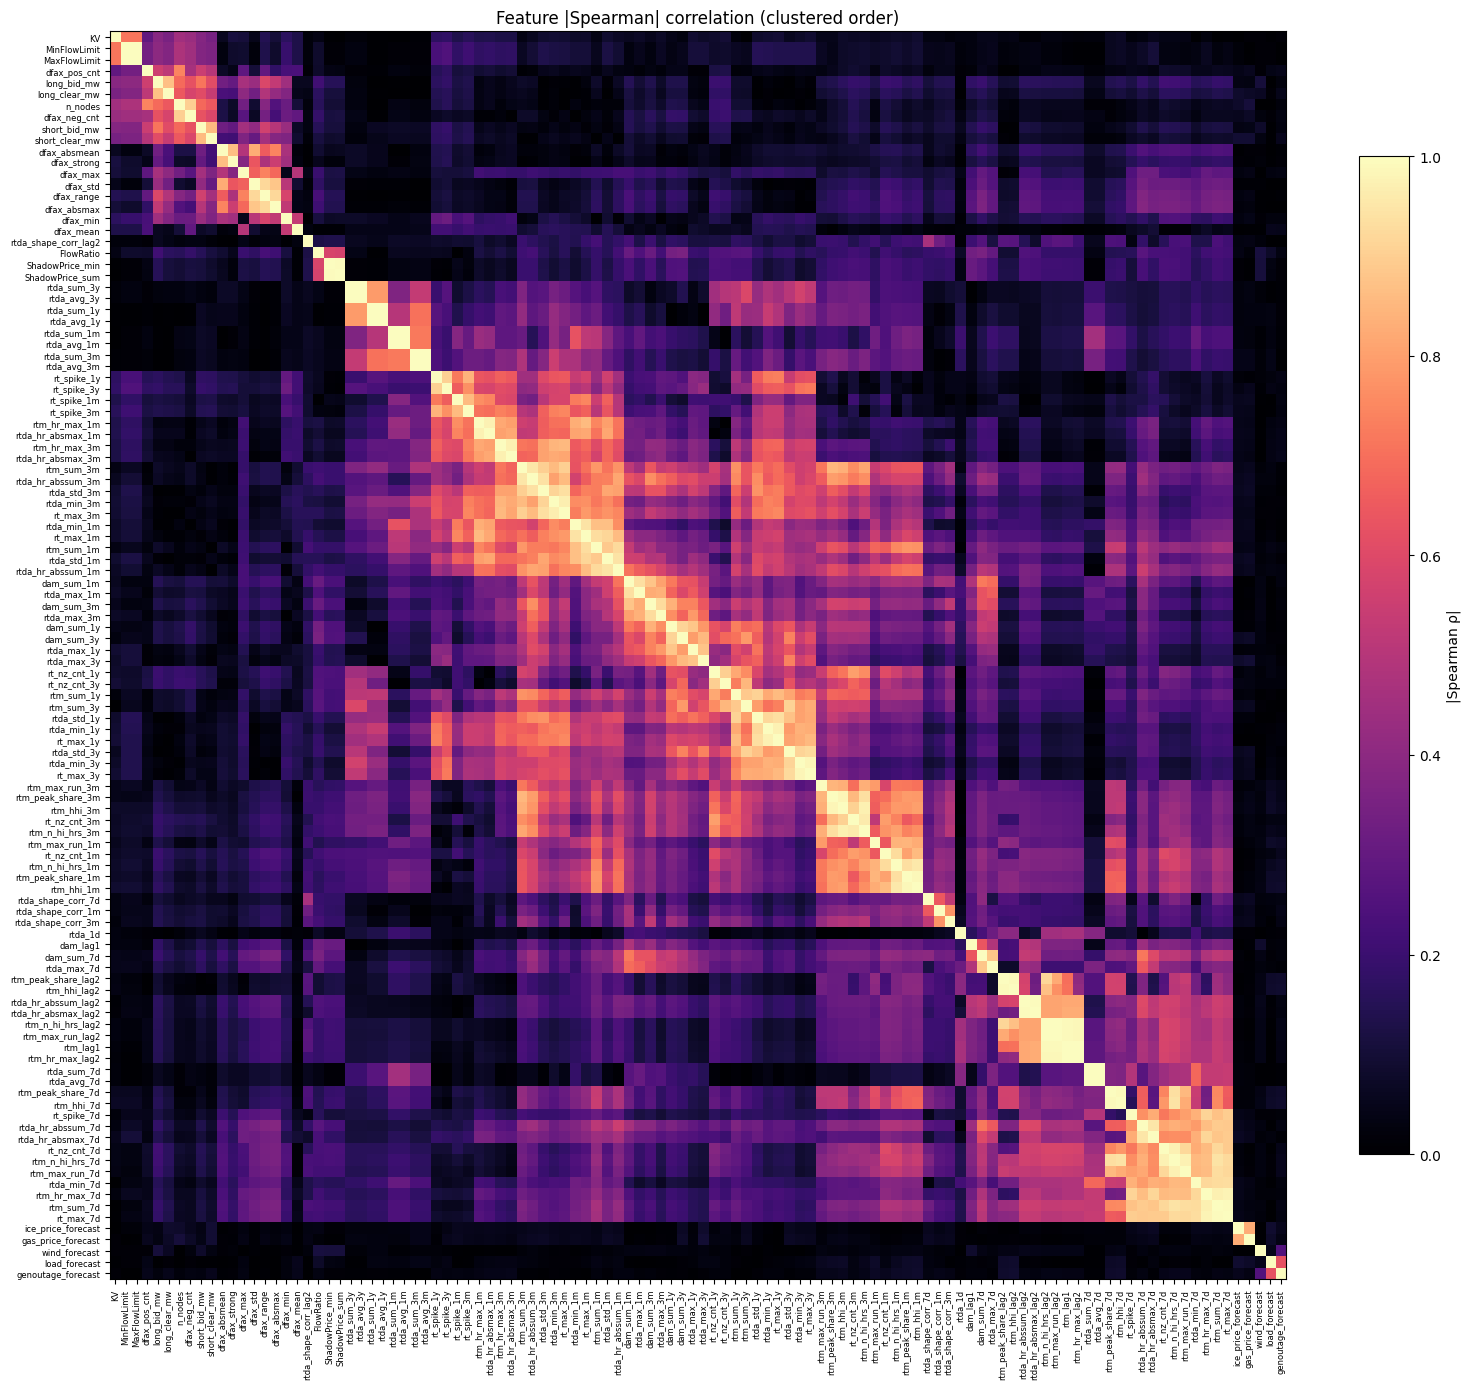

In [62]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
import numpy as np

# |Spearman| correlation on the clustering pool
corr_m = train_df_filter[pool].corr('spearman').abs().fillna(0.0)

# order rows/cols by the average-linkage dendrogram so groups form diagonal blocks
d = 1.0 - corr_m.values
np.fill_diagonal(d, 0.0); d = (d + d.T) / 2
Z = linkage(squareform(d, checks=False), method='average')
order = leaves_list(Z)
ordered = corr_m.iloc[order, order]

fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(ordered.values, cmap='magma', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(ordered))); ax.set_xticklabels(ordered.columns, rotation=90, fontsize=6)
ax.set_yticks(range(len(ordered))); ax.set_yticklabels(ordered.index, fontsize=6)
cbar = fig.colorbar(im, ax=ax, shrink=0.8); cbar.set_label('|Spearman ρ|')
ax.set_title('Feature |Spearman| correlation (clustered order)')
plt.tight_layout(); plt.show()


In [63]:
# columns to keep alongside the decorrelated features
keep_extra = ['dt', 'constraint_family_num',          # keys
              'KV_group',                             # categorical driver (not in numeric compact)
              'bad_rtda', 'rt_da', 'rt_da_q', 'rt_da_smaller_500',   # targets / labels
              'short_profit', 'long_profit', 'profit_congestion',    # P&L for analysis
              'monitored_name']                        # id
keep = compact + [c for c in keep_extra if c in train_df_filter.columns and c not in compact]

train_df_filter = train_df_filter[keep].copy()
print(train_df_filter.shape, '| kept:', len(keep), 'cols')
print('dropped:', len(train_df_filter.columns) if False else '',  # see below
      len(set(train_df_filter.columns)))

(134318, 56) | kept: 56 cols
dropped:  56


# bad_rtda rt-da<-3000 classification 

In [64]:
import numpy as np, pandas as pd, lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, _tree
pd.set_option('display.max_colwidth', None); pd.set_option('display.width', None)

d = train_df_filter.dropna(subset=['bad_rtda']).copy()   # bad_rtda is 0/1
y = d['bad_rtda'].astype(int)
FEATS = globals().get('compact', features)
Xc = d[FEATS + CATS].copy()                              # LightGBM: native categoricals + NaN
for c in CATS: Xc[c] = Xc[c].astype('category')
Xn = d[FEATS + CATS].copy()                              # sklearn: numeric, no NaN
for c in CATS: Xn[c] = Xn[c].astype('category').cat.codes
Xn = Xn.fillna(Xn.median())
feat = list(Xc.columns); pos, N, base = int(y.sum()), len(y), y.mean()
print(f'rows={N}  y=1={pos} ({base*100:.2f}%)')

# ---------- 1) two models + feature importance ----------
lgbm = lgb.LGBMClassifier(n_estimators=400, learning_rate=0.05, num_leaves=31, min_child_samples=50,
                          subsample=0.8, colsample_bytree=0.8, class_weight='balanced',
                          random_state=0, n_jobs=-1, verbose=-1).fit(Xc, y, categorical_feature=CATS)
rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=100,
                            class_weight='balanced_subsample', random_state=0, n_jobs=-1).fit(Xn, y)
li = pd.Series(lgbm.booster_.feature_importance('gain'), index=feat); li /= li.sum()
ri = pd.Series(rf.feature_importances_, index=feat)
imp = pd.concat([li.rename('lgbm_gain'), ri.rename('rf_impurity')], axis=1)
imp['avg_rank'] = imp.rank(ascending=False).mean(axis=1)
print('\n=== feature importance: LGBM vs RandomForest (top 15) ===')
display(imp.sort_values('avg_rank').head(15).round(4))

# ---------- 2) readable tree: split + #1s at EACH node ----------
surr = DecisionTreeClassifier(max_depth=4, min_samples_leaf=100, class_weight='balanced',
                              random_state=0).fit(Xn, y)
dp = surr.decision_path(Xn); yv = y.values.astype(bool)
n1 = np.asarray(dp[yv].sum(0)).ravel(); n0 = np.asarray(dp[~yv].sum(0)).ravel()
t = surr.tree_
print('\n=== tree splits: n1 = #(y=1) at node, purity, recall ===')
def show(nd=0, dep=0, br=''):
    tot = n1[nd] + n0[nd]; pur = n1[nd]/tot*100 if tot else 0; rec = n1[nd]/pos*100
    lab = 'LEAF' if t.feature[nd]==_tree.TREE_UNDEFINED else f'[{feat[t.feature[nd]]} <= {t.threshold[nd]:.3f}]'
    print(f'  {"  "*dep}{br}{lab}  n1={int(n1[nd]):>4}  purity={pur:4.1f}%  recall={rec:4.1f}%')
    if t.feature[nd] != _tree.TREE_UNDEFINED:
        show(t.children_left[nd], dep+1, 'T> ')   # <= thr
        show(t.children_right[nd], dep+1, 'F> ')  # >  thr
show()

# leaf rules ranked by #1s captured (kept from your cell)
rules = {}
def rec(n, c):
    if t.feature[n]==_tree.TREE_UNDEFINED: rules[n]=' AND '.join(c) or '(all)'
    else:
        f, th = feat[t.feature[n]], t.threshold[n]
        rec(t.children_left[n], c+[f'{f} <= {th:.3f}']); rec(t.children_right[n], c+[f'{f} > {th:.3f}'])
rec(0, [])
leaves = [i for i in range(t.node_count) if t.feature[i]==_tree.TREE_UNDEFINED]
tab = (pd.DataFrame([{'n_1':int(n1[i]),'n_rows':int(n1[i]+n0[i]),
                      'recall':round(n1[i]/pos*100,1),'purity':round(n1[i]/(n1[i]+n0[i])*100,1),
                      'rule':rules[i]} for i in leaves]).sort_values('n_1',ascending=False).reset_index(drop=True))
tab['cum_recall'] = (tab['n_1'].cumsum()/pos*100).round(1); tab['cum_rows'] = (tab['n_rows'].cumsum()/N*100).round(1)
print('\n=== leaf rules ranked by # of 1s captured ===')
for _, r in tab.iterrows():
    print(f"n_1={int(r['n_1']):>4}  recall={r['recall']:>5}%  purity={r['purity']:>5}%  "
          f"cum_recall={r['cum_recall']:>5}%  cum_rows={r['cum_rows']:>5}%")
    print(f"     RULE: {r['rule']}")


rows=134318  y=1=1941 (1.45%)

=== feature importance: LGBM vs RandomForest (top 15) ===


,lgbm_gain,rf_impurity,avg_rank
rtda_hr_abssum_7d,0.1616,0.1015,1.0
rtm_sum_1m,0.0716,0.0693,2.0
rtm_hr_max_1m,0.0538,0.0660,3.0
rtm_hr_max_lag2,0.0384,0.0589,5.5
rt_spike_3y,0.0387,0.0400,6.0
rtda_std_3m,0.0306,0.0553,7.0
FlowRatio,0.0409,0.0310,7.5
wind_forecast,0.0421,0.0300,8.0
rtm_peak_share_7d,0.0300,0.0322,9.5
rtda_std_1y,0.0194,0.0338,10.5



=== tree splits: n1 = #(y=1) at node, purity, recall ===
  [rtda_hr_abssum_7d <= 2819.103]  n1=1941  purity= 1.4%  recall=100.0%
    T> [rtm_hr_max_1m <= 459.415]  n1= 614  purity= 0.6%  recall=31.6%
      T> [rt_spike_3y <= -621.188]  n1= 132  purity= 0.2%  recall= 6.8%
        T> [rtda_sum_7d <= -459.668]  n1=  93  purity= 0.5%  recall= 4.8%
          T> LEAF  n1=  38  purity= 1.4%  recall= 2.0%
          F> LEAF  n1=  55  purity= 0.3%  recall= 2.8%
        F> [genoutage_forecast <= 29414.040]  n1=  39  purity= 0.1%  recall= 2.0%
          T> LEAF  n1=  27  purity= 0.1%  recall= 1.4%
          F> LEAF  n1=  12  purity= 0.9%  recall= 0.6%
      F> [rtm_hr_max_lag2 <= 36.885]  n1= 482  purity= 1.0%  recall=24.8%
        T> [FlowRatio <= 0.846]  n1= 354  purity= 0.8%  recall=18.2%
          T> LEAF  n1= 211  purity= 0.6%  recall=10.9%
          F> LEAF  n1= 143  purity= 1.7%  recall= 7.4%
        F> [rt_spike_3y <= -298.026]  n1= 128  purity= 2.9%  recall= 6.6%
          T> LEAF  n1= 1

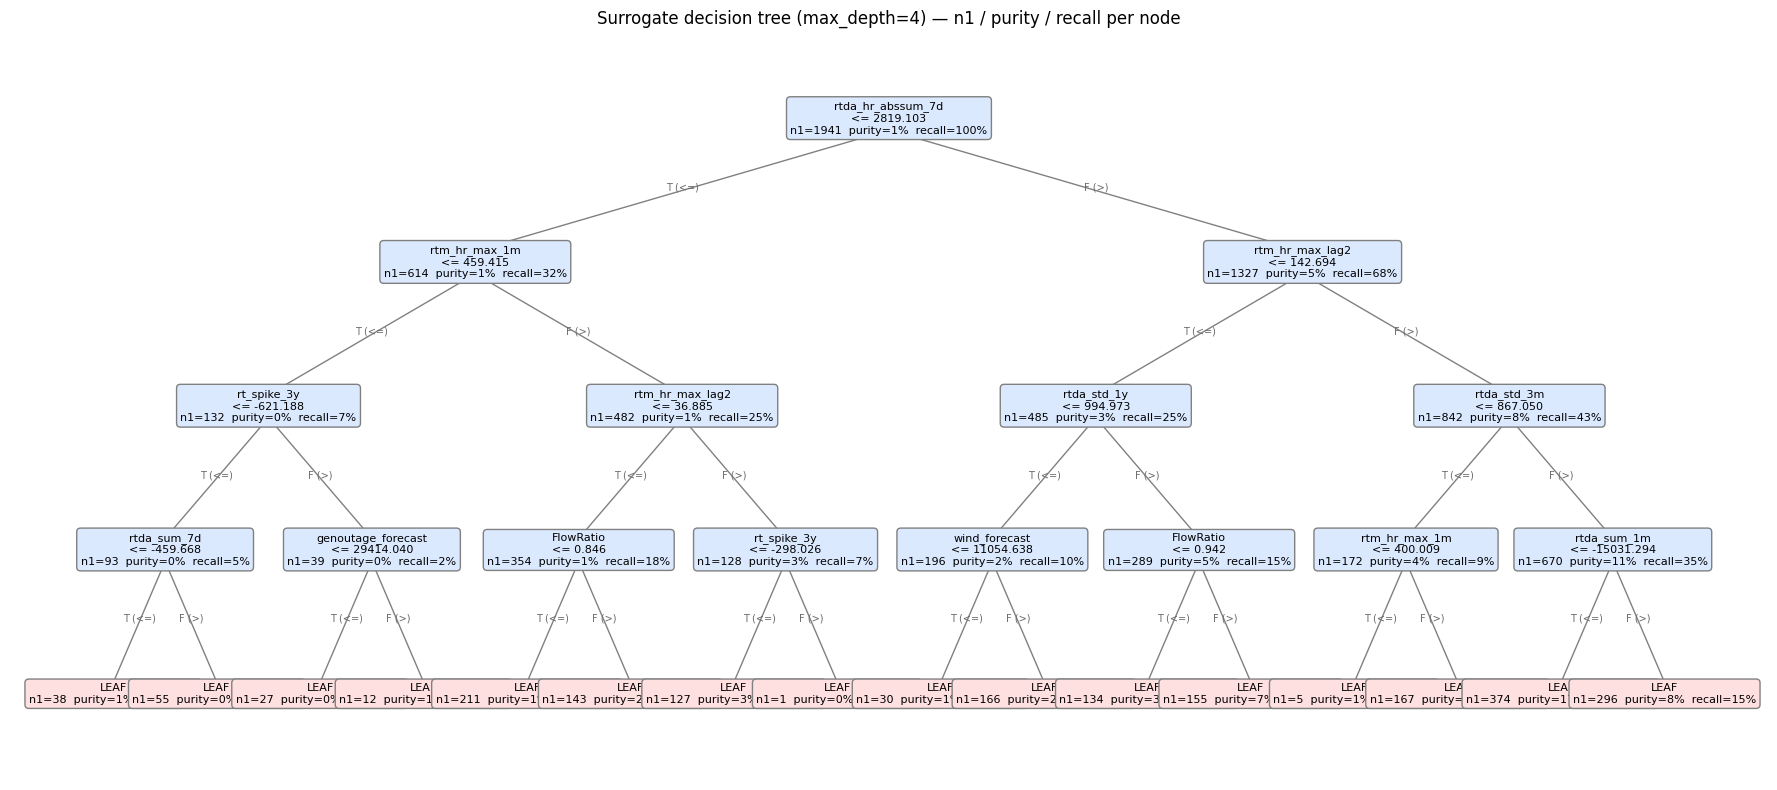

In [65]:
import matplotlib.pyplot as plt

# ---------- visualize the surrogate tree as an actual tree diagram ----------
pos_xy, _xctr = {}, [0]
def _layout(nd, depth):
    if t.feature[nd] == _tree.TREE_UNDEFINED:
        x = _xctr[0]; _xctr[0] += 1
        pos_xy[nd] = (x, -depth)
        return x
    lx = _layout(t.children_left[nd], depth + 1)
    rx = _layout(t.children_right[nd], depth + 1)
    x = (lx + rx) / 2
    pos_xy[nd] = (x, -depth)
    return x
_layout(0, 0)

fig, ax = plt.subplots(figsize=(18, 8))
for nd in range(t.node_count):
    x, y = pos_xy[nd]
    tot = n1[nd] + n0[nd]; pur = n1[nd] / tot * 100 if tot else 0; rec = n1[nd] / pos * 100
    is_leaf = t.feature[nd] == _tree.TREE_UNDEFINED
    lab = 'LEAF' if is_leaf else f'{feat[t.feature[nd]]}\n<= {t.threshold[nd]:.3f}'
    box_txt = f'{lab}\nn1={int(n1[nd])}  purity={pur:.0f}%  recall={rec:.0f}%'
    color = '#ffe0e0' if is_leaf else '#dbe9ff'
    ax.text(x, y, box_txt, ha='center', va='center', fontsize=8, zorder=2,
            bbox=dict(boxstyle='round,pad=0.35', fc=color, ec='gray'))
    if not is_leaf:
        for child, edge_lab in ((t.children_left[nd], 'T (<=)'), (t.children_right[nd], 'F (>)')):
            cx, cy = pos_xy[child]
            ax.plot([x, cx], [y - 0.08, cy + 0.08], color='gray', lw=1, zorder=1)
            ax.text((x + cx) / 2, (y + cy) / 2, edge_lab, fontsize=7, color='dimgray', ha='center')

xs = [p[0] for p in pos_xy.values()]; ys = [p[1] for p in pos_xy.values()]
ax.set_xlim(min(xs) - 1, max(xs) + 1); ax.set_ylim(min(ys) - 0.6, max(ys) + 0.6)
ax.axis('off')
ax.set_title('Surrogate decision tree (max_depth=4) — n1 / purity / recall per node')
plt.tight_layout()
plt.show()


In [64]:
from sklearn.metrics import (recall_score, precision_score, f1_score, accuracy_score,
                              roc_auc_score, average_precision_score, confusion_matrix)

# ---------- 4) out-of-sample check on holdout_df ----------
dh = holdout_df.query('rtm_sum_1m<-200').dropna(subset=['bad_rtda']).copy()
yh = dh['bad_rtda'].astype(int)
Xc_h = dh[FEATS + CATS].copy()                            # LightGBM: native categoricals + NaN
for c in CATS: Xc_h[c] = Xc_h[c].astype('category')
Xn_h = dh[FEATS + CATS].copy()                             # sklearn: numeric, no NaN
for c in CATS: Xn_h[c] = Xn_h[c].astype('category').cat.codes
Xn_h = Xn_h.fillna(Xn.median())                             # fill with TRAIN medians -> no leakage

pos_h, N_h, base_h = int(yh.sum()), len(yh), yh.mean()
print(f'holdout_df: rows={N_h}  y=1={pos_h} ({base_h*100:.2f}%)')

def eval_model(name, model, X):
    proba = model.predict_proba(X)[:, 1]
    pred = model.predict(X)
    tn, fp, fn, tp = confusion_matrix(yh, pred).ravel()
    print(f'\n=== {name} on holdout_df ===')
    print(f'  recall={recall_score(yh, pred):.3f}  precision={precision_score(yh, pred):.3f}  '
          f'f1={f1_score(yh, pred):.3f}  accuracy={accuracy_score(yh, pred):.3f}')
    print(f'  roc_auc={roc_auc_score(yh, proba):.3f}  pr_auc={average_precision_score(yh, proba):.3f}')
    print(f'  confusion: tp={tp} fn={fn} fp={fp} tn={tn}')

eval_model('LightGBM', lgbm, Xc_h)
eval_model('RandomForest', rf, Xn_h)


holdout_df: rows=50392  y=1=718 (1.42%)

=== LightGBM on holdout_df ===
  recall=0.471  precision=0.102  f1=0.167  accuracy=0.933
  roc_auc=0.857  pr_auc=0.097
  confusion: tp=338 fn=380 fp=2989 tn=46685

=== RandomForest on holdout_df ===
  recall=0.547  precision=0.090  f1=0.155  accuracy=0.915
  roc_auc=0.859  pr_auc=0.143
  confusion: tp=393 fn=325 fp=3955 tn=45719


# Pinball loss on the rt-da 

In [66]:
import numpy as np, pandas as pd, lightgbm as lgb
from sklearn.metrics import mean_pinball_loss
pd.set_option('display.max_colwidth', None)

d = train_df_filter.dropna(subset=['rt_da']).copy()
y = d['rt_da'].astype(float)
FEATS = globals().get('compact', features)
X = d[FEATS + CATS].copy()
for c in CATS: X[c] = X[c].astype('category')
print(f'rows={len(d)}  rt_da mean={y.mean():.1f}  median={y.median():.1f}  p1={y.quantile(.01):.1f}  p5={y.quantile(.05):.1f}')

# quantile regression via pinball loss (LightGBM objective='quantile') at several taus,
# focused on the LEFT tail since that's the side we care about for risk cut
TAUS = [0.05]
models, preds, scores = {}, {}, {}
for tau in TAUS:
    m = lgb.LGBMRegressor(objective='quantile', alpha=tau,
                          n_estimators=400, learning_rate=0.05, num_leaves=31, min_child_samples=50,
                          subsample=0.8, colsample_bytree=0.8, random_state=0, n_jobs=-1, verbose=-1)
    m.fit(X, y, categorical_feature=CATS)
    models[tau] = m
    preds[tau]  = m.predict(X)
    scores[tau] = mean_pinball_loss(y, preds[tau], alpha=tau)

print('\n=== pinball loss by quantile (in-sample) ===')
for tau in TAUS:
    print(f'  tau={tau:<5} pinball_loss={scores[tau]:.2f}')

# feature importance from the tau=0.05 model (the tail we actually care about)
imp = pd.Series(models[0.05].booster_.feature_importance('gain'), index=X.columns)
imp = (imp / imp.sum()).sort_values(ascending=False)
print('\n=== feature importance (gain) — tau=0.05 quantile model ===')
display(imp.head(15).round(4).to_frame('gain'))

# coverage check: what fraction of actual rt_da fall below the predicted tau-quantile?
# should be close to tau if the model is well-calibrated
print('\n=== calibration: P(rt_da < predicted q_tau) vs tau ===')
for tau in TAUS:
    cov = (y.values < preds[tau]).mean()
    print(f'  tau={tau:<5} target={tau:.2f}  actual_coverage={cov:.3f}')


rows=134318  rt_da mean=-65.8  median=0.0  p1=-3852.6  p5=-740.5

=== pinball loss by quantile (in-sample) ===
  tau=0.05  pinball_loss=77.44

=== feature importance (gain) — tau=0.05 quantile model ===


,gain
rtm_peak_share_7d,0.0974
rtda_hr_abssum_7d,0.0752
FlowRatio,0.0664
rt_nz_cnt_1y,0.0497
rtm_sum_1m,0.0430
rtda_sum_1y,0.0360
rtm_hr_max_lag2,0.0349
rtm_peak_share_3m,0.0336
wind_forecast,0.0301
rt_spike_3y,0.0297



=== calibration: P(rt_da < predicted q_tau) vs tau ===
  tau=0.05  target=0.05  actual_coverage=0.045


In [70]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor, _tree

# ---------- readable tree: split + node stats at EACH node, on rt_da ----------
Xn = d[FEATS + CATS].copy()
for c in CATS: Xn[c] = Xn[c].astype('category').cat.codes
Xn = Xn.fillna(Xn.median())
feat = list(Xn.columns)

surr = DecisionTreeRegressor(max_depth=4, min_samples_leaf=100, random_state=0).fit(Xn, y)
t = surr.tree_
node_mean = t.value[:, 0, 0]
node_n = t.n_node_samples
print('\n=== tree splits: mean rt_da / n_rows at EACH node ===')
def show(nd=0, dep=0, br=''):
    lab = 'LEAF' if t.feature[nd]==_tree.TREE_UNDEFINED else f'[{feat[t.feature[nd]]} <= {t.threshold[nd]:.3f}]'
    print(f'  {"  "*dep}{br}{lab}  mean={node_mean[nd]:>10.1f}  n_rows={int(node_n[nd]):>5}')
    if t.feature[nd] != _tree.TREE_UNDEFINED:
        show(t.children_left[nd], dep+1, 'T> ')   # <= thr
        show(t.children_right[nd], dep+1, 'F> ')  # >  thr
show()

# leaf rules ranked by worst (most negative) mean rt_da
rules = {}
def rec(n, c):
    if t.feature[n]==_tree.TREE_UNDEFINED: rules[n]=' AND '.join(c) or '(all)'
    else:
        f, th = feat[t.feature[n]], t.threshold[n]
        rec(t.children_left[n], c+[f'{f} <= {th:.3f}']); rec(t.children_right[n], c+[f'{f} > {th:.3f}'])
rec(0, [])
leaves = [i for i in range(t.node_count) if t.feature[i]==_tree.TREE_UNDEFINED]
tab = (pd.DataFrame([{'mean':round(node_mean[i],1),'n_rows':int(node_n[i]),
                      'rule':rules[i]} for i in leaves]).sort_values('mean').reset_index(drop=True))
tab['cum_rows'] = (tab['n_rows'].cumsum()/len(y)*100).round(1)
print('\n=== leaf rules ranked by worst mean rt_da ===')
for _, r in tab.iterrows():
    print(f"mean={r['mean']:>10.1f}  n_rows={int(r['n_rows']):>5}  cum_rows={r['cum_rows']:>5}%")
    print(f"     RULE: {r['rule']}")



=== tree splits: mean rt_da / n_rows at EACH node ===
  [rtda_sum_1m <= -40237.551]  mean=     -65.8  n_rows=134318
    T> [rtda_1d <= -543.107]  mean=   -1152.2  n_rows= 1256
      T> [dam_lag1 <= -3.534]  mean=   -2216.5  n_rows=  460
        T> LEAF  mean=     179.6  n_rows=  123
        F> [rtm_peak_share_7d <= 0.053]  mean=   -3091.1  n_rows=  337
          T> LEAF  mean=   -4050.5  n_rows=  189
          F> LEAF  mean=   -1865.8  n_rows=  148
      F> [load_forecast <= 34774.855]  mean=    -537.1  n_rows=  796
        T> [dam_sum_1m <= -23581.866]  mean=    -362.5  n_rows=  682
          T> LEAF  mean=     432.4  n_rows=  138
          F> LEAF  mean=    -564.1  n_rows=  544
        F> LEAF  mean=   -1581.8  n_rows=  114
    F> [rtda_sum_7d <= -1041.125]  mean=     -55.5  n_rows=133062
      T> [rtda_avg_3m <= -385.298]  mean=    -195.3  n_rows=25074
        T> [rtda_1d <= -396.690]  mean=    -568.4  n_rows= 2334
          T> LEAF  mean=    -856.7  n_rows=  918
          F> LEAF 

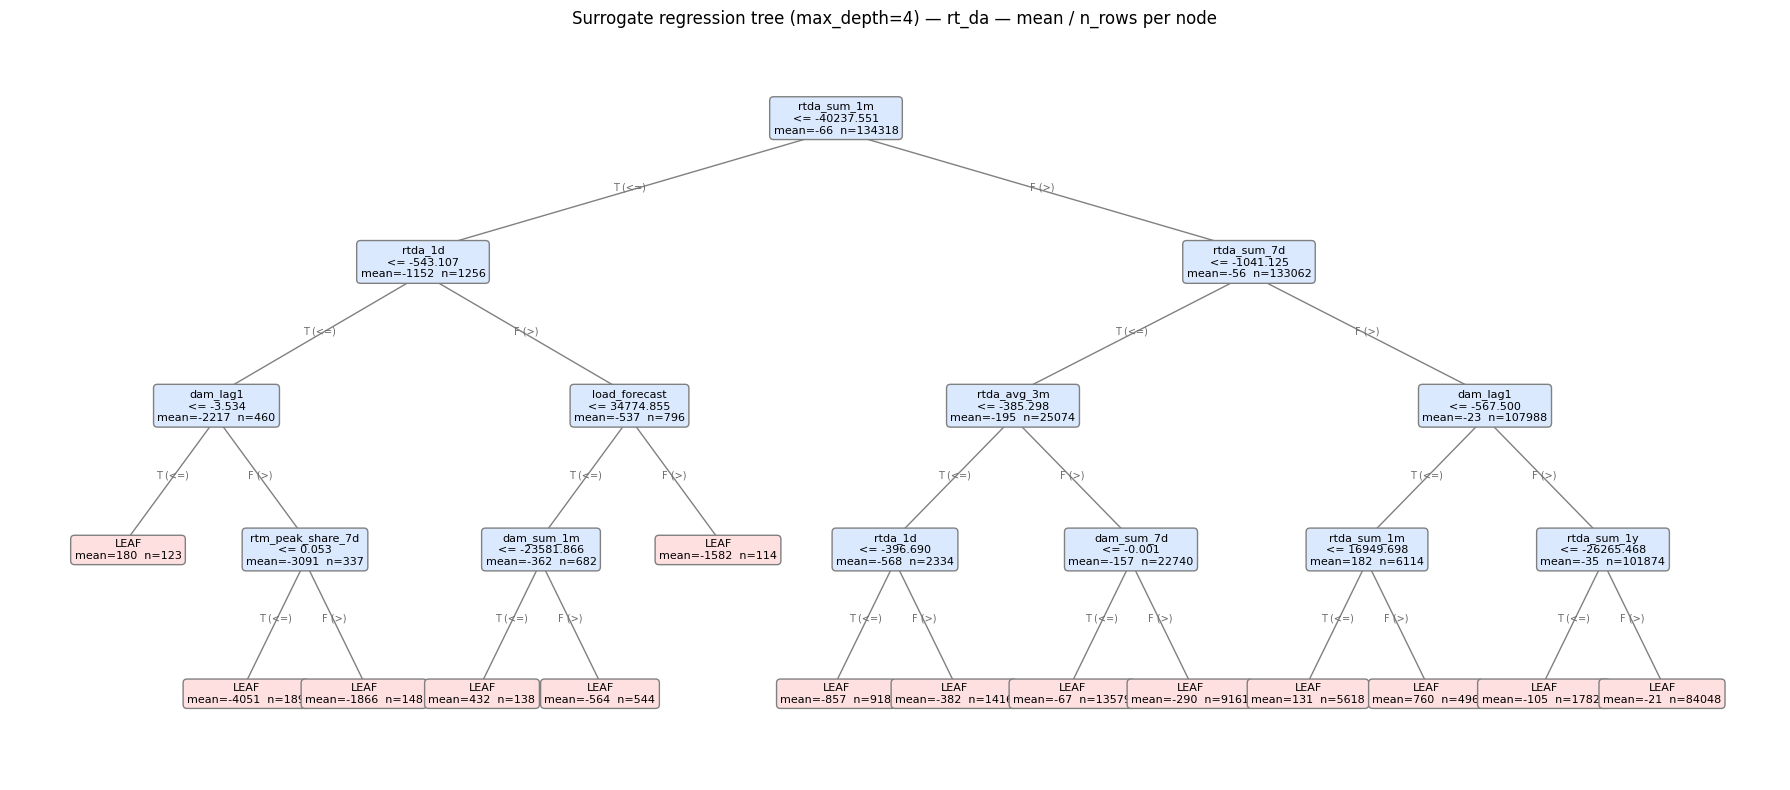

In [71]:
import matplotlib.pyplot as plt

# ---------- visualize the surrogate tree as an actual tree diagram ----------
pos_xy, _xctr = {}, [0]
def _layout(nd, depth):
    if t.feature[nd] == _tree.TREE_UNDEFINED:
        x = _xctr[0]; _xctr[0] += 1
        pos_xy[nd] = (x, -depth)
        return x
    lx = _layout(t.children_left[nd], depth + 1)
    rx = _layout(t.children_right[nd], depth + 1)
    x = (lx + rx) / 2
    pos_xy[nd] = (x, -depth)
    return x
_layout(0, 0)

fig, ax = plt.subplots(figsize=(18, 8))
for nd in range(t.node_count):
    x, y_ = pos_xy[nd]
    is_leaf = t.feature[nd] == _tree.TREE_UNDEFINED
    lab = 'LEAF' if is_leaf else f'{feat[t.feature[nd]]}\n<= {t.threshold[nd]:.3f}'
    box_txt = f'{lab}\nmean={node_mean[nd]:.0f}  n={int(node_n[nd])}'
    color = '#ffe0e0' if is_leaf else '#dbe9ff'
    ax.text(x, y_, box_txt, ha='center', va='center', fontsize=8, zorder=2,
            bbox=dict(boxstyle='round,pad=0.35', fc=color, ec='gray'))
    if not is_leaf:
        for child, edge_lab in ((t.children_left[nd], 'T (<=)'), (t.children_right[nd], 'F (>)')):
            cx, cy = pos_xy[child]
            ax.plot([x, cx], [y_ - 0.08, cy + 0.08], color='gray', lw=1, zorder=1)
            ax.text((x + cx) / 2, (y_ + cy) / 2, edge_lab, fontsize=7, color='dimgray', ha='center')

xs = [p[0] for p in pos_xy.values()]; ys = [p[1] for p in pos_xy.values()]
ax.set_xlim(min(xs) - 1, max(xs) + 1); ax.set_ylim(min(ys) - 0.6, max(ys) + 0.6)
ax.axis('off')
ax.set_title('Surrogate regression tree (max_depth=4) — rt_da — mean / n_rows per node')
plt.tight_layout()
plt.show()


# rerun without top variable 

In [98]:
import numpy as np, pandas as pd, lightgbm as lgb
from sklearn.metrics import mean_pinball_loss
pd.set_option('display.max_colwidth', None)

d = train_df_filter.dropna(subset=['rt_da']).copy()
y = d['rt_da'].astype(float)
FEATS = [f for f in globals().get('compact', features) if f not in (['rtm_sum_7d','rtda_sum_7d','rtm_sum_3m','rtda_avg_7d','rt_max_3m', 'long_profit_sum_1m','short_profit_sum_1m'])]
X = d[FEATS + CATS].copy()
for c in CATS: X[c] = X[c].astype('category')
print(f'rows={len(d)}  rt_da mean={y.mean():.1f}  median={y.median():.1f}  p1={y.quantile(.01):.1f}  p5={y.quantile(.05):.1f}')

# quantile regression via pinball loss (LightGBM objective='quantile') at several taus,
# focused on the LEFT tail since that's the side we care about for risk cut
TAUS = [0.05]
models, preds, scores = {}, {}, {}
for tau in TAUS:
    m = lgb.LGBMRegressor(objective='quantile', alpha=tau,
                          n_estimators=400, learning_rate=0.05, num_leaves=31, min_child_samples=50,
                          subsample=0.8, colsample_bytree=0.8, random_state=0, n_jobs=-1, verbose=-1)
    m.fit(X, y, categorical_feature=CATS)
    models[tau] = m
    preds[tau]  = m.predict(X)
    scores[tau] = mean_pinball_loss(y, preds[tau], alpha=tau)

print('\n=== pinball loss by quantile (in-sample) ===')
for tau in TAUS:
    print(f'  tau={tau:<5} pinball_loss={scores[tau]:.2f}')

# feature importance from the tau=0.05 model (the tail we actually care about)
imp = pd.Series(models[0.05].booster_.feature_importance('gain'), index=X.columns)
imp = (imp / imp.sum()).sort_values(ascending=False)
print('\n=== feature importance (gain) — tau=0.05 quantile model ===')
display(imp.head(15).round(4).to_frame('gain'))

# coverage check: what fraction of actual rt_da fall below the predicted tau-quantile?
# should be close to tau if the model is well-calibrated
print('\n=== calibration: P(rt_da < predicted q_tau) vs tau ===')
for tau in TAUS:
    cov = (y.values < preds[tau]).mean()
    print(f'  tau={tau:<5} target={tau:.2f}  actual_coverage={cov:.3f}')


rows=134337  rt_da mean=-88.4  median=0.0  p1=-4525.8  p5=-813.4

=== pinball loss by quantile (in-sample) ===
  tau=0.05  pinball_loss=80.67

=== feature importance (gain) — tau=0.05 quantile model ===


,gain
dfax_absmax,0.1029
rtm_lag1,0.0668
FlowRatio,0.0639
rtm_sum_1m,0.0623
rt_nz_cnt_1m,0.0601
dfax_absmean,0.0442
wind_forecast,0.0418
rtda_std_1y,0.0389
rt_nz_cnt_1y,0.0367
rt_spike_3m,0.0362



=== calibration: P(rt_da < predicted q_tau) vs tau ===
  tau=0.05  target=0.05  actual_coverage=0.045


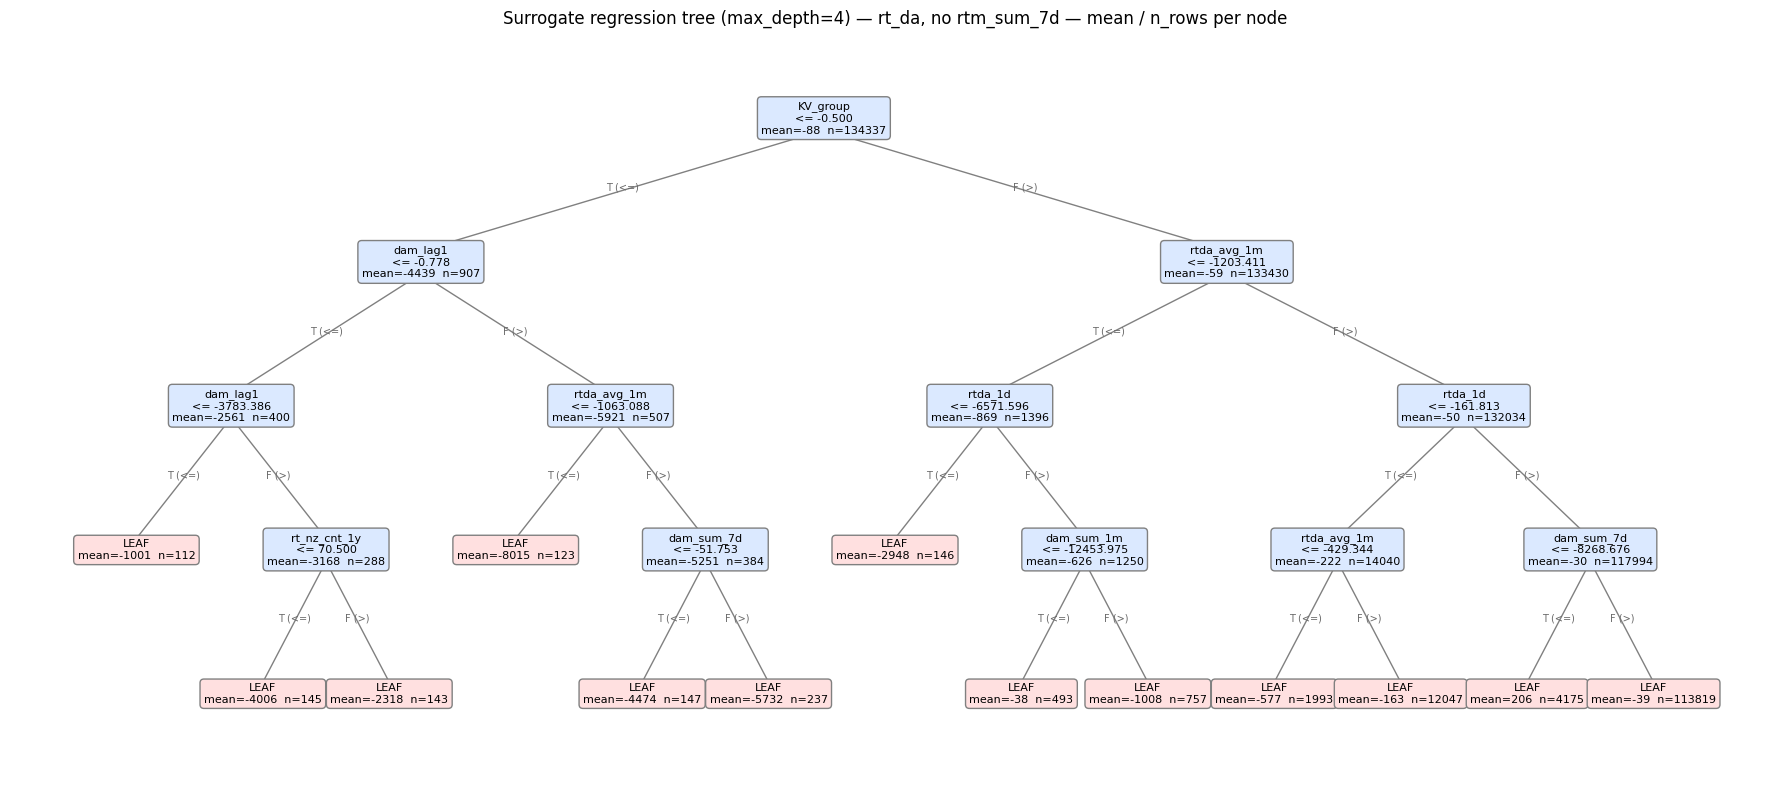

In [99]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, _tree

# ---------- fit the surrogate tree on THIS section's d/y/FEATS (no rtm_sum_7d) ----------
Xn = d[FEATS + CATS].copy()
for c in CATS: Xn[c] = Xn[c].astype('category').cat.codes
Xn = Xn.fillna(Xn.median())
feat = list(Xn.columns)

surr = DecisionTreeRegressor(max_depth=4, min_samples_leaf=100, random_state=0).fit(Xn, y)
t = surr.tree_
node_mean = t.value[:, 0, 0]
node_n = t.n_node_samples

# ---------- visualize the surrogate tree as an actual tree diagram ----------
pos_xy, _xctr = {}, [0]
def _layout(nd, depth):
    if t.feature[nd] == _tree.TREE_UNDEFINED:
        x = _xctr[0]; _xctr[0] += 1
        pos_xy[nd] = (x, -depth)
        return x
    lx = _layout(t.children_left[nd], depth + 1)
    rx = _layout(t.children_right[nd], depth + 1)
    x = (lx + rx) / 2
    pos_xy[nd] = (x, -depth)
    return x
_layout(0, 0)

fig, ax = plt.subplots(figsize=(18, 8))
for nd in range(t.node_count):
    x, y_ = pos_xy[nd]
    is_leaf = t.feature[nd] == _tree.TREE_UNDEFINED
    lab = 'LEAF' if is_leaf else f'{feat[t.feature[nd]]}\n<= {t.threshold[nd]:.3f}'
    box_txt = f'{lab}\nmean={node_mean[nd]:.0f}  n={int(node_n[nd])}'
    color = '#ffe0e0' if is_leaf else '#dbe9ff'
    ax.text(x, y_, box_txt, ha='center', va='center', fontsize=8, zorder=2,
            bbox=dict(boxstyle='round,pad=0.35', fc=color, ec='gray'))
    if not is_leaf:
        for child, edge_lab in ((t.children_left[nd], 'T (<=)'), (t.children_right[nd], 'F (>)')):
            cx, cy = pos_xy[child]
            ax.plot([x, cx], [y_ - 0.08, cy + 0.08], color='gray', lw=1, zorder=1)
            ax.text((x + cx) / 2, (y_ + cy) / 2, edge_lab, fontsize=7, color='dimgray', ha='center')

xs = [p[0] for p in pos_xy.values()]; ys = [p[1] for p in pos_xy.values()]
ax.set_xlim(min(xs) - 1, max(xs) + 1); ax.set_ylim(min(ys) - 0.6, max(ys) + 0.6)
ax.axis('off')
ax.set_title('Surrogate regression tree (max_depth=4) — rt_da, no rtm_sum_7d — mean / n_rows per node')
plt.tight_layout()
plt.show()


In [89]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor, _tree

# ---------- readable tree: split + node stats at EACH node, on rt_da ----------
Xn = d[FEATS + CATS].copy()
for c in CATS: Xn[c] = Xn[c].astype('category').cat.codes
Xn = Xn.fillna(Xn.median())
feat = list(Xn.columns)

surr = DecisionTreeRegressor(max_depth=4, min_samples_leaf=100, random_state=0).fit(Xn, y)
t = surr.tree_
node_mean = t.value[:, 0, 0]
node_n = t.n_node_samples
print('\n=== tree splits: mean rt_da / n_rows at EACH node ===')
def show(nd=0, dep=0, br=''):
    lab = 'LEAF' if t.feature[nd]==_tree.TREE_UNDEFINED else f'[{feat[t.feature[nd]]} <= {t.threshold[nd]:.3f}]'
    print(f'  {"  "*dep}{br}{lab}  mean={node_mean[nd]:>10.1f}  n_rows={int(node_n[nd]):>5}')
    if t.feature[nd] != _tree.TREE_UNDEFINED:
        show(t.children_left[nd], dep+1, 'T> ')   # <= thr
        show(t.children_right[nd], dep+1, 'F> ')  # >  thr
show()

# leaf rules ranked by worst (most negative) mean rt_da
rules = {}
def rec(n, c):
    if t.feature[n]==_tree.TREE_UNDEFINED: rules[n]=' AND '.join(c) or '(all)'
    else:
        f, th = feat[t.feature[n]], t.threshold[n]
        rec(t.children_left[n], c+[f'{f} <= {th:.3f}']); rec(t.children_right[n], c+[f'{f} > {th:.3f}'])
rec(0, [])
leaves = [i for i in range(t.node_count) if t.feature[i]==_tree.TREE_UNDEFINED]
tab = (pd.DataFrame([{'mean':round(node_mean[i],1),'n_rows':int(node_n[i]),
                      'rule':rules[i]} for i in leaves]).sort_values('mean').reset_index(drop=True))
tab['cum_rows'] = (tab['n_rows'].cumsum()/len(y)*100).round(1)
print('\n=== leaf rules ranked by worst mean rt_da ===')
for _, r in tab.iterrows():
    print(f"mean={r['mean']:>10.1f}  n_rows={int(r['n_rows']):>5}  cum_rows={r['cum_rows']:>5}%")
    print(f"     RULE: {r['rule']}")



=== tree splits: mean rt_da / n_rows at EACH node ===
  [KV_group <= -0.500]  mean=     -88.4  n_rows=134337
    T> [dam_lag1 <= -0.778]  mean=   -4439.4  n_rows=  907
      T> [dam_lag1 <= -3783.386]  mean=   -2561.2  n_rows=  400
        T> LEAF  mean=   -1001.1  n_rows=  112
        F> [rt_nz_cnt_1y <= 70.500]  mean=   -3167.9  n_rows=  288
          T> LEAF  mean=   -4006.3  n_rows=  145
          F> LEAF  mean=   -2317.7  n_rows=  143
      F> [rtda_avg_1m <= -1063.088]  mean=   -5921.2  n_rows=  507
        T> LEAF  mean=   -8015.0  n_rows=  123
        F> [dam_sum_7d <= -51.753]  mean=   -5250.6  n_rows=  384
          T> LEAF  mean=   -4473.8  n_rows=  147
          F> LEAF  mean=   -5732.4  n_rows=  237
    F> [rtda_avg_1m <= -1203.411]  mean=     -58.9  n_rows=133430
      T> [rtda_1d <= -6571.596]  mean=    -868.5  n_rows= 1396
        T> LEAF  mean=   -2948.2  n_rows=  146
        F> [dam_sum_1m <= -12453.975]  mean=    -625.6  n_rows= 1250
          T> LEAF  mean=     -38

# Rerun with selected variables: KV, FlowRatio, rtm_sum_7d, dam_sum_7d, rt_da_std_1m

In [100]:
import numpy as np, pandas as pd, lightgbm as lgb
from sklearn.metrics import mean_pinball_loss
pd.set_option('display.max_colwidth', None)

d = train_df_filter.dropna(subset=['rt_da']).copy()
y = d['rt_da'].astype(float)
FEATS = [f for f in globals().get('compact', features) if f  in (['rtm_sum_7d','rtm_sum_3m','rtm_lag1','FlowRatio'])]
X = d[FEATS + CATS].copy()
for c in CATS: X[c] = X[c].astype('category')
print(f'rows={len(d)}  rt_da mean={y.mean():.1f}  median={y.median():.1f}  p1={y.quantile(.01):.1f}  p5={y.quantile(.05):.1f}')

# quantile regression via pinball loss (LightGBM objective='quantile') at several taus,
# focused on the LEFT tail since that's the side we care about for risk cut
TAUS = [0.05]
models, preds, scores = {}, {}, {}
for tau in TAUS:
    m = lgb.LGBMRegressor(objective='quantile', alpha=tau,
                          n_estimators=400, learning_rate=0.05, num_leaves=31, min_child_samples=50,
                          subsample=0.8, colsample_bytree=0.8, random_state=0, n_jobs=-1, verbose=-1)
    m.fit(X, y, categorical_feature=CATS)
    models[tau] = m
    preds[tau]  = m.predict(X)
    scores[tau] = mean_pinball_loss(y, preds[tau], alpha=tau)

print('\n=== pinball loss by quantile (in-sample) ===')
for tau in TAUS:
    print(f'  tau={tau:<5} pinball_loss={scores[tau]:.2f}')

# feature importance from the tau=0.05 model (the tail we actually care about)
imp = pd.Series(models[0.05].booster_.feature_importance('gain'), index=X.columns)
imp = (imp / imp.sum()).sort_values(ascending=False)
print('\n=== feature importance (gain) — tau=0.05 quantile model ===')
display(imp.head(15).round(4).to_frame('gain'))

# coverage check: what fraction of actual rt_da fall below the predicted tau-quantile?
# should be close to tau if the model is well-calibrated
print('\n=== calibration: P(rt_da < predicted q_tau) vs tau ===')
for tau in TAUS:
    cov = (y.values < preds[tau]).mean()
    print(f'  tau={tau:<5} target={tau:.2f}  actual_coverage={cov:.3f}')


rows=134337  rt_da mean=-88.4  median=0.0  p1=-4525.8  p5=-813.4

=== pinball loss by quantile (in-sample) ===
  tau=0.05  pinball_loss=96.18

=== feature importance (gain) — tau=0.05 quantile model ===


,gain
rtm_sum_7d,0.4173
FlowRatio,0.2348
KV_group,0.2128
rtm_lag1,0.1351



=== calibration: P(rt_da < predicted q_tau) vs tau ===
  tau=0.05  target=0.05  actual_coverage=0.043


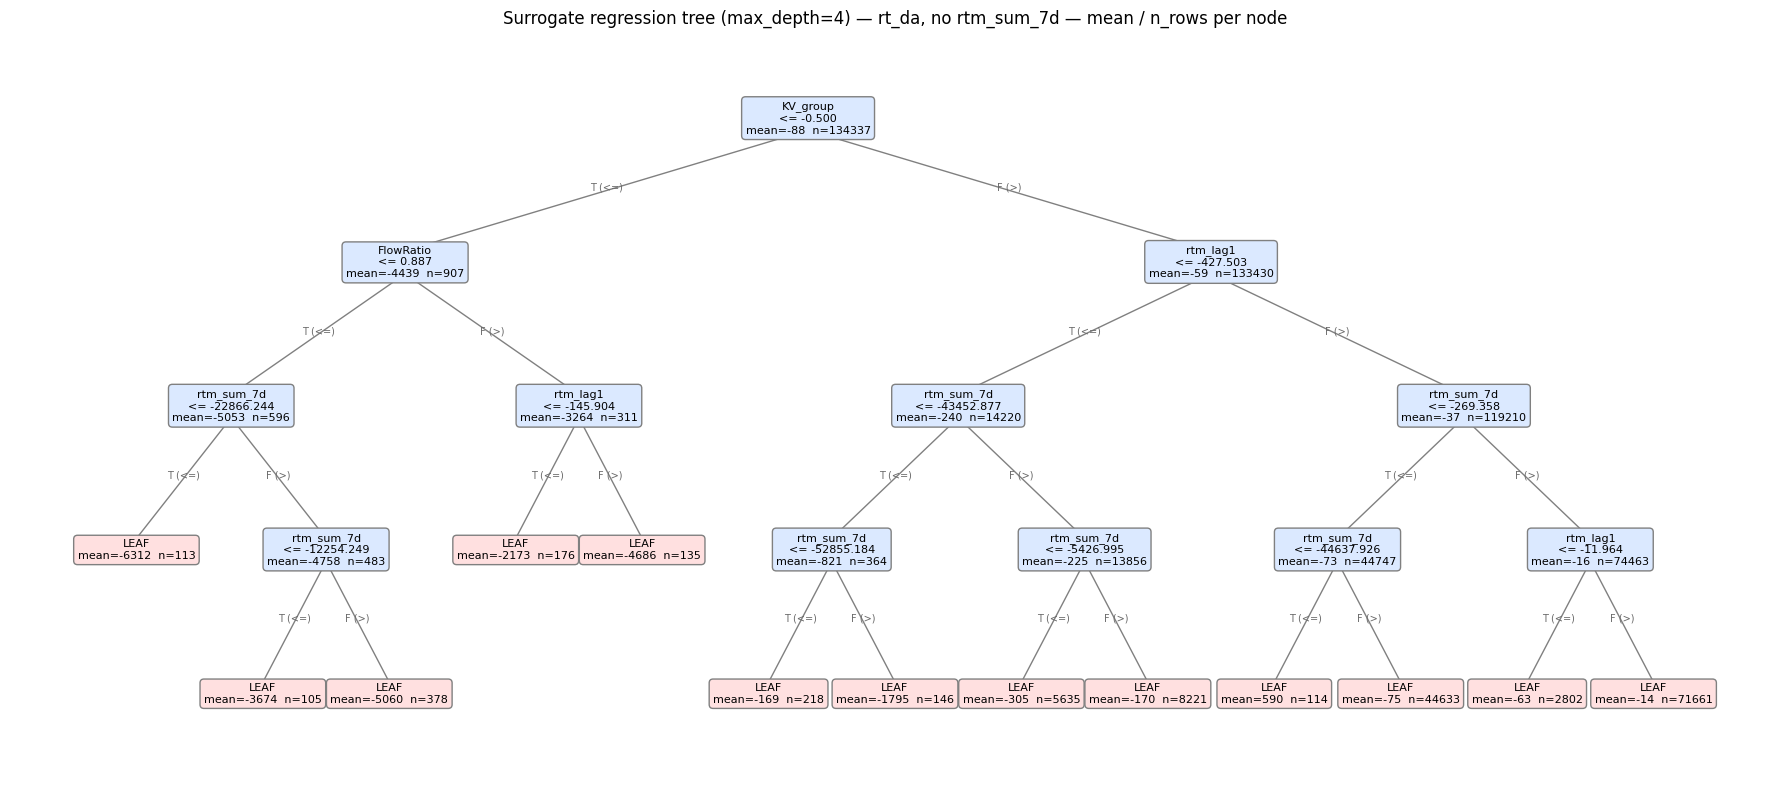

In [101]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, _tree

# ---------- fit the surrogate tree on THIS section's d/y/FEATS (no rtm_sum_7d) ----------
Xn = d[FEATS + CATS].copy()
for c in CATS: Xn[c] = Xn[c].astype('category').cat.codes
Xn = Xn.fillna(Xn.median())
feat = list(Xn.columns)

surr = DecisionTreeRegressor(max_depth=4, min_samples_leaf=100, random_state=0).fit(Xn, y)
t = surr.tree_
node_mean = t.value[:, 0, 0]
node_n = t.n_node_samples

# ---------- visualize the surrogate tree as an actual tree diagram ----------
pos_xy, _xctr = {}, [0]
def _layout(nd, depth):
    if t.feature[nd] == _tree.TREE_UNDEFINED:
        x = _xctr[0]; _xctr[0] += 1
        pos_xy[nd] = (x, -depth)
        return x
    lx = _layout(t.children_left[nd], depth + 1)
    rx = _layout(t.children_right[nd], depth + 1)
    x = (lx + rx) / 2
    pos_xy[nd] = (x, -depth)
    return x
_layout(0, 0)

fig, ax = plt.subplots(figsize=(18, 8))
for nd in range(t.node_count):
    x, y_ = pos_xy[nd]
    is_leaf = t.feature[nd] == _tree.TREE_UNDEFINED
    lab = 'LEAF' if is_leaf else f'{feat[t.feature[nd]]}\n<= {t.threshold[nd]:.3f}'
    box_txt = f'{lab}\nmean={node_mean[nd]:.0f}  n={int(node_n[nd])}'
    color = '#ffe0e0' if is_leaf else '#dbe9ff'
    ax.text(x, y_, box_txt, ha='center', va='center', fontsize=8, zorder=2,
            bbox=dict(boxstyle='round,pad=0.35', fc=color, ec='gray'))
    if not is_leaf:
        for child, edge_lab in ((t.children_left[nd], 'T (<=)'), (t.children_right[nd], 'F (>)')):
            cx, cy = pos_xy[child]
            ax.plot([x, cx], [y_ - 0.08, cy + 0.08], color='gray', lw=1, zorder=1)
            ax.text((x + cx) / 2, (y_ + cy) / 2, edge_lab, fontsize=7, color='dimgray', ha='center')

xs = [p[0] for p in pos_xy.values()]; ys = [p[1] for p in pos_xy.values()]
ax.set_xlim(min(xs) - 1, max(xs) + 1); ax.set_ylim(min(ys) - 0.6, max(ys) + 0.6)
ax.axis('off')
ax.set_title('Surrogate regression tree (max_depth=4) — rt_da, no rtm_sum_7d — mean / n_rows per node')
plt.tight_layout()
plt.show()


# Setting quantile to split the variables to see the rate of capturing. 

In [120]:
# quantiles on negative short_profit at TAIL-WEIGHTED breakpoints (1%,5%,10%,30%,...)
#   bins 1..10: p0-1, p1-5, p5-10, p10-30, p30-50, p50-70, p70-90, p90-95, p95-99, p99-100
#   quantile 1 = worst 1% (most negative short loss)
train_df_filter['bad_shortprofit'] = (train_df_filter['short_profit'] < -20000).astype(int)
train_df_filter['bad_shortprofit'].sum()

np.int64(214)

In [116]:
d = train_df_filter.dropna(subset=['rt_da', 'FlowRatio']).copy()
WORST = {1,2} 
# 10 equal-count FlowRatio buckets
d['FlowRatio_q'] = pd.qcut(d['FlowRatio'], q=10, duplicates='drop')

bucket = (d.groupby('FlowRatio_q', observed=True)
            .agg(n            = ('rt_da', 'size'),
                 flowratio_lo = ('FlowRatio', 'min'),
                 flowratio_hi = ('FlowRatio', 'max'),
                 rt_da_mean   = ('rt_da', 'mean'),
                 rt_da_median = ('rt_da', 'median'),
                 rt_da_p5     = ('rt_da', lambda s: s.quantile(0.05)),
                 bad_rtda = ('bad_rtda','sum'),
                    short_p1 = ('bad_shortprofit','sum')
                 ).round(2).reset_index())
bucket['ratio'] = bucket['bad_rtda']/bucket['n']
display(bucket)


,FlowRatio_q,n,flowratio_lo,flowratio_hi,rt_da_mean,rt_da_median,rt_da_p5,bad_rtda,short_p1,ratio
0,"(-0.001, 0.284]",11459,0.00,0.28,-72.26,0.0,-395.91,93,4,0.008116
1,"(0.284, 0.419]",11458,0.28,0.42,-65.85,0.0,-325.01,84,2,0.007331
2,"(0.419, 0.519]",11458,0.42,0.52,-44.88,0.0,-201.19,74,7,0.006458
3,"(0.519, 0.602]",11458,0.52,0.60,-58.56,0.0,-304.67,91,4,0.007942
4,"(0.602, 0.682]",11458,0.60,0.68,-61.89,0.0,-318.57,119,10,0.010386
5,"(0.682, 0.761]",11458,0.68,0.76,-57.64,0.0,-441.08,135,11,0.011782
6,"(0.761, 0.843]",11458,0.76,0.84,-65.07,0.0,-643.69,149,12,0.013004
7,"(0.843, 0.935]",11458,0.84,0.93,-77.19,0.0,-1006.46,218,14,0.019026
8,"(0.935, 1.0]",18964,0.93,1.00,-56.39,0.0,-1619.17,496,85,0.026155
9,"(1.0, 1.733]",3952,1.00,1.73,-117.73,0.0,-3752.95,261,30,0.066043


In [119]:
d = train_df_filter.dropna(subset=['rt_da', 'rtda_hr_abssum_7d']).copy()

WORST = {1,2}   # worst short_profit band (bottom 1% of negative short_profit); add 'p1-p5' to widen

# 10 equal-count rtda_hr_abssum_7d buckets
d['rtda_hr_abssum_7d_q'] = pd.qcut(d['rtda_hr_abssum_7d'], q=10, duplicates='drop')

bucket = (d.groupby('rtda_hr_abssum_7d_q', observed=True)
            .agg(n            = ('rt_da', 'size'),
                 rt_da_mean   = ('rt_da', 'mean'),
                 rt_da_median = ('rt_da', 'median'),
                 rt_da_p5     = ('rt_da', lambda s: s.quantile(0.05)),
                 bad_rtda     = ('bad_rtda', 'sum'),
                  short_p1 = ('bad_shortprofit','sum')).round(2).reset_index())
bucket['ratio']      = bucket['bad_rtda'] / bucket['n']
bucket['p0p1_share'] = (bucket['short_p1'] / bucket['n']).round(3)
display(bucket)


,rtda_hr_abssum_7d_q,n,rt_da_mean,rt_da_median,rt_da_p5,bad_rtda,short_p1,ratio,p0p1_share
0,"(-0.001, 102.831]",53727,-27.06,0.0,-7.09,178,10,0.003313,0.000
1,"(102.831, 382.823]",13437,-45.65,0.0,-327.48,66,9,0.004912,0.001
2,"(382.823, 832.488]",13428,-55.71,0.0,-526.23,90,8,0.006702,0.001
3,"(832.488, 1604.721]",13430,-71.70,0.0,-707.18,129,15,0.009605,0.001
4,"(1604.721, 3063.383]",13432,-84.94,0.0,-1070.72,190,16,0.014145,0.001
5,"(3063.383, 6674.134]",13432,-128.41,0.0,-1772.14,362,44,0.026951,0.003
6,"(6674.134, 113284.733]",13432,-163.20,0.0,-3992.62,926,112,0.068940,0.008


In [112]:
train_df_filter_temp = train_df_filter.query('rtda_hr_abssum_7d>6000')
# 10 equal-count FlowRatio buckets
train_df_filter_temp['FlowRatio_q'] = pd.qcut(train_df_filter_temp['FlowRatio'], q=10, duplicates='drop')

bucket = (train_df_filter_temp.groupby('FlowRatio_q', observed=True)
            .agg(n            = ('rt_da', 'size'),
                 flowratio_lo = ('FlowRatio', 'min'),
                 flowratio_hi = ('FlowRatio', 'max'),
                 rt_da_mean   = ('rt_da', 'mean'),
                 rt_da_median = ('rt_da', 'median'),
                 rt_da_p5     = ('rt_da', lambda s: s.quantile(0.05)),
                 bad_rtda = ('bad_rtda','sum'),
                 short_p1 = ('short_profit_q', lambda s: (s == 1).sum()),
                 short_p5 = ('short_profit_q', lambda s: (s == 5).sum()),
                 short_p0p1   = ('short_profit_q', lambda s: s.isin(WORST).sum()))).round(2)
display(bucket)

,n,flowratio_lo,flowratio_hi,rt_da_mean,rt_da_median,rt_da_p5,bad_rtda,short_p1,short_p5,short_p0p1
FlowRatio_q,,,,,,,,,,
"(-1e-05, 0.4024]",1357,0.00,0.40,-357.50,0.00,-3396.76,81,17,17,35
"(0.4024, 0.56058]",1357,0.40,0.56,-178.42,0.00,-2404.85,59,25,16,47
"(0.56058, 0.66509]",1357,0.56,0.67,-247.69,0.00,-3279.66,74,36,25,59
"(0.66509, 0.75046]",1357,0.67,0.75,-201.75,0.00,-2778.87,65,32,16,75
"(0.75046, 0.83283]",1357,0.75,0.83,-220.85,0.00,-3315.89,72,41,27,86
"(0.83283, 0.9138]",1357,0.83,0.91,-104.54,0.00,-3514.97,81,48,25,98
"(0.9138, 0.99458]",1357,0.91,0.99,-116.17,0.00,-3716.97,85,60,26,111
"(0.99458, 1.0]",2705,0.99,1.00,-4.36,62.47,-4147.97,209,204,76,371
"(1.0, 1.00001]",9,1.00,1.00,-139.05,-13.89,-1639.93,0,0,1,1


In [67]:
train_df_filter_temp = train_df_filter.query('rtm_sum_7d>-5500 and FlowRatio < 1')
train_df_filter_temp.query('bad_rtda ==1 and short_profit<-400000').head()

,constraint_family_num,dt,profit,profit_congestion,long_profit,short_profit,FlowRatio,ShadowPrice_min,ShadowPrice_sum,MinFlowLimit,...,dfax_min,dfax_mean,dfax_std,dfax_absmean,dfax_pos_cnt,dfax_neg_cnt,dfax_strong,dfax_range,dfax_absmax,rt_da_smaller_500
73451,784508,2022-04-06,80177.76570,57276.98395,128017.453586,-859276.505419,0.375290,0.0,0.0,-222.0,...,-0.1267,-0.014254,0.036843,0.034046,59.0,55.0,0.210526,0.2042,0.1267,1
84693,4805,2022-05-02,17170.41196,-5701.07475,674407.787205,-495087.225568,0.975813,0.0,0.0,-1050.0,...,-0.4548,-0.015932,0.094934,0.066758,66.0,66.0,0.469697,0.5571,0.4548,1
86850,1030,2022-05-07,146416.44381,165568.68486,182000.405162,-526471.985485,0.757362,0.0,0.0,-504.0,...,-0.0641,-0.011644,0.025033,0.022956,26.0,42.0,0.058824,0.0819,0.0641,1
105686,807444,2022-06-19,-23427.29589,-9996.35888,322242.996139,-411419.675690,0.530439,0.0,0.0,-413.0,...,-0.1527,-0.054767,0.033941,0.055597,1.0,32.0,0.424242,0.1664,0.1527,1
108691,167423,2022-06-26,-20561.56614,-22856.83603,133979.583212,-539600.792206,0.941780,0.0,0.0,-125.0,...,-0.0690,0.135556,0.270829,0.171911,5.0,4.0,0.555556,0.6703,0.6013,1


In [45]:
train_df_filter_temp = train_df_filter.query('rtm_sum_7d>-5500 and FlowRatio < 1')
# 10 equal-count FlowRatio buckets
train_df_filter_temp['rt_nz_cnt_1y_q'] = pd.qcut(train_df_filter_temp['rt_nz_cnt_1y'], q=10, duplicates='drop')

bucket = (train_df_filter_temp.groupby('rt_nz_cnt_1y_q', observed=True)
            .agg(n            = ('rt_da', 'size'),
                 flowratio_lo = ('FlowRatio', 'min'),
                 flowratio_hi = ('FlowRatio', 'max'),
                 rt_da_mean   = ('rt_da', 'mean'),
                 rt_da_median = ('rt_da', 'median'),
                 rt_da_p5     = ('rt_da', lambda s: s.quantile(0.05)),
                 bad_rtda = ('bad_rtda','sum'))
            .round(2))
display(bucket)

,n,flowratio_lo,flowratio_hi,rt_da_mean,rt_da_median,rt_da_p5,bad_rtda
rt_nz_cnt_1y_q,,,,,,,
"(0.999, 4.0]",9576,0.0,1.0,-27.69,0.0,0.00,59
"(4.0, 8.0]",8728,0.0,1.0,-18.56,0.0,0.00,46
"(8.0, 14.0]",9415,0.0,1.0,-30.38,0.0,-81.61,67
"(14.0, 21.0]",8963,0.0,1.0,-44.94,0.0,-178.29,76
"(21.0, 30.0]",9745,0.0,1.0,-57.06,0.0,-275.76,87
"(30.0, 39.0]",8725,0.0,1.0,-51.64,0.0,-332.67,81
"(39.0, 53.0]",9021,0.0,1.0,-65.79,0.0,-442.15,87
"(53.0, 69.0]",9147,0.0,1.0,-73.28,0.0,-470.29,91
"(69.0, 102.0]",8700,0.0,1.0,-66.56,0.0,-644.88,91


In [46]:
train_df_filter_temp = train_df_filter.query('rtm_sum_7d>-5500 and FlowRatio < 1')
# 10 equal-count FlowRatio buckets
train_df_filter_temp['FlowRatio_q'] = pd.qcut(train_df_filter_temp['FlowRatio'], q=10, duplicates='drop')

bucket = (train_df_filter_temp.groupby('FlowRatio_q', observed=True)
            .agg(n            = ('rt_da', 'size'),
                 flowratio_lo = ('FlowRatio', 'min'),
                 flowratio_hi = ('FlowRatio', 'max'),
                 rt_da_mean   = ('rt_da', 'mean'),
                 rt_da_median = ('rt_da', 'median'),
                 rt_da_p5     = ('rt_da', lambda s: s.quantile(0.05)),
                 bad_rtda = ('bad_rtda','sum'))
            .round(2))
display(bucket)

,n,flowratio_lo,flowratio_hi,rt_da_mean,rt_da_median,rt_da_p5,bad_rtda
FlowRatio_q,,,,,,,
"(-0.001, 0.257]",9107,0.00,0.26,-56.41,0.0,-247.70,54
"(0.257, 0.38]",9107,0.26,0.38,-49.34,0.0,-256.21,48
"(0.38, 0.475]",9106,0.38,0.48,-39.82,0.0,-113.66,36
"(0.475, 0.551]",9107,0.48,0.55,-49.92,0.0,-143.62,60
"(0.551, 0.62]",9107,0.55,0.62,-42.65,0.0,-127.56,46
"(0.62, 0.69]",9106,0.62,0.69,-55.35,0.0,-180.42,81
"(0.69, 0.759]",9107,0.69,0.76,-42.07,0.0,-300.21,79
"(0.759, 0.831]",9106,0.76,0.83,-52.01,0.0,-419.77,95
"(0.831, 0.911]",9107,0.83,0.91,-78.45,0.0,-718.66,130


In [54]:
train_df_filter[train_df_filter['KV_group'].isna()].monitored_name.unique()

array([None, 'xfmrmonona-monona', 'xfmrduncan-duncan',
       'xfmrfremont-fremont', 'xfmrsub975-sub975', 'lndovrt-turcrk2',
       'lnarnold2-ransom1', 'xfmrbremerco-bremerco', 'lnsnakeck-aliance',
       'lnwemp-vaug', 'lnelliottw-enderlnw', 'lnleeds2-penn_tap',
       'lnvinetap3-nhays', 'lntech-midj', 'lnokeene1-dovers1',
       'xfmrfrankln5-frankln5', 'lnsp-ersk3-carlisle',
       'ln70_bluf-sub1214', 'lns3-granitf', 'lnwilistn-fairviwp',
       'lnftrandl-spence1', 'lnbrookngs-aurorawa', 'lnbrule-b_sprgs',
       'lnplesntlk-leeds2', 'lnconway-kirby_su', 'xfmrkell-kell',
       'lnseguin-hoxie_1', 'lnseward3-st-john', 'lnforman-formnwa',
       'xfmr70_bluf-70_bluf', 'lnrsh_sprg-ommarlo4', 'lnnorfk_n-norfolk',
       'xfmrforman-forman', 'lnanta_tp-anita', 'lnrussett-sbrown',
       'lnweav-tallgras', 'lnogalala-grantnb', 'xfmrotp_asto-otp_asto',
       'lnmanfl7-clec_pel', 'lnmaud_tap-earlsbrh', 'lnstonewsw-tupelo2',
       'lnsprin-dripping', 'lncolhydro-colmbsse', 'lnn_plt1-s

In [53]:
train_df_filter_temp =  train_df_filter[train_df_filter['KV_group'].isna()]

# 10 equal-count FlowRatio buckets
train_df_filter_temp['dam_sum_7d_q'] = pd.qcut(train_df_filter_temp['dam_sum_7d'], q=10, duplicates='drop')

bucket = (train_df_filter_temp.groupby('dam_sum_7d_q', observed=True)
            .agg(n            = ('rt_da', 'size'),
                 flowratio_lo = ('FlowRatio', 'min'),
                 flowratio_hi = ('FlowRatio', 'max'),
                 rt_da_mean   = ('rt_da', 'mean'),
                 rt_da_median = ('rt_da', 'median'),
                 rt_da_p5     = ('rt_da', lambda s: s.quantile(0.05)),
                 bad_rtda = ('bad_rtda','sum'))
            .round(2))
display(bucket)

,n,flowratio_lo,flowratio_hi,rt_da_mean,rt_da_median,rt_da_p5,bad_rtda
dam_sum_7d_q,,,,,,,
"(-91089.729, -18450.374]",91,0.37,1.22,-1992.74,-1786.57,-12252.29,34
"(-18450.374, -11171.396]",91,0.00,1.17,-1925.89,-2065.10,-9608.43,39
"(-11171.396, -6795.251]",90,0.00,1.11,-3763.71,-3494.59,-12083.60,49
"(-6795.251, -3529.561]",91,0.00,1.11,-2772.05,-2746.74,-9816.14,45
"(-3529.561, -1162.61]",91,0.00,1.14,-4116.19,-3629.02,-10766.08,57
"(-1162.61, -98.941]",90,0.14,1.20,-4241.94,-3873.19,-11495.50,64
"(-98.941, 0.0]",363,0.00,1.58,-6398.34,-5104.70,-14570.31,340


In [42]:
d = train_df_filter.dropna(subset=['rt_da', 'rt_nz_cnt_1y']).copy()

# 10 equal-count FlowRatio buckets
d['rt_nz_cnt_1y_q'] = pd.qcut(d['rt_nz_cnt_1y'], q=10, duplicates='drop')

bucket = (d.groupby('rt_nz_cnt_1y_q', observed=True)
            .agg(n            = ('rt_da', 'size'),
                 flowratio_lo = ('FlowRatio', 'min'),
                 flowratio_hi = ('FlowRatio', 'max'),
                 rt_da_mean   = ('rt_da', 'mean'),
                 rt_da_median = ('rt_da', 'median'),
                 rt_da_p5     = ('rt_da', lambda s: s.quantile(0.05)),
                 bad_rtda = ('bad_rtda','sum'))
            .round(2))
display(bucket)


,n,flowratio_lo,flowratio_hi,rt_da_mean,rt_da_median,rt_da_p5,bad_rtda
rt_nz_cnt_1y_q,,,,,,,
"(0.999, 4.0]",15503,0.0,1.64,-54.19,0.0,-17.54,142
"(4.0, 8.0]",12742,0.0,1.47,-46.51,0.0,-105.06,122
"(8.0, 14.0]",13132,0.0,1.64,-59.34,0.0,-340.49,181
"(14.0, 22.0]",13475,0.0,1.59,-73.27,0.0,-428.57,182
"(22.0, 31.0]",12551,0.0,1.63,-85.07,0.0,-639.09,193
"(31.0, 42.0]",13801,0.0,1.73,-73.06,0.0,-706.45,235
"(42.0, 58.0]",13544,0.0,1.46,-85.96,0.0,-957.21,266
"(58.0, 78.0]",13040,0.0,1.67,-99.70,0.0,-1001.35,251
"(78.0, 118.0]",13170,0.0,1.64,-119.19,0.0,-1371.45,296


# Run on the sample rtm_sum_7d>-5500 and flowratio <1 

In [43]:
import numpy as np, pandas as pd, lightgbm as lgb
from sklearn.tree import DecisionTreeRegressor, _tree
pd.set_option('display.max_colwidth', None); pd.set_option('display.width', None)

# rows NOT captured by the top cut
d = train_df_filter.query('rtm_sum_7d > -5500 and FlowRatio <1').dropna(subset=['rt_da']).copy()
y = d['rt_da'].astype(float)

# drop rtm_sum_7d itself (near-constant / already used) + long/short profit handled upstream
FEATS = [f for f in globals().get('compact', features) if f != 'rtm_sum_7d']
Xn = d[FEATS + CATS].copy()
for c in CATS: Xn[c] = Xn[c].astype('category').cat.codes
Xn = Xn.fillna(Xn.median())
feat = list(Xn.columns)
print(f'rows={len(d)}  rt_da mean={y.mean():.1f}  median={y.median():.1f}  '
      f'p1={y.quantile(.01):.1f}  p5={y.quantile(.05):.1f}')

# ---------- feature importance (tau=0.05 quantile model) ----------
X = d[FEATS + CATS].copy()
for c in CATS: X[c] = X[c].astype('category')
m = lgb.LGBMRegressor(objective='quantile', alpha=0.05, n_estimators=400, learning_rate=0.05,
                      num_leaves=31, min_child_samples=50, subsample=0.8, colsample_bytree=0.8,
                      random_state=0, n_jobs=-1, verbose=-1).fit(X, y, categorical_feature=CATS)
imp = pd.Series(m.booster_.feature_importance('gain'), index=X.columns)
imp = (imp / imp.sum()).sort_values(ascending=False)
print('\n=== feature importance (gain) — tau=0.05, subset rtm_sum_7d > -9622 ===')
display(imp.head(15).round(4).to_frame('gain'))

# ---------- surrogate tree: mean rt_da / n_rows at each node ----------
surr = DecisionTreeRegressor(max_depth=4, min_samples_leaf=100, random_state=0).fit(Xn, y)
t = surr.tree_; node_mean = t.value[:, 0, 0]; node_n = t.n_node_samples
print('\n=== tree splits: mean rt_da / n_rows at EACH node ===')
def show(nd=0, dep=0, br=''):
    lab = 'LEAF' if t.feature[nd]==_tree.TREE_UNDEFINED else f'[{feat[t.feature[nd]]} <= {t.threshold[nd]:.3f}]'
    print(f'  {"  "*dep}{br}{lab}  mean={node_mean[nd]:>10.1f}  n_rows={int(node_n[nd]):>6}')
    if t.feature[nd] != _tree.TREE_UNDEFINED:
        show(t.children_left[nd], dep+1, 'T> '); show(t.children_right[nd], dep+1, 'F> ')
show()

# ---------- leaf rules ranked by worst mean rt_da ----------
rules = {}
def rec(n, c):
    if t.feature[n]==_tree.TREE_UNDEFINED: rules[n]=' AND '.join(c) or '(all)'
    else:
        f, th = feat[t.feature[n]], t.threshold[n]
        rec(t.children_left[n], c+[f'{f} <= {th:.3f}']); rec(t.children_right[n], c+[f'{f} > {th:.3f}'])
rec(0, [])
leaves = [i for i in range(t.node_count) if t.feature[i]==_tree.TREE_UNDEFINED]
tab = (pd.DataFrame([{'mean':round(node_mean[i],1),'n_rows':int(node_n[i]),'rule':rules[i]} for i in leaves])
       .sort_values('mean').reset_index(drop=True))
tab['cum_rows'] = (tab['n_rows'].cumsum()/len(y)*100).round(1)
print('\n=== leaf rules ranked by worst mean rt_da ===')
for _, r in tab.iterrows():
    print(f"mean={r['mean']:>10.1f}  n_rows={int(r['n_rows']):>6}  cum_rows={r['cum_rows']:>5}%")
    print(f"     RULE: {r['rule']}")


rows=91067  rt_da mean=-55.5  median=0.0  p1=-2712.5  p5=-339.4

=== feature importance (gain) — tau=0.05, subset rtm_sum_7d > -9622 ===


,gain
rt_nz_cnt_1y,0.0789
rtda_avg_7d,0.0781
FlowRatio,0.0675
dfax_absmax,0.0643
rt_spike_3y,0.0393
dam_sum_7d,0.0391
rtda_sum_1y,0.0380
wind_forecast,0.0379
rtda_avg_1m,0.0378
rtda_std_1y,0.0354



=== tree splits: mean rt_da / n_rows at EACH node ===
  [KV_group <= -0.500]  mean=     -55.5  n_rows= 91067
    T> [dam_sum_7d <= -46.212]  mean=   -4647.0  n_rows=   264
      T> LEAF  mean=   -3843.0  n_rows=   146
      F> LEAF  mean=   -5641.8  n_rows=   118
    F> [rtda_avg_7d <= -155.019]  mean=     -42.1  n_rows= 90803
      T> [rt_spike_3y <= -3629.842]  mean=    -168.2  n_rows= 10932
        T> LEAF  mean=   -1438.9  n_rows=   127
        F> [rtda_avg_1m <= -310.483]  mean=    -153.3  n_rows= 10805
          T> LEAF  mean=    -401.5  n_rows=  1585
          F> LEAF  mean=    -110.6  n_rows=  9220
      F> [rtda_sum_1y <= -193.117]  mean=     -24.9  n_rows= 79871
        T> [rtda_sum_1y <= -41042.715]  mean=     -44.6  n_rows= 58118
          T> LEAF  mean=    -114.1  n_rows=  8388
          F> LEAF  mean=     -32.9  n_rows= 49730
        F> [rtda_avg_7d <= 698.950]  mean=      28.0  n_rows= 21753
          T> LEAF  mean=      17.6  n_rows= 20923
          F> LEAF  mean=     

# Profit Congestion model 


In [106]:
import numpy as np, pandas as pd, lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor, _tree
from sklearn.metrics import r2_score, mean_absolute_error
pd.set_option('display.max_colwidth', None); pd.set_option('display.width', None)

d = train_df_filter.query('profit_congestion < 0').dropna(subset=['profit_congestion']).copy()
y = d['profit_congestion'].astype(float)
FEATS = globals().get('compact', features) 
Xc = d[FEATS + CATS].copy()                              # LightGBM: native categoricals + NaN
for c in CATS: Xc[c] = Xc[c].astype('category')
Xn = d[FEATS + CATS].copy()                               # sklearn: numeric, no NaN
for c in CATS: Xn[c] = Xn[c].astype('category').cat.codes
Xn = Xn.fillna(Xn.median())
feat = list(Xc.columns); N = len(y)
print(f'rows={N}  profit_congestion mean={y.mean():.1f}  median={y.median():.1f}  p5={y.quantile(.05):.1f}')

# ---------- 1) two models + feature importance ----------
lgbm = lgb.LGBMRegressor(n_estimators=400, learning_rate=0.05, num_leaves=31, min_child_samples=50,
                         subsample=0.8, colsample_bytree=0.8,
                         random_state=0, n_jobs=-1, verbose=-1).fit(Xc, y, categorical_feature=CATS)
rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=100,
                           random_state=0, n_jobs=-1).fit(Xn, y)
li = pd.Series(lgbm.booster_.feature_importance('gain'), index=feat); li /= li.sum()
ri = pd.Series(rf.feature_importances_, index=feat)
imp = pd.concat([li.rename('lgbm_gain'), ri.rename('rf_impurity')], axis=1)
imp['avg_rank'] = imp.rank(ascending=False).mean(axis=1)
print('\n=== feature importance: LGBM vs RandomForest (top 15) ===')
display(imp.sort_values('avg_rank').head(15).round(4))

print('\n=== in-sample fit ===')
for name, m, X in (('LightGBM', lgbm, Xc), ('RandomForest', rf, Xn)):
    p = m.predict(X)
    print(f'  {name:<13} R2={r2_score(y, p):.3f}  MAE={mean_absolute_error(y, p):.1f}')

# ---------- 2) readable tree: split + node stats at EACH node ----------
surr = DecisionTreeRegressor(max_depth=4, min_samples_leaf=100, random_state=0).fit(Xn, y)
t = surr.tree_
node_mean = t.value[:, 0, 0]
node_n = t.n_node_samples
print('\n=== tree splits: mean profit_congestion / n_rows at EACH node ===')
def show(nd=0, dep=0, br=''):
    lab = 'LEAF' if t.feature[nd]==_tree.TREE_UNDEFINED else f'[{feat[t.feature[nd]]} <= {t.threshold[nd]:.3f}]'
    print(f'  {"  "*dep}{br}{lab}  mean={node_mean[nd]:>10.1f}  n_rows={int(node_n[nd]):>5}')
    if t.feature[nd] != _tree.TREE_UNDEFINED:
        show(t.children_left[nd], dep+1, 'T> ')   # <= thr
        show(t.children_right[nd], dep+1, 'F> ')  # >  thr
show()

# leaf rules ranked by worst (most negative) mean profit_congestion
rules = {}
def rec(n, c):
    if t.feature[n]==_tree.TREE_UNDEFINED: rules[n]=' AND '.join(c) or '(all)'
    else:
        f, th = feat[t.feature[n]], t.threshold[n]
        rec(t.children_left[n], c+[f'{f} <= {th:.3f}']); rec(t.children_right[n], c+[f'{f} > {th:.3f}'])
rec(0, [])
leaves = [i for i in range(t.node_count) if t.feature[i]==_tree.TREE_UNDEFINED]
tab = (pd.DataFrame([{'mean':round(node_mean[i],1),'n_rows':int(node_n[i]),
                      'rule':rules[i]} for i in leaves]).sort_values('mean').reset_index(drop=True))
tab['cum_rows'] = (tab['n_rows'].cumsum()/N*100).round(1)
print('\n=== leaf rules ranked by worst mean profit_congestion ===')
for _, r in tab.iterrows():
    print(f"mean={r['mean']:>10.1f}  n_rows={int(r['n_rows']):>5}  cum_rows={r['cum_rows']:>5}%")
    print(f"     RULE: {r['rule']}")


rows=30950  profit_congestion mean=-9557.0  median=-2572.9  p5=-36770.9

=== feature importance: LGBM vs RandomForest (top 15) ===


,lgbm_gain,rf_impurity,avg_rank
wind_forecast,0.2161,0.3398,1.5
load_forecast,0.3019,0.1884,2.0
genoutage_forecast,0.1558,0.0810,3.5
dfax_neg_cnt,0.0830,0.2515,3.5
ice_price_forecast,0.1092,0.0612,4.5
dfax_pos_cnt,0.0292,0.0522,6.0
MaxFlowLimit,0.0087,0.0026,7.0
dfax_absmax,0.0068,0.0013,10.5
rt_spike_3y,0.0057,0.0020,10.5
FlowRatio,0.0074,0.0012,10.5



=== in-sample fit ===
  LightGBM      R2=0.768  MAE=5778.2
  RandomForest  R2=0.240  MAE=8700.2

=== tree splits: mean profit_congestion / n_rows at EACH node ===
  [dfax_neg_cnt <= 26.500]  mean=   -9557.0  n_rows=30950
    T> [dfax_pos_cnt <= 9.500]  mean=   -6493.6  n_rows=23308
      T> [dfax_neg_cnt <= 5.500]  mean=   -4587.0  n_rows=15250
        T> [dfax_pos_cnt <= 5.500]  mean=   -2864.8  n_rows= 7621
          T> LEAF  mean=   -2136.3  n_rows= 5843
          F> LEAF  mean=   -5258.8  n_rows= 1778
        F> [wind_forecast <= 14243.030]  mean=   -6307.4  n_rows= 7629
          T> LEAF  mean=   -4961.1  n_rows= 4326
          F> LEAF  mean=   -8070.6  n_rows= 3303
      F> [wind_forecast <= 14160.580]  mean=  -10101.8  n_rows= 8058
        T> [ice_price_forecast <= 32.155]  mean=   -7943.9  n_rows= 4609
          T> LEAF  mean=  -10475.7  n_rows= 1775
          F> LEAF  mean=   -6358.1  n_rows= 2834
        F> [dfax_neg_cnt <= 9.500]  mean=  -12985.4  n_rows= 3449
          T> 

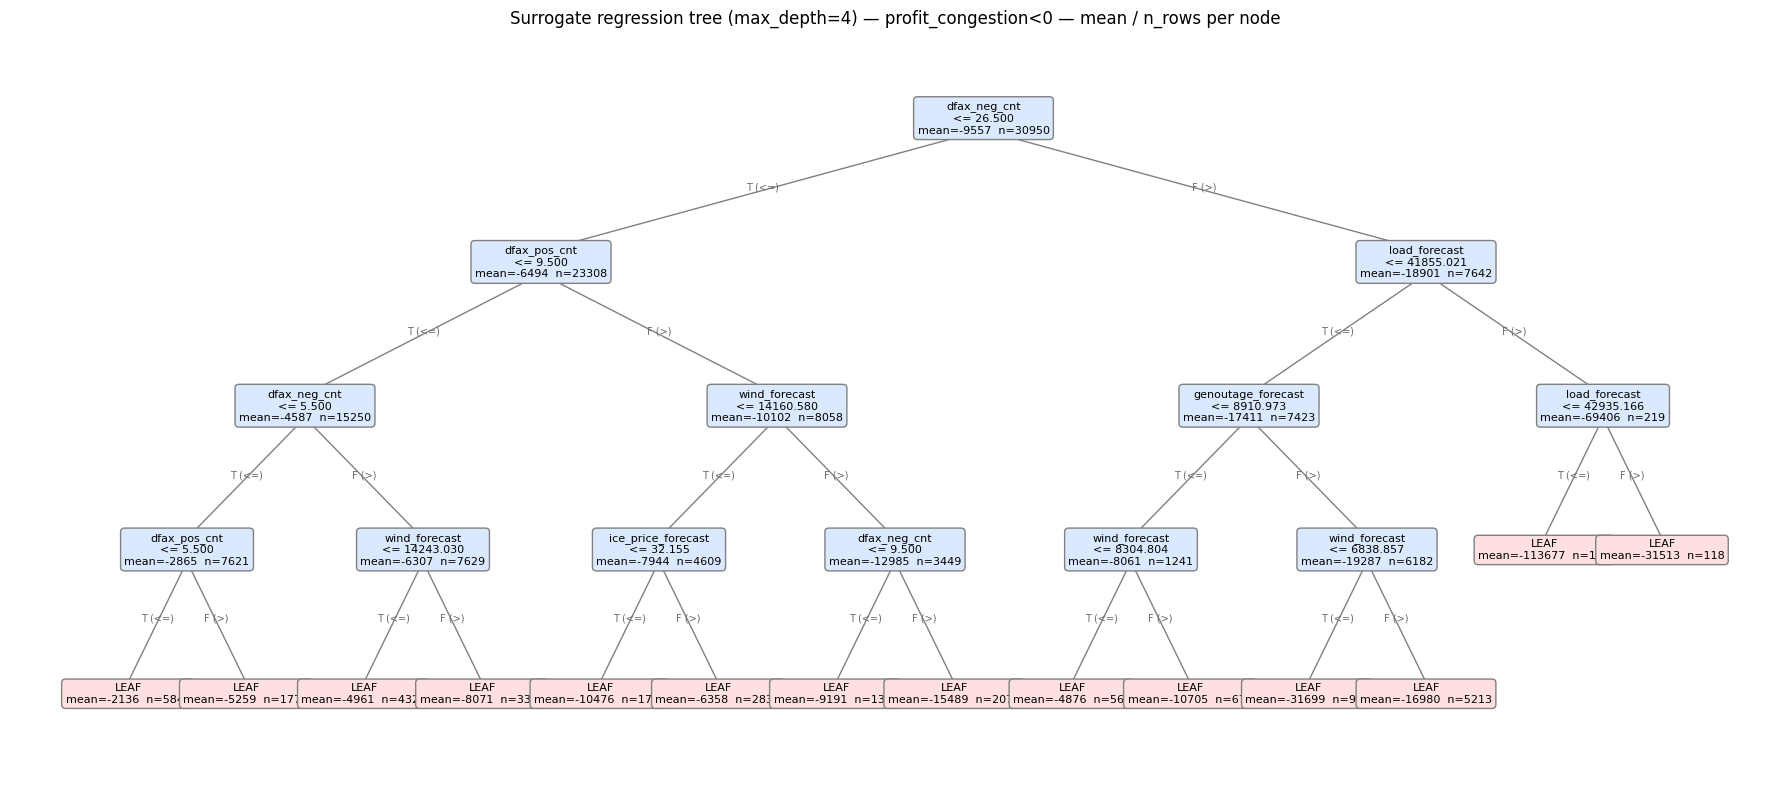

In [107]:
import matplotlib.pyplot as plt

# ---------- visualize the surrogate tree as an actual tree diagram ----------
pos_xy, _xctr = {}, [0]
def _layout(nd, depth):
    if t.feature[nd] == _tree.TREE_UNDEFINED:
        x = _xctr[0]; _xctr[0] += 1
        pos_xy[nd] = (x, -depth)
        return x
    lx = _layout(t.children_left[nd], depth + 1)
    rx = _layout(t.children_right[nd], depth + 1)
    x = (lx + rx) / 2
    pos_xy[nd] = (x, -depth)
    return x
_layout(0, 0)

fig, ax = plt.subplots(figsize=(18, 8))
for nd in range(t.node_count):
    x, y_ = pos_xy[nd]
    is_leaf = t.feature[nd] == _tree.TREE_UNDEFINED
    lab = 'LEAF' if is_leaf else f'{feat[t.feature[nd]]}\n<= {t.threshold[nd]:.3f}'
    box_txt = f'{lab}\nmean={node_mean[nd]:.0f}  n={int(node_n[nd])}'
    color = '#ffe0e0' if is_leaf else '#dbe9ff'
    ax.text(x, y_, box_txt, ha='center', va='center', fontsize=8, zorder=2,
            bbox=dict(boxstyle='round,pad=0.35', fc=color, ec='gray'))
    if not is_leaf:
        for child, edge_lab in ((t.children_left[nd], 'T (<=)'), (t.children_right[nd], 'F (>)')):
            cx, cy = pos_xy[child]
            ax.plot([x, cx], [y_ - 0.08, cy + 0.08], color='gray', lw=1, zorder=1)
            ax.text((x + cx) / 2, (y_ + cy) / 2, edge_lab, fontsize=7, color='dimgray', ha='center')

xs = [p[0] for p in pos_xy.values()]; ys = [p[1] for p in pos_xy.values()]
ax.set_xlim(min(xs) - 1, max(xs) + 1); ax.set_ylim(min(ys) - 0.6, max(ys) + 0.6)
ax.axis('off')
ax.set_title('Surrogate regression tree (max_depth=4) — profit_congestion<0 — mean / n_rows per node')
plt.tight_layout()
plt.show()


# Rerun without the top variables

In [44]:
import numpy as np, pandas as pd, lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor, _tree
from sklearn.metrics import r2_score, mean_absolute_error
pd.set_option('display.max_colwidth', None); pd.set_option('display.width', None)

d = train_df_filter.query('profit_congestion < 0').dropna(subset=['profit_congestion']).copy()
y = d['profit_congestion'].astype(float)
FEATS = [f for f in globals().get('compact', features) if f not in ('dfax_pos_cnt', 'dfax_neg_cnt', 'load_forecast','wind_forecast','genoutage_forecast','ice_price_forecast')]
Xc = d[FEATS + CATS].copy()                              # LightGBM: native categoricals + NaN
for c in CATS: Xc[c] = Xc[c].astype('category')
Xn = d[FEATS + CATS].copy()                               # sklearn: numeric, no NaN
for c in CATS: Xn[c] = Xn[c].astype('category').cat.codes
Xn = Xn.fillna(Xn.median())
feat = list(Xc.columns); N = len(y)
print(f'rows={N}  profit_congestion mean={y.mean():.1f}  median={y.median():.1f}  p5={y.quantile(.05):.1f}')

# ---------- 1) two models + feature importance ----------
lgbm = lgb.LGBMRegressor(n_estimators=400, learning_rate=0.05, num_leaves=31, min_child_samples=50,
                         subsample=0.8, colsample_bytree=0.8,
                         random_state=0, n_jobs=-1, verbose=-1).fit(Xc, y, categorical_feature=CATS)
rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=100,
                           random_state=0, n_jobs=-1).fit(Xn, y)
li = pd.Series(lgbm.booster_.feature_importance('gain'), index=feat); li /= li.sum()
ri = pd.Series(rf.feature_importances_, index=feat)
imp = pd.concat([li.rename('lgbm_gain'), ri.rename('rf_impurity')], axis=1)
imp['avg_rank'] = imp.rank(ascending=False).mean(axis=1)
print('\n=== feature importance: LGBM vs RandomForest (top 15) ===')
display(imp.sort_values('avg_rank').head(15).round(4))

print('\n=== in-sample fit ===')
for name, m, X in (('LightGBM', lgbm, Xc), ('RandomForest', rf, Xn)):
    p = m.predict(X)
    print(f'  {name:<13} R2={r2_score(y, p):.3f}  MAE={mean_absolute_error(y, p):.1f}')

# ---------- 2) readable tree: split + node stats at EACH node ----------
surr = DecisionTreeRegressor(max_depth=4, min_samples_leaf=100, random_state=0).fit(Xn, y)
t = surr.tree_
node_mean = t.value[:, 0, 0]
node_n = t.n_node_samples
print('\n=== tree splits: mean profit_congestion / n_rows at EACH node ===')
def show(nd=0, dep=0, br=''):
    lab = 'LEAF' if t.feature[nd]==_tree.TREE_UNDEFINED else f'[{feat[t.feature[nd]]} <= {t.threshold[nd]:.3f}]'
    print(f'  {"  "*dep}{br}{lab}  mean={node_mean[nd]:>10.1f}  n_rows={int(node_n[nd]):>5}')
    if t.feature[nd] != _tree.TREE_UNDEFINED:
        show(t.children_left[nd], dep+1, 'T> ')   # <= thr
        show(t.children_right[nd], dep+1, 'F> ')  # >  thr
show()

# leaf rules ranked by worst (most negative) mean profit_congestion
rules = {}
def rec(n, c):
    if t.feature[n]==_tree.TREE_UNDEFINED: rules[n]=' AND '.join(c) or '(all)'
    else:
        f, th = feat[t.feature[n]], t.threshold[n]
        rec(t.children_left[n], c+[f'{f} <= {th:.3f}']); rec(t.children_right[n], c+[f'{f} > {th:.3f}'])
rec(0, [])
leaves = [i for i in range(t.node_count) if t.feature[i]==_tree.TREE_UNDEFINED]
tab = (pd.DataFrame([{'mean':round(node_mean[i],1),'n_rows':int(node_n[i]),
                      'rule':rules[i]} for i in leaves]).sort_values('mean').reset_index(drop=True))
tab['cum_rows'] = (tab['n_rows'].cumsum()/N*100).round(1)
print('\n=== leaf rules ranked by worst mean profit_congestion ===')
for _, r in tab.iterrows():
    print(f"mean={r['mean']:>10.1f}  n_rows={int(r['n_rows']):>5}  cum_rows={r['cum_rows']:>5}%")
    print(f"     RULE: {r['rule']}")


rows=30950  profit_congestion mean=-9557.0  median=-2572.9  p5=-36770.9

=== feature importance: LGBM vs RandomForest (top 15) ===


,lgbm_gain,rf_impurity,avg_rank
MaxFlowLimit,0.0718,0.1576,1.0
dfax_max,0.0573,0.1256,2.0
dfax_absmean,0.0520,0.0715,3.0
long_profit_sum_1m,0.0375,0.0513,5.0
dfax_mean,0.0419,0.0443,6.0
dfax_min,0.0356,0.0486,7.0
FlowRatio,0.0432,0.0284,8.0
rt_spike_1y,0.0358,0.0315,9.5
dfax_absmax,0.0316,0.0359,10.0
short_profit_sum_1y,0.0311,0.0386,10.0



=== in-sample fit ===
  LightGBM      R2=0.359  MAE=8551.3
  RandomForest  R2=0.105  MAE=9695.6

=== tree splits: mean profit_congestion / n_rows at EACH node ===
  [MaxFlowLimit <= 286.900]  mean=   -9557.0  n_rows=30950
    T> [dfax_max <= 0.745]  mean=   -7711.1  n_rows=22670
      T> [dfax_max <= 0.025]  mean=   -7506.9  n_rows=22366
        T> [dfax_max <= -0.010]  mean=   -4961.4  n_rows= 6441
          T> LEAF  mean=   -3014.5  n_rows= 2168
          F> LEAF  mean=   -5949.1  n_rows= 4273
        F> [dfax_absmean <= 0.062]  mean=   -8536.5  n_rows=15925
          T> LEAF  mean=   -9977.6  n_rows=10355
          F> LEAF  mean=   -5857.5  n_rows= 5570
      F> [rt_nz_cnt_1y <= 105.500]  mean=  -22728.2  n_rows=  304
        T> [dfax_min <= -0.057]  mean=  -15037.7  n_rows=  202
          T> LEAF  mean=  -20234.1  n_rows=  100
          F> LEAF  mean=   -9943.3  n_rows=  102
        F> LEAF  mean=  -37958.3  n_rows=  102
    F> [KV <= 287.500]  mean=  -14611.2  n_rows= 8280
      

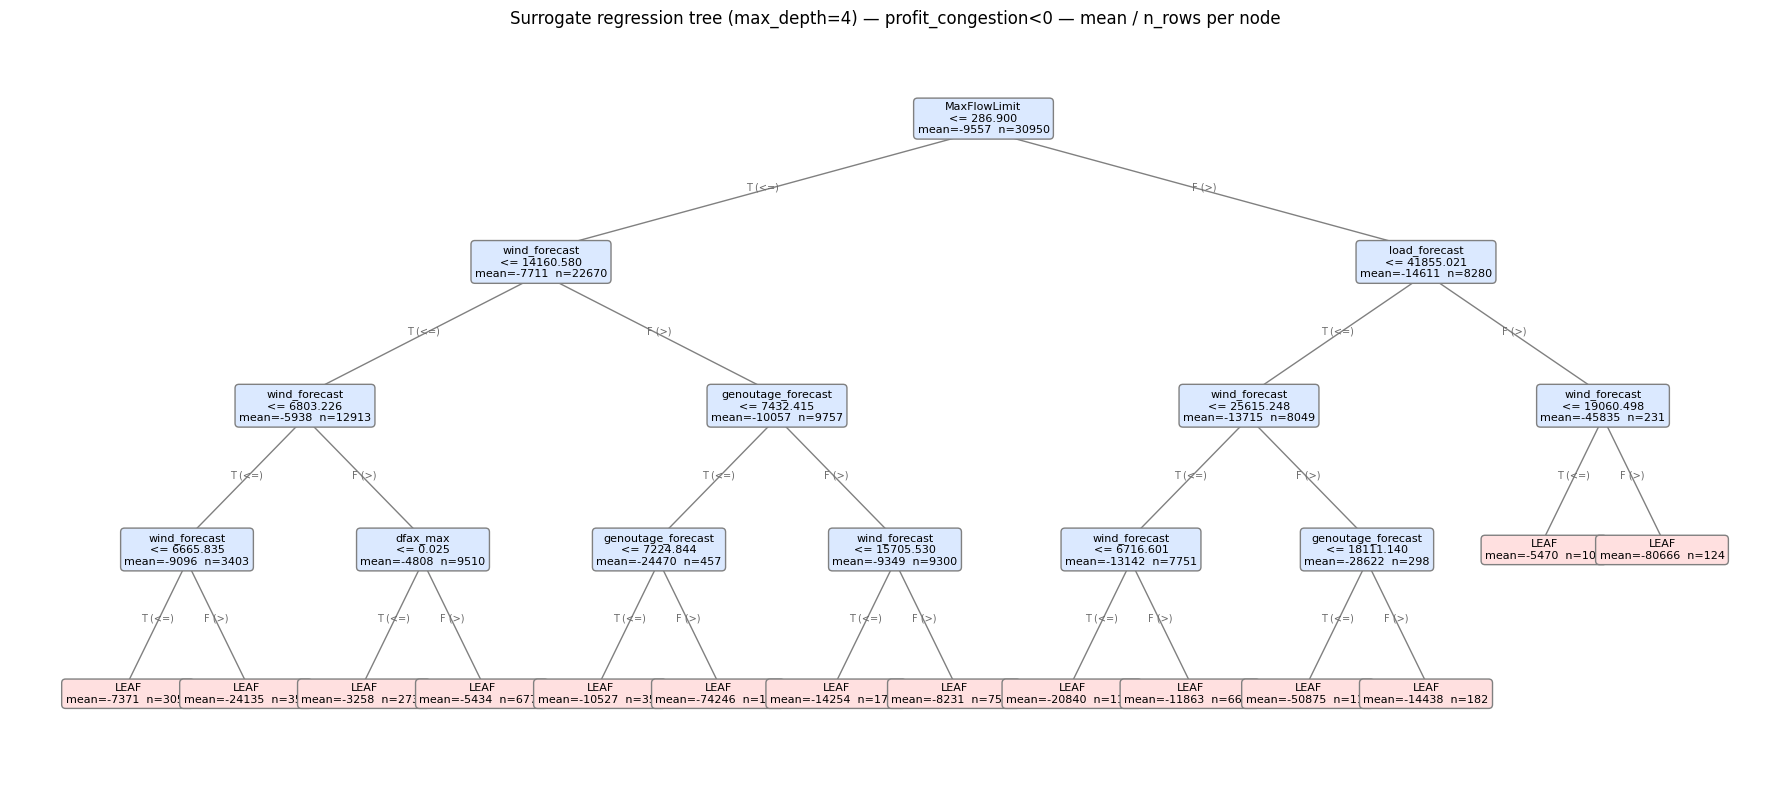

In [36]:
import matplotlib.pyplot as plt

# ---------- visualize the surrogate tree as an actual tree diagram ----------
pos_xy, _xctr = {}, [0]
def _layout(nd, depth):
    if t.feature[nd] == _tree.TREE_UNDEFINED:
        x = _xctr[0]; _xctr[0] += 1
        pos_xy[nd] = (x, -depth)
        return x
    lx = _layout(t.children_left[nd], depth + 1)
    rx = _layout(t.children_right[nd], depth + 1)
    x = (lx + rx) / 2
    pos_xy[nd] = (x, -depth)
    return x
_layout(0, 0)

fig, ax = plt.subplots(figsize=(18, 8))
for nd in range(t.node_count):
    x, y_ = pos_xy[nd]
    is_leaf = t.feature[nd] == _tree.TREE_UNDEFINED
    lab = 'LEAF' if is_leaf else f'{feat[t.feature[nd]]}\n<= {t.threshold[nd]:.3f}'
    box_txt = f'{lab}\nmean={node_mean[nd]:.0f}  n={int(node_n[nd])}'
    color = '#ffe0e0' if is_leaf else '#dbe9ff'
    ax.text(x, y_, box_txt, ha='center', va='center', fontsize=8, zorder=2,
            bbox=dict(boxstyle='round,pad=0.35', fc=color, ec='gray'))
    if not is_leaf:
        for child, edge_lab in ((t.children_left[nd], 'T (<=)'), (t.children_right[nd], 'F (>)')):
            cx, cy = pos_xy[child]
            ax.plot([x, cx], [y_ - 0.08, cy + 0.08], color='gray', lw=1, zorder=1)
            ax.text((x + cx) / 2, (y_ + cy) / 2, edge_lab, fontsize=7, color='dimgray', ha='center')

xs = [p[0] for p in pos_xy.values()]; ys = [p[1] for p in pos_xy.values()]
ax.set_xlim(min(xs) - 1, max(xs) + 1); ax.set_ylim(min(ys) - 0.6, max(ys) + 0.6)
ax.axis('off')
ax.set_title('Surrogate regression tree (max_depth=4) — profit_congestion<0 — mean / n_rows per node')
plt.tight_layout()
plt.show()


In [35]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

# ---------- out-of-sample check on holdout_df ----------
dh = (holdout_df.query('rtm_sum_1m<-200 and profit_congestion < 0')
      .dropna(subset=['profit_congestion']).copy())
yh = dh['profit_congestion'].astype(float)
Xc_h = dh[FEATS + CATS].copy()                            # LightGBM: native categoricals + NaN
for c in CATS: Xc_h[c] = Xc_h[c].astype('category')
Xn_h = dh[FEATS + CATS].copy()                             # sklearn: numeric, no NaN
for c in CATS: Xn_h[c] = Xn_h[c].astype('category').cat.codes
Xn_h = Xn_h.fillna(Xn.median())                             # fill with TRAIN medians -> no leakage

print(f'holdout_df: rows={len(yh)}  profit_congestion mean={yh.mean():.1f}  median={yh.median():.1f}')

def eval_model(name, model, X):
    pred = model.predict(X)
    print(f'\n=== {name} on holdout_df ===')
    print(f'  R2={r2_score(yh, pred):.3f}  MAE={mean_absolute_error(yh, pred):.1f}  '
          f'RMSE={root_mean_squared_error(yh, pred):.1f}')

eval_model('LightGBM', lgbm, Xc_h)
eval_model('RandomForest', rf, Xn_h)


holdout_df: rows=11307  profit_congestion mean=-8229.2  median=-2461.9

=== LightGBM on holdout_df ===
  R2=-0.151  MAE=9098.5  RMSE=16610.2

=== RandomForest on holdout_df ===
  R2=-0.038  MAE=9119.6  RMSE=15773.8


# Break down by KV and train model separately 

In [55]:
from sklearn.tree import DecisionTreeRegressor, _tree
FEATS = [c for c in globals().get('compact', features) if c not in ('KV','KV_group')]
sev = lambda g: ((g['rt_da'] < -3000) & (g['short_profit'] < -400000) & (g['profit_congestion'] < 0)).astype(int)

def kv_tree(g, grp):
    y = sev(g); Xt = g[FEATS]
    surr = DecisionTreeRegressor(max_depth=3, min_samples_leaf=100, random_state=0).fit(Xt, y)
    imp = pd.Series(surr.feature_importances_, index=FEATS).sort_values(ascending=False)
    dp = surr.decision_path(Xt); yv = y.values
    n1 = np.asarray(dp[yv==1].sum(0)).ravel(); n0 = np.asarray(dp[yv==0].sum(0)).ravel()
    t, TOT1, ft = surr.tree_, int(yv.sum()), list(Xt.columns)
    print(f'\n== KV_group={grp}  rows={len(g)}  pos={TOT1}  base={yv.mean()*100:.2f}% ==')
    print('  top:', {k: round(v,2) for k,v in imp.head(5).items() if v>0})
    def show(n=0,d=0,b=''):
        tot=n1[n]+n0[n]; pur=n1[n]/tot*100 if tot else 0; rec=n1[n]/TOT1*100 if TOT1 else 0
        lab='LEAF' if t.feature[n]==_tree.TREE_UNDEFINED else f'[{ft[t.feature[n]]} <= {t.threshold[n]:.2f}]'
        print(f'  {"  "*d}{b}{lab}  pur={pur:4.1f}%  n1={int(n1[n])}  rec={rec:4.1f}%')
        if t.feature[n]!=_tree.TREE_UNDEFINED: show(t.children_left[n],d+1,'T>'); show(t.children_right[n],d+1,'F>')
    show()

for grp, g in train_df_filter.groupby('KV_group'):
    if len(g) >= 500 and g['bad_rtda'].sum() >= 30: kv_tree(g, grp)
    else: print(f'\n== KV_group={grp}: too few (rows={len(g)}, pos={int(g.bad_rtda.sum())}) ==')

interested = train_df.query('rt_da < -3000 and short_profit<-400000 and profit_congestion < 0')


== KV_group=02_<=115  rows=29176  pos=12  base=0.04% ==
  top: {'long_profit_sum_1y': 0.48, 'FlowRatio': 0.36, 'short_profit_sum_1m': 0.16}
  [long_profit_sum_1y <= -3566199.38]  pur= 0.0%  n1=12  rec=100.0%
    T>LEAF  pur= 1.8%  n1=3  rec=25.0%
    F>[FlowRatio <= 1.17]  pur= 0.0%  n1=9  rec=75.0%
      T>[short_profit_sum_1m <= -1238948.50]  pur= 0.0%  n1=7  rec=58.3%
        T>LEAF  pur= 1.0%  n1=2  rec=16.7%
        F>LEAF  pur= 0.0%  n1=5  rec=41.7%
      F>LEAF  pur= 0.2%  n1=2  rec=16.7%

== KV_group=03_138  rows=45283  pos=36  base=0.08% ==
  top: {'dfax_absmax': 0.39, 'wind_forecast': 0.31, 'dam_sum_1m': 0.14, 'rtm_lag1': 0.07, 'short_profit_sum_1m': 0.05}
  [dam_sum_1m <= -14818.62]  pur= 0.1%  n1=36  rec=100.0%
    T>[dfax_absmax <= 0.73]  pur= 0.5%  n1=28  rec=77.8%
      T>[rtm_lag1 <= -7329.06]  pur= 0.3%  n1=19  rec=52.8%
        T>LEAF  pur= 1.8%  n1=5  rec=13.9%
        F>LEAF  pur= 0.3%  n1=14  rec=38.9%
      F>[wind_forecast <= 14374.49]  pur= 4.4%  n1=9  rec=25.0

In [56]:
from sklearn.tree import DecisionTreeRegressor, _tree
FEATS = [c for c in globals().get('compact', features) if c not in ('KV','KV_group','rtm_sum_7d')]  # drop split var

def seg_tree(g, name):
    y = g['bad_rtda']; Xt = g[FEATS]
    surr = DecisionTreeRegressor(max_depth=3, min_samples_leaf=100, random_state=0).fit(Xt, y)
    imp = pd.Series(surr.feature_importances_, index=FEATS).sort_values(ascending=False)
    dp = surr.decision_path(Xt); yv = y.values
    n1 = np.asarray(dp[yv==1].sum(0)).ravel(); n0 = np.asarray(dp[yv==0].sum(0)).ravel()
    t, TOT1, ft = surr.tree_, int(yv.sum()), list(Xt.columns)
    print(f'\n== {name}  rows={len(g):,}  pos={TOT1}  base={yv.mean()*100:.2f}% ==')
    print('  top:', {k: round(v,2) for k,v in imp.head(5).items() if v>0})
    def show(n=0,dep=0,b=''):
        tot=n1[n]+n0[n]; pur=n1[n]/tot*100 if tot else 0; rec=n1[n]/TOT1*100 if TOT1 else 0
        lab='LEAF' if t.feature[n]==_tree.TREE_UNDEFINED else f'[{ft[t.feature[n]]} <= {t.threshold[n]:.2f}]'
        print(f'  {"  "*dep}{b}{lab}  pur={pur:4.1f}%  n1={int(n1[n])}  tot={int(tot)}  rec={rec:4.1f}%')
        if t.feature[n]!=_tree.TREE_UNDEFINED: show(t.children_left[n],dep+1,'T>'); show(t.children_right[n],dep+1,'F>')
    show()

m = train_df_filter['rtm_sum_7d'] <= -15000
seg_tree(train_df_filter[m],  'rtm_sum_7d <= -15000')
seg_tree(train_df_filter[~m], 'rtm_sum_7d >  -15000')



== rtm_sum_7d <= -15000  rows=3,612  pos=389  base=10.77% ==
  top: {'rtda_1d': 0.37, 'rtda_sum_1y': 0.25, 'wind_forecast': 0.14, 'rtda_avg_3m': 0.09, 'ice_price_forecast': 0.09}
  [rtda_1d <= -2797.83]  pur=10.8%  n1=389  tot=3612  rec=100.0%
    T>[rtda_sum_1y <= -109140.14]  pur=19.8%  n1=162  tot=818  rec=41.6%
      T>[rtda_sum_7d <= -21549.29]  pur=32.6%  n1=71  tot=218  rec=18.3%
        T>LEAF  pur=41.2%  n1=42  tot=102  rec=10.8%
        F>LEAF  pur=25.0%  n1=29  tot=116  rec= 7.5%
      F>[ice_price_forecast <= 74.27]  pur=15.2%  n1=91  tot=600  rec=23.4%
        T>LEAF  pur=12.2%  n1=59  tot=482  rec=15.2%
        F>LEAF  pur=27.1%  n1=32  tot=118  rec= 8.2%
    F>[wind_forecast <= 14518.42]  pur= 8.1%  n1=227  tot=2794  rec=58.4%
      T>[rtda_sum_1y <= -39188.56]  pur= 5.2%  n1=82  tot=1583  rec=21.1%
        T>LEAF  pur= 7.8%  n1=60  tot=765  rec=15.4%
        F>LEAF  pur= 2.7%  n1=22  tot=818  rec= 5.7%
      F>[rtda_avg_3m <= -477.19]  pur=12.0%  n1=145  tot=1211  rec=

# Extreme rt_da tail on full train_df — how good is FlowRatio vs other drivers


In [27]:
import numpy as np, pandas as pd, lightgbm as lgb
from sklearn.metrics import mean_pinball_loss
pd.set_option('display.max_colwidth', None)

d = train_df_filter.dropna(subset=['rt_da']).copy()
y = d['rt_da'].astype(float)
FEATS = globals().get('compact', features)
X = d[FEATS + CATS].copy()
for c in CATS: X[c] = X[c].astype('category')
print(f'rows={len(d)}  rt_da mean={y.mean():.1f}  median={y.median():.1f}  '
      f'p1={y.quantile(.01):.1f}  p5={y.quantile(.05):.1f}')

# quantile regression via pinball loss (LightGBM objective='quantile') at several taus,
# focused on the extreme LEFT tail (smallest / most negative rt_da) since that's the risk side
TAUS = [0.01, 0.05]
models, preds, scores = {}, {}, {}
for tau in TAUS:
    m = lgb.LGBMRegressor(objective='quantile', alpha=tau,
                          n_estimators=400, learning_rate=0.05, num_leaves=31, min_child_samples=50,
                          subsample=0.8, colsample_bytree=0.8, random_state=0, n_jobs=-1, verbose=-1)
    m.fit(X, y, categorical_feature=CATS)
    models[tau] = m
    preds[tau]  = m.predict(X)
    scores[tau] = mean_pinball_loss(y, preds[tau], alpha=tau)

print('\n=== pinball loss by quantile (in-sample, full train_df) ===')
for tau in TAUS:
    print(f'  tau={tau:<5} pinball_loss={scores[tau]:.2f}')

# feature importance from the tau=0.01 model (the most extreme tail)
imp = pd.Series(models[0.01].booster_.feature_importance('gain'), index=X.columns)
imp = (imp / imp.sum()).sort_values(ascending=False)
print('\n=== feature importance (gain) — tau=0.01 quantile model (most extreme tail) ===')
display(imp.head(15).round(4).to_frame('gain'))
fr_rank = list(imp.index).index('FlowRatio') + 1 if 'FlowRatio' in imp.index else None
print(f"\nFlowRatio rank: {fr_rank} of {len(imp)}   gain={imp.get('FlowRatio', float('nan')):.4f}")

# coverage check: what fraction of actual rt_da fall below the predicted tau-quantile?
# should be close to tau if the model is well-calibrated
print('\n=== calibration: P(rt_da < predicted q_tau) vs tau ===')
for tau in TAUS:
    cov = (y.values < preds[tau]).mean()
    print(f'  tau={tau:<5} target={tau:.2f}  actual_coverage={cov:.3f}')


rows=133430  rt_da mean=-58.9  median=0.0  p1=-3656.6  p5=-676.7

=== pinball loss by quantile (in-sample, full train_df) ===
  tau=0.01  pinball_loss=22.17
  tau=0.05  pinball_loss=75.70

=== feature importance (gain) — tau=0.01 quantile model (most extreme tail) ===


,gain
rtm_lag1,0.0502
wind_forecast,0.0469
FlowRatio,0.0364
rtm_sum_7d,0.0249
ice_price_forecast,0.0214
gas_price_forecast,0.0207
rtm_sum_1m,0.0188
load_forecast,0.0186
rt_spike_3y,0.0182
dfax_std,0.0176



FlowRatio rank: 3 of 85   gain=0.0364

=== calibration: P(rt_da < predicted q_tau) vs tau ===
  tau=0.01  target=0.01  actual_coverage=0.007
  tau=0.05  target=0.05  actual_coverage=0.046


In [28]:
import lightgbm as lgb
from scipy.stats import spearmanr
from sklearn.metrics import mean_pinball_loss

# ---------- how good is FlowRatio alone at the extreme tail? ----------
tail_taus = [0.01, 0.05]

rho_all, p_all = spearmanr(d['FlowRatio'], y)
print(f'Spearman(FlowRatio, rt_da) overall: rho={rho_all:.3f}  p={p_all:.1e}')

for tau in tail_taus:
    thr = y.quantile(tau)
    in_tail = y <= thr
    rho_t, p_t = spearmanr(d.loc[in_tail, 'FlowRatio'], y[in_tail])
    print(f'  within bottom {tau*100:.0f}% (rt_da <= {thr:.1f}, n={int(in_tail.sum())}): '
          f'Spearman(FlowRatio, rt_da) rho={rho_t:.3f}  p={p_t:.1e}')

# single-feature quantile model: FlowRatio ONLY, vs the full multivariate model, at the same taus
Xf = d[['FlowRatio']].copy()
print('\n=== FlowRatio-only vs full-feature quantile model: pinball loss ===')
for tau in tail_taus:
    mf = lgb.LGBMRegressor(objective='quantile', alpha=tau, n_estimators=400, learning_rate=0.05,
                           num_leaves=31, min_child_samples=50, subsample=0.8, colsample_bytree=0.8,
                           random_state=0, n_jobs=-1, verbose=-1).fit(Xf, y)
    pf = mf.predict(Xf)
    loss_flowratio_only = mean_pinball_loss(y, pf, alpha=tau)
    loss_full = scores[tau]
    gain_pct = (loss_flowratio_only - loss_full) / loss_flowratio_only * 100
    print(f'  tau={tau:<5} FlowRatio-only={loss_flowratio_only:.2f}   full-model={loss_full:.2f}   '
          f'gain_from_others={gain_pct:.1f}%')


Spearman(FlowRatio, rt_da) overall: rho=nan  p=nan
  within bottom 1% (rt_da <= -3656.6, n=1335): Spearman(FlowRatio, rt_da) rho=nan  p=nan
  within bottom 5% (rt_da <= -676.7, n=6672): Spearman(FlowRatio, rt_da) rho=nan  p=nan

=== FlowRatio-only vs full-feature quantile model: pinball loss ===
  tau=0.01  FlowRatio-only=60.84   full-model=22.17   gain_from_others=63.6%
  tau=0.05  FlowRatio-only=119.68   full-model=75.70   gain_from_others=36.7%


In [30]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor, _tree

# ---------- readable tree: split + node stats at EACH node, on rt_da (full train_df) ----------
Xn = d[FEATS + CATS].copy()
for c in CATS: Xn[c] = Xn[c].astype('category').cat.codes
Xn = Xn.fillna(Xn.median())
feat = list(Xn.columns)

surr = DecisionTreeRegressor(max_depth=4, min_samples_leaf=100, random_state=0).fit(Xn, y)
t = surr.tree_
node_mean = t.value[:, 0, 0]
node_n = t.n_node_samples
print('\n=== tree splits: mean rt_da / n_rows at EACH node ===')
def show(nd=0, dep=0, br=''):
    lab = 'LEAF' if t.feature[nd]==_tree.TREE_UNDEFINED else f'[{feat[t.feature[nd]]} <= {t.threshold[nd]:.3f}]'
    print(f'  {"  "*dep}{br}{lab}  mean={node_mean[nd]:>10.1f}  n_rows={int(node_n[nd]):>5}')
    if t.feature[nd] != _tree.TREE_UNDEFINED:
        show(t.children_left[nd], dep+1, 'T> ')   # <= thr
        show(t.children_right[nd], dep+1, 'F> ')  # >  thr
show()

# leaf rules ranked by worst (most negative) mean rt_da
rules = {}
def rec(n, c):
    if t.feature[n]==_tree.TREE_UNDEFINED: rules[n]=' AND '.join(c) or '(all)'
    else:
        f, th = feat[t.feature[n]], t.threshold[n]
        rec(t.children_left[n], c+[f'{f} <= {th:.3f}']); rec(t.children_right[n], c+[f'{f} > {th:.3f}'])
rec(0, [])
leaves = [i for i in range(t.node_count) if t.feature[i]==_tree.TREE_UNDEFINED]
tab = (pd.DataFrame([{'mean':round(node_mean[i],1),'n_rows':int(node_n[i]),
                      'rule':rules[i]} for i in leaves]).sort_values('mean').reset_index(drop=True))
tab['cum_rows'] = (tab['n_rows'].cumsum()/len(y)*100).round(1)
print('\n=== leaf rules ranked by worst mean rt_da ===')
for _, r in tab.iterrows():
    print(f"mean={r['mean']:>10.1f}  n_rows={int(r['n_rows']):>5}  cum_rows={r['cum_rows']:>5}%")
    print(f"     RULE: {r['rule']}")



=== tree splits: mean rt_da / n_rows at EACH node ===
  [rtda_sum_7d <= -40003.303]  mean=     -58.9  n_rows=133430
    T> LEAF  mean=   -2736.4  n_rows=  143
    F> [rtda_sum_7d <= -1070.702]  mean=     -56.0  n_rows=133287
      T> [rtda_sum_3m <= -47656.691]  mean=    -205.5  n_rows=25001
        T> [rt_max_3m <= -15122.946]  mean=    -775.6  n_rows= 1818
          T> LEAF  mean=    -343.8  n_rows=  721
          F> LEAF  mean=   -1059.4  n_rows= 1097
        F> [rtm_sum_7d <= -51504.768]  mean=    -160.8  n_rows=23183
          T> LEAF  mean=    2166.2  n_rows=  100
          F> LEAF  mean=    -170.9  n_rows=23083
      F> [rtda_avg_7d <= 991.860]  mean=     -21.5  n_rows=108286
        T> [rtda_sum_1y <= -71.813]  mean=     -26.9  n_rows=106479
          T> LEAF  mean=     -47.2  n_rows=79597
          F> LEAF  mean=      33.3  n_rows=26882
        F> [rtm_sum_3y <= -1296185.750]  mean=     300.1  n_rows= 1807
          T> LEAF  mean=    -694.3  n_rows=  144
          F> LEAF  me

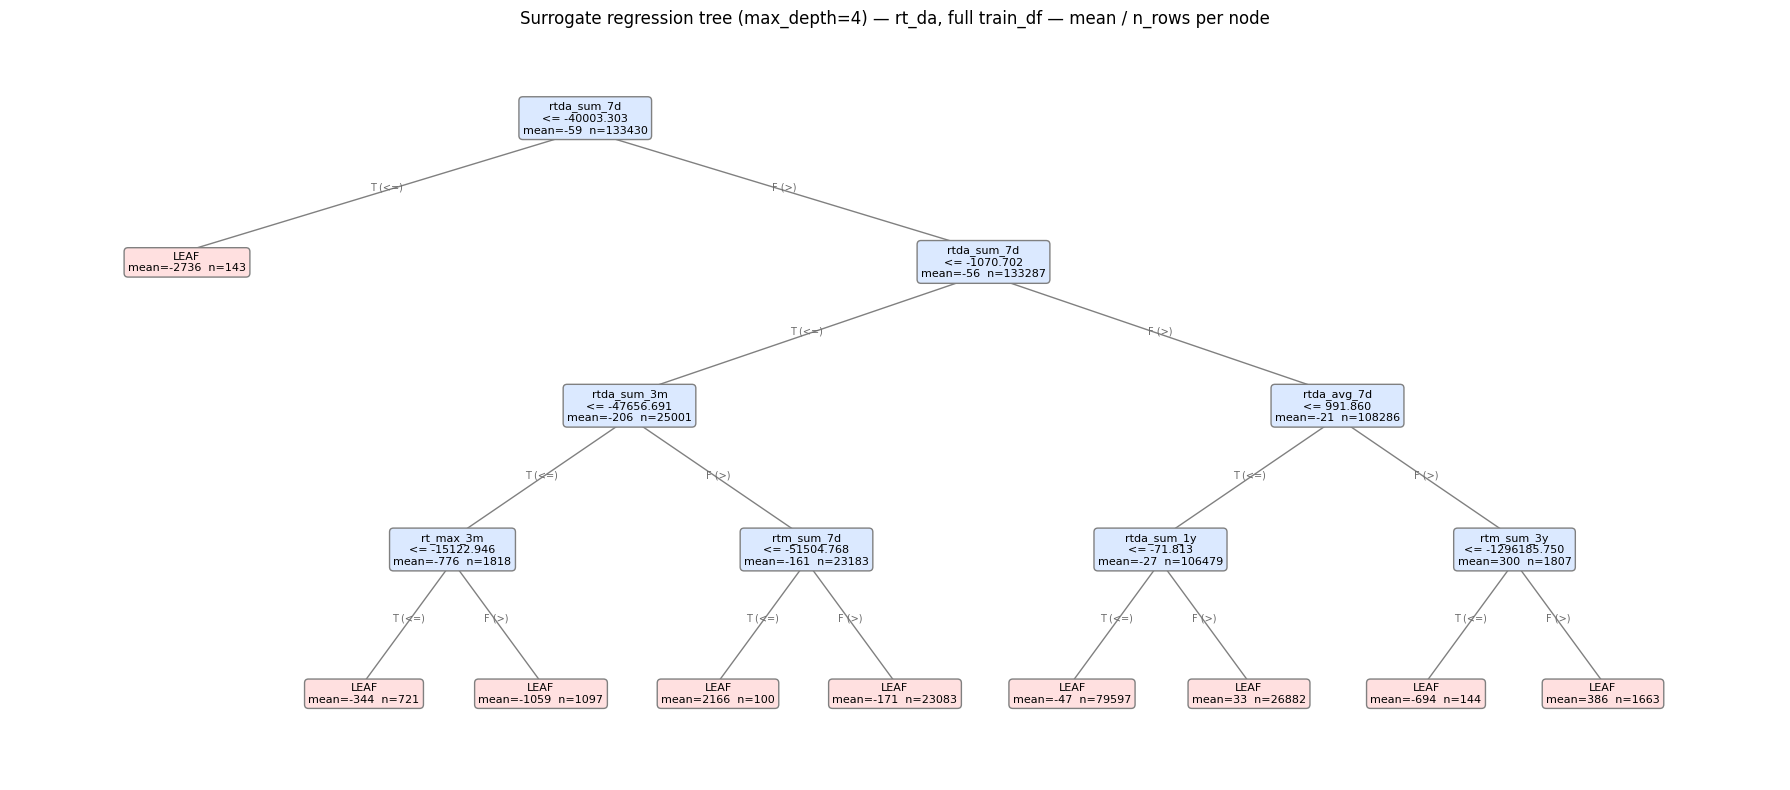

In [31]:
import matplotlib.pyplot as plt

# ---------- visualize the surrogate tree as an actual tree diagram ----------
pos_xy, _xctr = {}, [0]
def _layout(nd, depth):
    if t.feature[nd] == _tree.TREE_UNDEFINED:
        x = _xctr[0]; _xctr[0] += 1
        pos_xy[nd] = (x, -depth)
        return x
    lx = _layout(t.children_left[nd], depth + 1)
    rx = _layout(t.children_right[nd], depth + 1)
    x = (lx + rx) / 2
    pos_xy[nd] = (x, -depth)
    return x
_layout(0, 0)

fig, ax = plt.subplots(figsize=(18, 8))
for nd in range(t.node_count):
    x, y_ = pos_xy[nd]
    is_leaf = t.feature[nd] == _tree.TREE_UNDEFINED
    lab = 'LEAF' if is_leaf else f'{feat[t.feature[nd]]}\n<= {t.threshold[nd]:.3f}'
    box_txt = f'{lab}\nmean={node_mean[nd]:.0f}  n={int(node_n[nd])}'
    color = '#ffe0e0' if is_leaf else '#dbe9ff'
    ax.text(x, y_, box_txt, ha='center', va='center', fontsize=8, zorder=2,
            bbox=dict(boxstyle='round,pad=0.35', fc=color, ec='gray'))
    if not is_leaf:
        for child, edge_lab in ((t.children_left[nd], 'T (<=)'), (t.children_right[nd], 'F (>)')):
            cx, cy = pos_xy[child]
            ax.plot([x, cx], [y_ - 0.08, cy + 0.08], color='gray', lw=1, zorder=1)
            ax.text((x + cx) / 2, (y_ + cy) / 2, edge_lab, fontsize=7, color='dimgray', ha='center')

xs = [p[0] for p in pos_xy.values()]; ys = [p[1] for p in pos_xy.values()]
ax.set_xlim(min(xs) - 1, max(xs) + 1); ax.set_ylim(min(ys) - 0.6, max(ys) + 0.6)
ax.axis('off')
ax.set_title('Surrogate regression tree (max_depth=4) — rt_da, full train_df — mean / n_rows per node')
plt.tight_layout()
plt.show()


# Design cut and reflect it on the portfolio and calculate the P&L 

In [ ]:
# exposure = pd.read_csv(file_loc + 'exposure_dthr.csv')
# # stream bid_dthr.csv in chunks, keep only short_profit > 0 (avoids loading the whole file)

# Analysis on the big loss day, RTM patterns 

In [11]:
import sys
sys.path.append('/var/www/python/Prod/nighthawk/')
from nighthawk.util.bigquery_functions import download_df_from_bq

sql = 'SELECT * FROM `movetocloud-999.qctest.SPP_profit_dfax_repfam`'
bids = download_df_from_bq(sql, print_flag=True)

Query size 6623.378 MB   Est. Cost @$6.25/TB: $ 0.039
time_taken for downloading df from bq:  2.6  minutes


In [31]:
train_df.sort_values(['short_profit'])[:20]

,constraint_family_num,dt,profit,profit_congestion,long_profit,short_profit,FlowRatio,ShadowPrice_min,ShadowPrice_sum,MinFlowLimit,...,dfax_max,dfax_min,dfax_mean,dfax_std,dfax_absmean,dfax_pos_cnt,dfax_neg_cnt,dfax_strong,dfax_range,dfax_absmax
498599,858,2025-08-06,-385404.13755,-387596.06949,1.604574e+05,-6.471926e+06,1.000000,-2711.539323,-5423.078646,-126.000000,...,0.73153,-0.02114,0.229750,0.388677,0.257937,2.0,4.0,0.333333,0.75267,0.73153
237005,146,2023-08-28,-264518.73827,-236924.75386,2.570425e+05,-4.173574e+06,1.000000,-121.700729,-365.102187,-367.000000,...,0.67190,-0.02190,0.005152,0.119245,0.042504,4.0,88.0,0.043478,0.69380,0.67190
351194,904,2024-06-19,13981.09690,-47788.72618,1.486245e+06,-3.619023e+06,NaN,NaN,NaN,NaN,...,0.86240,-0.05650,-0.024498,0.149853,0.073962,4.0,129.0,1.000000,0.91890,0.86240
569169,1039619,2026-01-16,-109291.61056,-111882.45768,3.588000e+04,-2.902923e+06,0.770970,0.000000,0.000000,-190.000000,...,0.32400,-0.02250,0.042119,0.100803,0.059230,15.0,12.0,0.222222,0.34650,0.32400
444273,902,2025-03-23,68597.28461,69080.11286,4.066652e+05,-2.773966e+06,NaN,NaN,NaN,NaN,...,0.88450,-0.15470,-0.015640,0.306951,0.198011,10.0,87.0,1.000000,1.03920,0.88450
491119,858,2025-07-21,-118622.80836,-124437.24530,6.471965e+02,-2.760686e+06,1.000000,-1176.290160,-2352.580319,-126.000000,...,0.73153,0.02024,0.106623,0.234585,0.106623,9.0,0.0,0.111111,0.71129,0.73153
341137,904,2024-05-31,-91516.50082,-65579.70394,3.920698e+05,-2.713538e+06,NaN,NaN,NaN,NaN,...,0.83510,-0.05650,0.003329,0.207183,0.098002,8.0,117.0,0.952000,0.89160,0.83510
412012,232,2024-11-12,-3125.62346,-32596.66675,1.811652e+05,-2.392236e+06,NaN,NaN,NaN,NaN,...,0.37460,-0.02190,0.031312,0.099793,0.049573,14.0,35.0,0.163265,0.39650,0.37460
286156,146,2024-01-06,115201.44829,65715.27590,2.922363e+06,-2.390479e+06,1.000000,-1228.346896,-3685.040688,-473.000000,...,0.67190,-0.02450,0.005572,0.118739,0.043203,4.0,74.0,0.051282,0.69640,0.67190
247313,146,2023-09-19,80054.42997,82832.73262,2.622208e+06,-2.365504e+06,0.960190,0.000000,0.000000,-367.000000,...,0.67190,-0.05970,0.012396,0.135518,0.050894,7.0,64.0,0.084507,0.73160,0.67190


In [35]:
bids.query('dt=="2024-03-21" and constraint_family_num == 904').sort_values(['profit'])

,dt,node_num,incdec,bid_mw,clear_mw,profit,profit_congestion,node_name,rep_constraint,dfax,constraint_family_num,rep_dart,rep_pastyr_mvalue
308143,2024-03-21,1017.0,Increment,317.809091,163.6,-52659.78903,-51006.59830,SPS.ROSWLL.SLR,2686.0,0.8624,904.0,DA,-26148.074219
1054509,2024-03-21,872.0,Decrement,920.995533,155.2,-2221.28428,-1092.18324,WAUE.BEPM.EDGELEY,2686.0,-0.0505,904.0,DA,-26148.074219
223347,2024-03-21,1106.0,Decrement,442.286364,209.6,-1722.07224,-2037.22200,CSWS_ETEC_LOAD,2686.0,-0.0504,904.0,DA,-26148.074219
238112,2024-03-21,1491.0,Decrement,337.237699,129.0,-1296.54034,1102.42797,OPPD.PLVIEW,2686.0,-0.0505,904.0,DA,-26148.074219
228122,2024-03-21,936.0,Decrement,380.644820,184.9,-944.50286,914.59154,WAUE.NMCA.NEAL4,2686.0,-0.0505,904.0,DA,-26148.074219
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1118545,2024-03-21,1204.0,Decrement,228.034038,109.3,1996.63650,-302.02561,NPPD_MEAN_SCRI,2686.0,-0.0505,904.0,DA,-26148.074219
165124,2024-03-21,1311.0,Increment,400.450000,163.2,2135.92640,-201.95104,CSWS.VOLT.0053,2686.0,-0.0563,904.0,DA,-26148.074219
1112208,2024-03-21,1152.0,Increment,178.600000,39.5,2724.05545,5149.13250,WFEC.PEOP.CENTRAHOMAWEST,2686.0,-0.0503,904.0,DA,-26148.074219
159116,2024-03-21,475.0,Decrement,431.011945,291.2,3787.85643,2870.66897,NPPD_LAREDO,2686.0,-0.0506,904.0,DA,-26148.074219


In [34]:
portfolio_df.query('dt=="2024-09-27" and node_num == 1301 and incdec == "Increment"').groupby('hr')['bid_mw'].sum()

hr
1     33.800
2     11.670
3      5.760
5     24.290
6     30.050
7     30.050
8     37.060
9     39.560
10    31.300
11    38.310
12    31.300
13    17.280
14     5.760
19     5.760
20    30.050
21    56.080
22    30.050
23    50.320
24    38.935
Name: bid_mw, dtype: float64

# Big RTM loss days — RT-spike patterns

**Case studies (worst short-profit days)**

1. **2025-08-06, node 1484** — big RTM in the lag-2-day window; RT stayed elevated for 6+ consecutive hours. We bid 530 MW short and cleared 428.
2. **2023-08-28, node 881** — elevated RTM in the lag-4-day window and across the past month; RTM stayed high for 6+ hours, and we bid **more** during the RTM-binding hours.
3. **2026-01-16, node 1030** — present in the lag-3-day window; RT spiked for two hours, and our bid MW were concentrated in exactly those hours.
4. **2025-07-21, node 1484** — present over the lag-30-day window; RT spiked across multiple hours — the first occurrence in the last two weeks. DA was not high but RT was, and we bid heavily in those hours.
5. **2024-09-27, node 1301** — recurring over the last month; the 27th was the first occurrence in 7 days. DA was quite small (the loss was RT-driven).

## Summary

1. **Every** large short-profit loss shows an **RT spike over multiple hours within the last 30 days** — though the spiking hours are **not necessarily consecutive**.
2. **DA fails to react to the RT spike for more than two weeks**, and that persistent DA-vs-RT disconnect is what turns into the large RT-spike loss.

## Control

- **Cut** when a node shows an **RT spike over multiple (not necessarily consecutive) hours in a single day within the past 30 days**.
- **Cut more aggressively when DA has not been reacting to those spikes over the past 5 days** (persistent DA-vs-RT divergence).

In [ ]:
train_df_filter.short

# Shrink bids by constraint-family-day scale factor

Same idea as the SPP scale-table BQ step, done locally on `bids` + `train_df`:
decide a shrink factor per **(dt, constraint_family_num)**, then push it down to the
node-level `bid_mw` through each node's dfax to that family (directional, |dfax|>cutoff,
most-aggressive cut when a node loads several risky families).

In [16]:
import numpy as np, pandas as pd

def scale_bids_by_family(bids, scale_df, dfax_cutoff=0.05,
                         factor_col='final_factor', kv_groups=None):
    """Push a per-(dt, constraint_family_num) shrink factor down to node-level bids.

    bids     : one row per (dt, node_num, incdec, constraint_family_num); bid_mw repeats
               across the families a node loads. Needs columns: dfax, bid_mw.
    scale_df : per (dt, constraint_family_num) with `factor_col` (<=1 shrinks, 1 = keep),
               optionally a KV_group column (only used when kv_groups is passed).
    returns  : one row per (dt, node_num, incdec) with node_factor, bid_mw_original, scaled_bid_mw.
    """
    b = bids.copy(); b['dt'] = b['dt'].astype(str)
    s = scale_df.copy(); s['dt'] = s['dt'].astype(str)
    keep = ['dt', 'constraint_family_num', factor_col] + (['KV_group'] if kv_groups else [])
    b = b.merge(s[keep], on=['dt', 'constraint_family_num'], how='left')

    # a family only shrinks the side its dfax loads:
    #   dfax>0 -> injecting (Increment) raises flow;  dfax<0 -> withdrawing (Decrement) raises flow
    inc_side = (b['incdec'] == 'Increment') & (b['dfax'] > 0)
    dec_side = (b['incdec'] == 'Decrement') & (b['dfax'] < 0)
    eligible = (inc_side | dec_side) & (b['dfax'].abs() > dfax_cutoff) & b[factor_col].notna()
    if kv_groups is not None:
        eligible &= b['KV_group'].isin(kv_groups)
    b['row_factor'] = np.where(eligible, b[factor_col], 1.0)

    # most aggressive cut across every family that loads this node-bid (mirrors MIN() in the BQ step)
    node_factor = (b.groupby(['dt', 'node_num', 'incdec'])['row_factor']
                     .min().rename('node_factor').reset_index())
    # collapse the exploded bids back to one row per (dt, node, incdec)
    node_bids = (b.drop_duplicates(['dt', 'node_num', 'incdec'])
                   [['dt', 'node_num', 'incdec', 'bid_mw']]
                   .merge(node_factor, on=['dt', 'node_num', 'incdec'], how='left'))
    node_bids['node_factor'] = node_bids['node_factor'].fillna(1.0)
    node_bids['bid_mw_original'] = node_bids['bid_mw']
    node_bids['scaled_bid_mw'] = node_bids['bid_mw'] * node_bids['node_factor']
    return node_bids


In [20]:
# ---- how much flow each (dt, constraint_family_num) is loaded with, by side ----
# exposure = MW of flow the bids push onto the constraint = bid_mw * |dfax|
DFAX_CUTOFF = 0.05
_e = bids[bids['dfax'].abs() > DFAX_CUTOFF].copy()
_e = _e[((_e['incdec'] == 'Increment') & (_e['dfax'] > 0)) |
        ((_e['incdec'] == 'Decrement') & (_e['dfax'] < 0))]
_e['flow_mw'] = _e['bid_mw'] * _e['dfax'].abs()   # bid MW -> flow on the constraint
family_day_exposure = (_e.groupby(['dt', 'constraint_family_num'])
                         .agg(family_bid_mw=('bid_mw', 'sum'),
                              family_flow_mw=('flow_mw', 'sum')).reset_index())
print('family-day exposures:', family_day_exposure.shape[0])
display(family_day_exposure.sort_values('family_flow_mw', ascending=False).head())


family-day exposures: 1385892


,dt,constraint_family_num,family_bid_mw,family_flow_mw
200010,2022-02-15,902.0,13480.267235,6628.948426
196898,2022-02-11,902.0,13151.496536,6439.595844
101417,2021-09-26,902.0,16448.450682,5803.766479
195379,2022-02-08,902.0,9833.409222,4765.924727
900150,2024-09-06,902.0,13978.692311,4755.503206


In [21]:
portfolio_df = pd.read_csv(file_loc + 'portfolio_df_Jun_2026.csv')

In [23]:
# ---- build the per-family-day shrink factor from train_df (EDIT this rule) ----
# train_df is at (dt, constraint_family_num) level. Set final_factor per family-day:
#   final_factor = 1.0  -> keep bid unchanged
#   final_factor < 1.0  -> shrink that family's node bids to that fraction
scale_df = train_df[['dt', 'constraint_family_num']].drop_duplicates().copy()
scale_df['final_factor'] = 1.0

# ── Design the cut: each rule = (name, condition, MW limit) ───────────────────
# condition is evaluated on the family-day table (train_df features + exposure).
# A family-day satisfying a rule is capped so its flow MW <= that rule's limit.
# If several rules apply, the TIGHTEST cap wins. Edit / add rows freely.
RULES = [
    ('severe_rtm_7d', lambda f: f['rtm_sum_7d'] <= -9622,                             700.0)
    # ('worst_rt_7d',   lambda f: f['rt_max_7d']  <= -3338,                             500.0),
    # ('binding_flow',  lambda f: (f['FlowRatio'] >= 0.95) & (f['rtm_sum_1m'] <= -200), 700.0),
]

# columns your RULES reference — pulled from train_df onto the family-day table
feat_cols = ['rtm_sum_7d', 'rt_max_7d', 'FlowRatio', 'rtm_sum_1m']

fd = family_day_exposure.merge(
        train_df.drop_duplicates(['dt', 'constraint_family_num'])[
            ['dt', 'constraint_family_num'] + feat_cols],
        on=['dt', 'constraint_family_num'], how='left')
fd['dt'] = fd['dt'].astype(str)

# apply rules — each caps flow to its limit; tightest cut wins
fd['final_factor'] = 1.0
fd['applied_rule']  = ''
for name, cond, mw in RULES:
    hit  = cond(fd).fillna(False) & fd['family_flow_mw'].notna()
    cand = np.where(hit & (fd['family_flow_mw'] > mw), mw / fd['family_flow_mw'], 1.0)
    take = cand < fd['final_factor']
    fd.loc[take, 'applied_rule'] = name
    fd['final_factor'] = np.minimum(fd['final_factor'], cand)

scale_df = fd[['dt', 'constraint_family_num', 'final_factor', 'applied_rule']].copy()

print('family-days cut, by rule:')
print(scale_df.loc[scale_df.final_factor < 1, 'applied_rule'].value_counts())
print('\ntightest cuts:')
print(scale_df.sort_values('final_factor').head(10).to_string(index=False))


# ---- apply the factor down to node-level bids ----
scaled_bids = scale_bids_by_family(bids, scale_df, dfax_cutoff=DFAX_CUTOFF)
tot0, tot1 = scaled_bids['bid_mw_original'].sum(), scaled_bids['scaled_bid_mw'].sum()
print('node bids:', scaled_bids.shape[0], '| shrunk:', int((scaled_bids['node_factor'] < 1).sum()))
print(f'total bid MW  before={tot0:,.0f}  after={tot1:,.0f}  reduction={(1-tot1/tot0)*100:.1f}%')
display(scaled_bids[scaled_bids['node_factor'] < 1].head(10))


family-days cut, by rule:
applied_rule
severe_rtm_7d    63
Name: count, dtype: int64

tightest cuts:
        dt  constraint_family_num  final_factor  applied_rule
2025-03-29                  902.0      0.437718 severe_rtm_7d
2024-04-09                  902.0      0.451753 severe_rtm_7d
2024-04-06                  902.0      0.487582 severe_rtm_7d
2024-04-05                  902.0      0.505556 severe_rtm_7d
2025-03-30                  902.0      0.506264 severe_rtm_7d
2025-04-12                  902.0      0.509731 severe_rtm_7d
2024-11-15                  937.0      0.535844 severe_rtm_7d
2023-11-12              1191596.0      0.567013 severe_rtm_7d
2023-11-11              1191596.0      0.578047 severe_rtm_7d
2025-04-26               321546.0      0.578480 severe_rtm_7d
node bids: 200386 | shrunk: 1670
total bid MW  before=31,501,759  after=31,397,673  reduction=0.3%


,dt,node_num,incdec,bid_mw,node_factor,bid_mw_original,scaled_bid_mw
32,2024-10-07,1039.0,Increment,145.269431,0.884277,145.269431,128.458456
157,2024-08-13,1288.0,Decrement,198.850000,0.708115,198.850000,140.808571
307,2024-04-05,1343.0,Decrement,240.980000,0.505556,240.980000,121.828969
578,2025-03-27,339.0,Decrement,425.625000,0.654803,425.625000,278.700468
579,2025-04-25,1569.0,Increment,981.400000,0.837065,981.400000,821.495245
617,2025-04-11,847.0,Decrement,101.100000,0.957612,101.100000,96.814598
718,2022-04-23,410.0,Decrement,522.492501,0.959573,522.492501,501.369454
738,2024-06-17,1083.0,Increment,284.500000,0.673164,284.500000,191.515286
904,2024-11-05,1084.0,Increment,350.000000,0.857013,350.000000,299.954632
1001,2023-11-12,1006.0,Increment,388.250000,0.567013,388.250000,220.142700


In [ ]:
scale_df.query('dt == "2025-03-29" and constraint_family_num  == 902')

,dt,constraint_family_num,family_bid_mw,family_flow_mw
1059085,2025-03-29,902.0,9219.525,1599.201688


In [24]:
# ---- apply node_factor onto the hourly portfolio_df, keyed by (dt, node_num, incdec) ----
nf = scaled_bids[['dt', 'node_num', 'incdec', 'node_factor']].copy()
nf['dt'] = nf['dt'].astype(str); nf['node_num'] = nf['node_num'].astype(int)

portfolio_df['dt'] = portfolio_df['dt'].astype(str)
portfolio_df['node_num'] = portfolio_df['node_num'].astype(int)

portfolio_df = portfolio_df.merge(nf, on=['dt', 'node_num', 'incdec'], how='left')
portfolio_df['node_factor'] = portfolio_df['node_factor'].fillna(1.0)   # untouched bids pass through
portfolio_df['bid_mw_original'] = portfolio_df['bid_mw']
portfolio_df['bid_mw'] = portfolio_df['bid_mw'] * portfolio_df['node_factor']

tot0, tot1 = portfolio_df['bid_mw_original'].sum(), portfolio_df['bid_mw'].sum()
print('portfolio rows:', len(portfolio_df), '| scaled rows:', int((portfolio_df['node_factor'] < 1).sum()))
print(f'total bid MW  before={tot0:,.0f}  after={tot1:,.0f}  reduction={(1-tot1/tot0)*100:.2f}%')
portfolio_df.head()


portfolio rows: 10237060 | scaled rows: 125304
total bid MW  before=31,501,815  after=31,397,728  reduction=0.33%


,dt,strategy,hr,incdec,segment,node_num,bid_mw,bid_price,capacity,node_factor,bid_mw_original
0,2021-06-02,Darwin,1,Increment,11.0,30,1.8,21.856845,medium,1.0,1.8
1,2021-06-02,Darwin,1,Increment,10.0,172,1.8,15.583938,medium,1.0,1.8
2,2021-06-02,Darwin,1,Increment,11.0,172,1.8,18.105542,medium,1.0,1.8
3,2021-06-02,Darwin,1,Increment,11.0,269,1.8,18.700198,low,1.0,1.8
4,2021-06-02,Darwin,1,Decrement,7.0,293,1.8,20.551130,low,1.0,1.8


In [27]:
# file_loc = '/mnt/disks/filedisk2a/Qingcheng/'
# port = pd.read_csv(file_loc + 'portfolio_df_Jun_2026.csv')
ref_df = pd.read_csv(file_loc + 'reference_df.csv')
ref_df['dt'] = ref_df['dt'].astype(str)
ref_df['hr'] = ref_df['hr'].astype(int)
ref_df['node_num'] = ref_df['node_num'].astype(int)

In [28]:
# create the pnl table for each day, long mws and short mws for each constraint family num and the pnl in the column 
# first create the daily constraint family num short bid mws and long bid mws and then clear mws 
import gc
def calculate_derived_profit_cols(df, da_total_col = 'da_total', min_mw = 0.1, bid_mw_col = 'bid_mw', bid_price_col = 'bid_price'):
    df = df[df[bid_mw_col] > min_mw].copy()
    
    df['clear_mw'] = np.where(df['incdec'] == 'Decrement', df[bid_mw_col] * (df['bid_price'] > df[da_total_col]),
                              df[bid_mw_col] * (df['bid_price'] < df[da_total_col])).round(1)
    df['profit'] = np.where(df['incdec'] == 'Decrement', df['clear_mw'] *
                            (df['rt_total'] - df[da_total_col] -
                             df['op_rate_dec_a']),
                            df['clear_mw'] *
                            (df[da_total_col] - df['rt_total'] - df['op_rate_inc_a']))
    df['profit_congestion'] = np.where(df['incdec'] == 'Decrement',
                                       df['clear_mw'] *
                                       (df['rt_congestion'] -
                                        df['da_congestion']),
                                       df['clear_mw'] *
                                       (df['da_congestion'] - df['rt_congestion']))
    df['profit_slack'] = np.where(df['incdec'] == 'Decrement',
                                  df['clear_mw'] *
                                  (df['rt_slack'] - df['da_slack']),
                                  df['clear_mw'] *
                                  (df['da_slack'] - df['rt_slack']))
    df['profit_oprate'] = np.where(df['incdec'] == 'Decrement', -df['clear_mw'] * df['op_rate_dec_a'],
                                   -df['clear_mw'] * df['op_rate_inc_a'])

    if 'SPP'.upper() == 'SPP':  # collateral rule for SPP
        df['bidCollateral'] = np.where(df['incdec'] == 'Decrement', abs(df[bid_mw_col] * df['bid_ref_price']),
                                       abs(df[bid_mw_col] * df['offer_ref_price']))
        df['holdCollateral'] = np.where(df['incdec'] == 'Decrement', abs(df['clear_mw'] * df['bid_ref_price']),
                                        abs(df['clear_mw'] * df['offer_ref_price']))
    else:
        df['bidCollateral'] = np.where(df['incdec'] == 'Decrement', df[bid_mw_col] * df['bid_ref_price'],
                                       df[bid_mw_col] * df['offer_ref_price'])
        df['holdCollateral'] = np.where(df['incdec'] == 'Decrement', df['clear_mw'] * df['bid_ref_price'],
                                        df['clear_mw'] * df['offer_ref_price'])

    df['profit_pos'] = np.maximum(df['profit'], 0)
    df['profit_neg'] = np.minimum(df['profit'], 0)
    df['investment'] = df['clear_mw'] * df[da_total_col]
    df['investment'] = np.where(df['incdec'] == 'Increment', df['investment'], -df['investment'])
    return df
profit_table_new  = calculate_derived_profit_cols(portfolio_df.merge(ref_df, on = ['dt','hr', 'node_num']),bid_mw_col='bid_mw')
profit_table_old  = calculate_derived_profit_cols(portfolio_df.merge(ref_df, on = ['dt','hr', 'node_num']),bid_mw_col='bid_mw_original')


del ref_df            # merged into profit_table; not used afterward
gc.collect()

2483

In [43]:
def portfolio_summary(df, label=None, profit_col='profit', cong_col='profit_congestion',
                      bid_col='bid_mw', clear_col='clear_mw', date_col='dt', q=0.05):
    """One-line portfolio summary computed directly from the table's own columns."""
    daily = df.groupby(date_col)[profit_col].sum()          # daily P&L
    var_thr = daily.quantile(q)                             # 5% VaR = 5th-pctile daily P&L
    out = {
        'total_profit':            df[profit_col].sum(),
        'total_profit_congestion': df[cong_col].sum(),
        'worst_day_loss':          daily.min(),
        f'VaR{int(q*100)}_daily':  var_thr,                 # loss you exceed 5% of days
        f'CVaR{int(q*100)}_daily': daily[daily <= var_thr].mean(),  # mean of the worst 5% of days
        'bid_mw_sum':              df[bid_col].sum(),
        'clear_mw_sum':            df[clear_col].sum(),
        'n_days':                  int(daily.shape[0]),
    }
    return pd.Series(out, name=label)

new = portfolio_summary(profit_table_new, 'new')
old = portfolio_summary(profit_table_old, 'old', bid_col='bid_mw_original')

cmp = pd.concat([old, new], axis=1)
cmp['abs_change']   = cmp['new'] - cmp['old']
cmp['rel_change_%'] = (cmp['abs_change'] / cmp['old'].abs() * 100).round(2)   # vs old, sign-preserving
display(cmp)



,old,new,abs_change,rel_change_%
total_profit,4.804034e+07,4.787577e+07,-164573.226730,-0.34
total_profit_congestion,5.393654e+07,5.374421e+07,-192331.266110,-0.36
worst_day_loss,-4.036390e+05,-4.036390e+05,0.000000,0.00
VaR5_daily,-3.354812e+04,-3.354812e+04,0.000000,0.00
CVaR5_daily,-8.011458e+04,-7.962258e+04,491.992681,0.61
bid_mw_sum,3.150176e+07,3.139767e+07,-104086.842790,-0.33
clear_mw_sum,7.175326e+06,7.153936e+06,-21389.600000,-0.30
n_days,1.770000e+03,1.770000e+03,0.000000,0.00


In [50]:
train_df.columns

Index(['constraint_family_num', 'dt', 'profit', 'profit_congestion',
       'long_profit', 'short_profit', 'FlowRatio', 'ShadowPrice_min',
       'ShadowPrice_sum', 'MinFlowLimit', 'MaxFlowLimit', 'dam', 'rtm',
       'rt_da', 'rt_binds', 'dam_lag1', 'rtm_lag1', 'dam_sum_7d', 'rtm_sum_7d',
       'dam_sum_1m', 'rtm_sum_1m', 'dam_sum_3m', 'rtm_sum_3m', 'dam_sum_1y',
       'rtm_sum_1y', 'dam_sum_3y', 'rtm_sum_3y', 'rtda_1d', 'rtda_sum_7d',
       'rtda_avg_7d', 'rtda_max_7d', 'rtda_min_7d', 'rtda_sum_1m',
       'rtda_avg_1m', 'rtda_max_1m', 'rtda_min_1m', 'rtda_sum_3m',
       'rtda_avg_3m', 'rtda_max_3m', 'rtda_min_3m', 'rtda_sum_1y',
       'rtda_avg_1y', 'rtda_max_1y', 'rtda_min_1y', 'rtda_sum_3y',
       'rtda_avg_3y', 'rtda_max_3y', 'rtda_min_3y', 'rtda_std_1m',
       'rtda_std_3m', 'rtda_std_1y', 'rtda_std_3y', 'rt_max_7d', 'rt_max_1m',
       'rt_max_3m', 'rt_max_1y', 'rt_max_3y', 'rt_nz_cnt_7d', 'rt_nz_cnt_1m',
       'rt_nz_cnt_3m', 'rt_nz_cnt_1y', 'rt_nz_cnt_3y', 'rt_spike_7

In [25]:
from nighthawk.util.sql_functions import download_df_from_sql_db

q = """
SELECT dt,
       incdec, 
       SUM(ABS(bid_mw * bid_price)) AS bid_notional
FROM odessa_Bid.SPPFinalBidsBeforeAnyCut
WHERE dt >= DATE_SUB(CURDATE(), INTERVAL 2 MONTH)
GROUP BY dt, incdec
ORDER BY dt, incdec
"""
spp_bid_notional = download_df_from_sql_db(q)
print(spp_bid_notional.shape)
spp_bid_notional.head()


(126, 3)


,dt,incdec,bid_notional
0,2026-05-17,Decrement,268644.600
1,2026-05-17,Increment,159969.706
2,2026-05-18,Decrement,276983.676
3,2026-05-18,Increment,146609.950
4,2026-05-19,Decrement,296778.231


In [26]:
spp_bid_notional[-20:]

,dt,incdec,bid_notional
106,2026-07-09,Decrement,309391.533
107,2026-07-09,Increment,265080.690
108,2026-07-10,Decrement,260529.236
109,2026-07-10,Increment,287644.968
110,2026-07-11,Decrement,249383.690
111,2026-07-11,Increment,203913.922
112,2026-07-12,Decrement,301951.671
113,2026-07-12,Increment,264217.104
114,2026-07-13,Decrement,447242.417
115,2026-07-13,Increment,189570.828


In [12]:
from nighthawk.util.sql_functions import download_df_from_sql_db
from nighthawk.data.network.node import Node

# --- 1) bid aggregates per (dt, incdec), past two months (heavy work stays in SQL) ---
bids = download_df_from_sql_db("""
    SELECT dt,
           incdec,
           SUM(ABS(bid_mw * bid_price)) AS bid_notional,    -- your first metric
           SUM(bid_mw * bid_price)      AS bid_mw_price,     -- signed, for the slack spread
           SUM(bid_mw)                  AS bid_mw_total
    FROM odessa_Bid.SPPFinalBidsBeforeAnyCut
    WHERE dt >= DATE_SUB(CURDATE(), INTERVAL 2 MONTH)
    GROUP BY dt, incdec
""")
bids['dt'] = bids['dt'].astype(str)

# --- 2) daily DA slack at SPP hub (node 636), averaged over the 24 hours ---
SPP_HUB = 636
slack_hr = Node(node_nums=[SPP_HUB], market='SPP').get_price(
    bids['dt'].min(), bids['dt'].max(), component=['Slack'], type=['DA'])   # -> dt, hr, node_num, da_slack
slack_daily = (slack_hr.assign(dt=lambda d: d['dt'].astype(str))
                       .groupby('dt', as_index=False)['da_slack'].mean()
                       .rename(columns={'da_slack': 'slack'}))

# --- 3) merge slack per date, compute sum(bid_mw*(bid_price - slack)) ---
spp_bid_summary = bids.merge(slack_daily, on='dt', how='left')
spp_bid_summary['bid_mw_slack_spread'] = (
    spp_bid_summary['bid_mw_price'] - spp_bid_summary['slack'] * spp_bid_summary['bid_mw_total'])

spp_bid_summary = spp_bid_summary[['dt', 'incdec', 'slack',
                                   'bid_notional', 'bid_mw_slack_spread']].sort_values(['dt', 'incdec'])
print(spp_bid_summary.shape)
spp_bid_summary.head()


(126, 5)


,dt,incdec,slack,bid_notional,bid_mw_slack_spread
0,2026-05-17,Decrement,10.227196,268644.600,79467.997962
1,2026-05-17,Increment,10.227196,159969.706,-67207.370797
2,2026-05-18,Decrement,20.473225,276983.676,-4833.821206
3,2026-05-18,Increment,20.473225,146609.950,7218.659617
4,2026-05-19,Decrement,20.500299,296778.231,-40164.243704


In [24]:
import pandas as pd

target_dt = '2026-07-18'
prev_dt   = (pd.Timestamp(target_dt) - pd.Timedelta(days=1)).strftime('%Y-%m-%d')  # 2026-07-17

# carry previous day's hourly slack onto July 18 (hour-for-hour)
carry = slack_hr.loc[slack_hr['dt'] == prev_dt, ['hr', 'slack']].assign(dt=target_dt)
assert not carry.empty, f"no slack for {prev_dt} to carry forward"
slack_hr = pd.concat([slack_hr[slack_hr['dt'] != target_dt], carry], ignore_index=True)

# re-merge (drop prior slack cols to avoid slack_x/slack_y) and recompute
bids = (bids.drop(columns=['slack', 'slack_spread', 'notional'], errors='ignore')
            .merge(slack_hr, on=['dt', 'hr'], how='left'))

slack_by_incdec = (
    bids.assign(slack_spread=bids['bid_mw'] * (bids['bid_price'] - bids['slack']))
        .groupby(['dt', 'incdec'], as_index=False)['slack_spread'].sum())

slack_spread_wide = (
    slack_by_incdec.pivot(index='dt', columns='incdec', values='slack_spread')
        .rename(columns={'Increment': 'inc_slack_spread', 'Decrement': 'dec_slack_spread'})
        .reset_index())
slack_spread_wide.tail()


incdec,dt,dec_slack_spread,inc_slack_spread
58,2026-07-14,35340.832319,32510.286017
59,2026-07-15,12497.701875,78641.223244
60,2026-07-16,-41536.380523,162175.864021
61,2026-07-17,41112.801075,187848.262911
62,2026-07-18,-2397.411360,104688.646214


In [31]:
# --- 2b) fill the bid day (2026-07-18) with the previous day's daily slack ---
import pandas as pd
target_dt = '2026-07-18'
prev_dt   = (pd.Timestamp(target_dt) - pd.Timedelta(days=1)).strftime('%Y-%m-%d')  # 2026-07-17

prev_val = slack_daily.loc[slack_daily['dt'] == prev_dt, 'slack']
assert not prev_val.empty, f"no slack for {prev_dt} to carry forward"

slack_daily = pd.concat(
    [slack_daily[slack_daily['dt'] != target_dt],
     pd.DataFrame({'dt': [target_dt], 'slack': [prev_val.iloc[0]]})],
    ignore_index=True)
